In [1]:
# =============================================================================
# CELL 0.1: Environment Setup and Global Configuration
# =============================================================================
# Sets up imports, deterministic seeds, output directories, dataset registry,
# and global E2D2 hyperparameters (window size, attribution methods, alarm
# parameters, feature-selection weights). Hyperparameters are fixed across
# all datasets and scenarios; no per-dataset tuning is performed.
# =============================================================================

import os, sys, time, warnings, json, copy, random
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)
from sklearn.feature_selection import f_classif

import xgboost as xgb
import shap

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

# =============================================================================
# Deterministic seeding
# =============================================================================
# We seed Python's random, NumPy, and PyTorch (CPU and CUDA), and force cuDNN
# into deterministic mode so that re-running this notebook on the same machine
# yields the same numbers each time. Note that bit-exact reproducibility
# additionally requires the same hardware, CUDA/cuDNN versions, and library
# versions used in the paper run; small numerical differences from the paper
# are expected on different hardware/library stacks.
RANDOM_SEED = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = Path(".")
OUTPUT_DIR = BASE_DIR / "E2D2_outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
EXPORT_DIR = OUTPUT_DIR / "exports"

for d in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Dataset registry
# =============================================================================
# Each entry expects a preprocessed CSV at the given path. See data/README.md
# for the exact source datasets and the preprocessing applied to obtain the
# *_reduced_balanced.csv / merged_*.csv files referenced below.
DATASET_REGISTRY = OrderedDict({
    "NTP": {
        "path": BASE_DIR / "CICDDoS2019" / "DrDoS_NTP_reduced_balanced.csv",
        "label_col": " Label",
        "benign_value": "BENIGN",
        "family": "CICDDoS2019",
    },
    "Portmap": {
        "path": BASE_DIR / "CICDDoS2019" / "Portmap_reduced_balanced.csv",
        "label_col": " Label",
        "benign_value": "BENIGN",
        "family": "CICDDoS2019",
    },
    "Syn": {
        "path": BASE_DIR / "CICDDoS2019" / "Syn_reduced_balanced.csv",
        "label_col": " Label",
        "benign_value": "BENIGN",
        "family": "CICDDoS2019",
    },
    "CICIoT2023": {
        "path": BASE_DIR / "CICIoT2023" / "merged_CICIoT2023_balanced.csv",
        "label_col": "Label",
        "benign_value": "BENIGN",
        "family": "CICIoT2023",
    },
    "5GNIDD": {
        "path": BASE_DIR / "5GNIDD" / "merged_5GNIDD.csv",
        "label_col": "Attack Type",
        "benign_value": "Benign",
        "family": "5GNIDD",
    },
})

EXCLUDE_DATASETS = []

DROP_COLUMNS = {
    "CICDDoS2019": [
        "Unnamed: 0", "Flow ID", " Source IP", " Source Port",
        " Destination IP", " Destination Port", " Timestamp",
        "SimillarHTTP", " Inbound",
    ],
    "CICIoT2023": [],
    "5GNIDD": [
        "Unnamed: 0", "Seq", "Cause", "State",
        "sVid", "dVid", "Attack Tool",
    ],
}

# =============================================================================
# E2D2 hyperparameters
# =============================================================================
E2D2_CONFIG = {
    # --- Data split ---
    "benign_ref_ratio": 0.6,
    "stream_ratio": 0.4,

    # --- VAE / AE architecture ---
    "hidden_dims": [64, 32],
    "latent_dim": 16,
    "dropout": 0.2,
    "use_batchnorm": True,

    # --- Training ---
    "epochs": 50,
    "batch_size": 256,
    "learning_rate": 1e-3,
    "patience": 10,

    # --- Attribution (4 methods, matching paper) ---
    "explainers": [
        "raw_gradient",
        "input_x_gradient",
        "integrated_gradients",
        "smoothgrad",
    ],
    "ig_steps": 50,
    "smoothgrad_n": 50,
    "smoothgrad_sigma": 0.1,

    # --- Windowing ---
    "window_size": 500,
    "stride": 250,
    "baseline_windows": 5,

    # --- Population split ---
    "anomaly_percentile": 95,
    "populations": ["all", "ben", "sus"],

    # --- XDI computation ---
    "m_min": 0.05,                  # MAD floor
    "z_max": 10.0,
    "epsilon": 1e-8,
    "xdi_top_p": 0.25,
    "xdi_aggregations": ["mean_top_p", "max"],
    "xdi_baseline_mode": "median_of_baseline_windows",

    # --- Alarm generation ---
    "threshold_k": 2.0,
    "threshold_quantile": 0.95,
    "alarm_mode": "mad",

    # --- Drift explanation ---
    "alpha": 0.8,

    # --- Dataset exclusion ---
    "exclude_datasets": [],

    # --- Feature selection ---
    "n_selected_features": 20,
    "shap_weight": 0.6,
    "anova_weight": 0.4,
    "xgb_params": {
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "random_state": RANDOM_SEED,
        "use_label_encoder": False,
        "eval_metric": "logloss",
    },
    "cv_folds": 10,
}

# =============================================================================
# Print summary
# =============================================================================
print("=" * 70)
print("E2D2 — Explanation-to-Drift Detection for NIDS")
print("=" * 70)
print(f"Python     : {sys.version.split()[0]}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"PyTorch    : {torch.__version__}")
print(f"XGBoost    : {xgb.__version__}")
print(f"SHAP       : {shap.__version__}")
print(f"Device     : {DEVICE}")
print(f"Seed       : {RANDOM_SEED}")
print()

print("Datasets registered:")
for name, info in DATASET_REGISTRY.items():
    exists = "OK" if info["path"].exists() else "MISSING"
    excluded = " [EXCLUDED]" if name in EXCLUDE_DATASETS else ""
    print(f"  {name:12s} [{exists}]{excluded}  {info['path']}")
print()

print("Key hyperparameters:")
for key in ["window_size", "stride", "baseline_windows", "n_selected_features",
            "latent_dim", "epochs", "threshold_k", "alpha", "alarm_mode",
            "m_min", "xdi_top_p", "xdi_baseline_mode", "xdi_aggregations"]:
    print(f"  {key:25s} = {E2D2_CONFIG[key]}")
print()
print(f"Explainers ({len(E2D2_CONFIG['explainers'])}): {E2D2_CONFIG['explainers']}")
print(f"Excluded datasets: {EXCLUDE_DATASETS}")
print(f"Output dirs : {OUTPUT_DIR}")
print("=" * 70)
print("Cell 0.1 complete.")


E2D2 — Explanation-to-Drift Detection for NIDS
Python     : 3.8.18
NumPy      : 1.24.4
Pandas     : 2.0.3
PyTorch    : 2.4.1+cu121
XGBoost    : 2.0.3
SHAP       : 0.42.1
Device     : cuda
Seed       : 42

Datasets registered:
  NTP          [OK]  CICDDoS2019/DrDoS_NTP_reduced_balanced.csv
  Portmap      [OK]  CICDDoS2019/Portmap_reduced_balanced.csv
  Syn          [OK]  CICDDoS2019/Syn_reduced_balanced.csv
  CICIoT2023   [OK]  CICIoT2023/merged_CICIoT2023_balanced.csv
  5GNIDD       [OK]  5GNIDD/merged_5GNIDD.csv

Key hyperparameters:
  window_size               = 500
  stride                    = 250
  baseline_windows          = 5
  n_selected_features       = 20
  latent_dim                = 16
  epochs                    = 50
  threshold_k               = 2.0
  alpha                     = 0.8
  alarm_mode                = mad
  m_min                     = 0.05
  xdi_top_p                 = 0.25
  xdi_baseline_mode         = median_of_baseline_windows
  xdi_aggregations          = [

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# =============================================================================
# CELL 0.2: Data Loading and Leakage-Safe Preprocessing
# =============================================================================
# - Load all datasets from CSV, apply dataset-specific column drops
# - Main preprocessing: remove non-numeric, handle inf/NaN, drop zero-variance
# - XAI-guided feature selection (ANOVA + TreeSHAP, top 20) per dataset
# - For each dataset: chronological split into benign reference / streaming pool
# - Fit MinMax scaler on benign reference ONLY (leakage-safe)
# - Transform all splits using fitted scaler
# - Store in DATASETS dict: {name: {X_ref, y_ref, X_stream, y_stream, ...}}
# - Print: per-dataset sample counts, feature dims, selected features, class balance
# =============================================================================

# ── Helper: preprocess a raw DataFrame ───────────────────────────────────────
def preprocess_raw(df, drop_cols, label_col, benign_value):
    """
    Preprocess raw CSV: drop identifiers, keep numeric, handle inf/NaN,
    drop zero-variance, drop incomplete rows. Returns (X_df, y_binary).
    """
    # Separate label before any processing
    labels_raw = df[label_col].copy()
    df = df.drop(columns=[label_col], errors="ignore")

    # Drop identifier / metadata columns
    existing_drops = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=existing_drops, errors="ignore")

    # Keep only numeric columns
    df = df.select_dtypes(include=[np.number])

    # Replace inf with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop columns with >50% missing or zero variance
    missing_frac = df.isnull().mean()
    cols_high_missing = missing_frac[missing_frac > 0.5].index.tolist()
    df = df.drop(columns=cols_high_missing)

    # Compute variance only on non-null values
    variances = df.var(skipna=True)
    cols_zero_var = variances[variances == 0].index.tolist()
    df = df.drop(columns=cols_zero_var)

    # Drop rows with any remaining NaN (align labels)
    valid_mask = df.notnull().all(axis=1)
    df = df[valid_mask].reset_index(drop=True)
    labels_raw = labels_raw[valid_mask].reset_index(drop=True)

    # Binary label: 0 = benign, 1 = attack
    y = (labels_raw != benign_value).astype(int).values

    return df, y, cols_high_missing, cols_zero_var


# ── Helper: XAI-guided feature selection (ANOVA + TreeSHAP) ─────────────────
def select_features_xai(X_df, y, config):
    """
    DARE-style offline feature selection:
    1. Train XGBoost on full preprocessed data
    2. ANOVA F-test ranking
    3. TreeSHAP global importance
    4. Weighted combination (60% SHAP, 40% ANOVA) → top 20
    Returns: list of selected feature names, selection_info dict.
    """
    feature_names = X_df.columns.tolist()
    n_select = config["n_selected_features"]

    # --- Step 1: Train XGBoost ---
    clf = xgb.XGBClassifier(**config["xgb_params"])
    X_train, X_test, y_train, y_test = train_test_split(
        X_df.values, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    clf.fit(X_train, y_train)

    # Quick validation
    cv_scores = cross_val_score(
        clf, X_df.values, y, cv=min(config["cv_folds"], 10),
        scoring="f1_macro", n_jobs=-1
    )

    # --- Step 2: ANOVA F-test ---
    f_vals, p_vals = f_classif(X_df.values, y)
    f_vals = np.nan_to_num(f_vals, nan=0.0)
    # Rank: highest F-value → rank 1 (normalized to 0–1)
    anova_rank = stats.rankdata(f_vals) / len(f_vals)

    # --- Step 3: TreeSHAP ---
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_df.values)
    # For binary classification, shap_values may be a list of 2 arrays
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # class-1 (attack)
    shap_importance = np.abs(shap_values).mean(axis=0)
    # Rank: highest SHAP → rank 1 (normalized to 0–1)
    shap_rank = stats.rankdata(shap_importance) / len(shap_importance)

    # --- Step 4: Weighted combination ---
    combined_score = (
        config["shap_weight"] * shap_rank +
        config["anova_weight"] * anova_rank
    )
    top_indices = np.argsort(combined_score)[::-1][:n_select]
    selected_features = [feature_names[i] for i in top_indices]

    selection_info = {
        "xgb_cv_f1_mean": float(np.mean(cv_scores)),
        "xgb_cv_f1_std": float(np.std(cv_scores)),
        "n_candidates": len(feature_names),
        "n_selected": n_select,
    }

    return selected_features, selection_info


# ── Main processing loop ─────────────────────────────────────────────────────
DATASETS = OrderedDict()

print("=" * 70)
print("CELL 0.2: Data Loading and Leakage-Safe Preprocessing")
print("=" * 70)

for ds_name, ds_info in DATASET_REGISTRY.items():
    print(f"\n{'─' * 60}")
    print(f"Processing: {ds_name}")
    print(f"{'─' * 60}")

    # --- Check file exists ---
    if not ds_info["path"].exists():
        print(f"  [SKIP] File not found: {ds_info['path']}")
        continue

    # --- Load ---
    t0 = time.time()
    df = pd.read_csv(ds_info["path"])
    print(f"  Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols ({time.time()-t0:.1f}s)")

    # --- Preprocess ---
    family = ds_info["family"]
    drop_cols = DROP_COLUMNS.get(family, [])
    X_df, y, dropped_missing, dropped_zerovar = preprocess_raw(
        df, drop_cols, ds_info["label_col"], ds_info["benign_value"]
    )
    n_benign = int((y == 0).sum())
    n_attack = int((y == 1).sum())
    print(f"  After preprocessing: {X_df.shape[0]:,} rows × {X_df.shape[1]} features")
    print(f"  Dropped (high-missing): {len(dropped_missing)}, (zero-var): {len(dropped_zerovar)}")
    print(f"  Class balance: benign={n_benign:,} ({100*n_benign/len(y):.1f}%), "
          f"attack={n_attack:,} ({100*n_attack/len(y):.1f}%)")

    # --- Feature selection ---
    t0 = time.time()
    selected_features, sel_info = select_features_xai(X_df, y, E2D2_CONFIG)
    X_df = X_df[selected_features]
    print(f"  Feature selection: {sel_info['n_candidates']} → {sel_info['n_selected']} "
          f"(XGB CV F1={sel_info['xgb_cv_f1_mean']:.4f}±{sel_info['xgb_cv_f1_std']:.4f}) "
          f"[{time.time()-t0:.1f}s]")
    print(f"  Top-5 features: {selected_features[:5]}")

    # --- Split: benign reference vs streaming pool (chronological) ---
    # Benign reference: first benign_ref_ratio of benign samples (chronological order)
    benign_mask = (y == 0)
    attack_mask = (y == 1)

    benign_indices = np.where(benign_mask)[0]
    attack_indices = np.where(attack_mask)[0]

    n_ref = int(len(benign_indices) * E2D2_CONFIG["benign_ref_ratio"])
    ref_indices = benign_indices[:n_ref]

    # Streaming pool: remaining benign + all attack, in original order
    remaining_benign_indices = benign_indices[n_ref:]
    stream_indices = np.sort(np.concatenate([remaining_benign_indices, attack_indices]))

    X_ref = X_df.iloc[ref_indices].values.astype(np.float32)
    y_ref = y[ref_indices]
    X_stream = X_df.iloc[stream_indices].values.astype(np.float32)
    y_stream = y[stream_indices]

    # --- Fit scaler on benign reference ONLY ---
    scaler = MinMaxScaler()
    scaler.fit(X_ref)
    X_ref = scaler.transform(X_ref).astype(np.float32)
    X_stream = scaler.transform(X_stream).astype(np.float32)

    # Clip to [0, 1] for safety (stream may have out-of-range values)
    X_ref = np.clip(X_ref, 0.0, 1.0)
    X_stream = np.clip(X_stream, 0.0, 1.0)

    # --- Store ---
    DATASETS[ds_name] = {
        "X_ref": X_ref,
        "y_ref": y_ref,
        "X_stream": X_stream,
        "y_stream": y_stream,
        "feature_names": selected_features,
        "scaler": scaler,
        "n_features": len(selected_features),
        "selection_info": sel_info,
    }

    print(f"  Reference set : {X_ref.shape[0]:,} samples (all benign)")
    print(f"  Streaming pool: {X_stream.shape[0]:,} samples "
          f"(benign={int((y_stream==0).sum()):,}, attack={int((y_stream==1).sum()):,})")

# ── Final summary ────────────────────────────────────────────────────────────
print(f"\n{'=' * 70}")
print("Summary: Datasets ready for E2D2")
print(f"{'=' * 70}")
print(f"{'Dataset':12s} {'Features':>8s} {'Ref':>8s} {'Stream':>8s} {'Atk%':>6s}")
print(f"{'─'*12} {'─'*8} {'─'*8} {'─'*8} {'─'*6}")
for ds_name, ds in DATASETS.items():
    atk_pct = 100 * ds["y_stream"].mean()
    print(f"{ds_name:12s} {ds['n_features']:8d} {ds['X_ref'].shape[0]:8,} "
          f"{ds['X_stream'].shape[0]:8,} {atk_pct:5.1f}%")
print(f"\nTotal datasets loaded: {len(DATASETS)}")
print("=" * 70)
print("Cell 0.2 complete.")

CELL 0.2: Data Loading and Leakage-Safe Preprocessing

────────────────────────────────────────────────────────────
Processing: NTP
────────────────────────────────────────────────────────────
  Loaded: 28,730 rows × 88 cols (0.2s)
  After preprocessing: 28,577 rows × 66 features
  Dropped (high-missing): 0, (zero-var): 12
  Class balance: benign=14,271 (49.9%), attack=14,306 (50.1%)
  Feature selection: 66 → 20 (XGB CV F1=0.9993±0.0008) [2.7s]
  Top-5 features: [' Min Packet Length', ' Fwd Packet Length Mean', ' Fwd Packet Length Max', 'Flow Bytes/s', ' Packet Length Mean']
  Reference set : 8,562 samples (all benign)
  Streaming pool: 20,015 samples (benign=5,709, attack=14,306)

────────────────────────────────────────────────────────────
Processing: Portmap
────────────────────────────────────────────────────────────
  Loaded: 9,468 rows × 88 cols (0.0s)
  After preprocessing: 9,195 rows × 66 features
  Dropped (high-missing): 0, (zero-var): 12
  Class balance: benign=4,697 (51.1%)

In [3]:
# =============================================================================
# CELL 1.1: IDS Backbone Definitions (VAE and AE)
# =============================================================================
# - Define VAE class (encoder -> mu/logvar -> reparameterize -> decoder, RE+KL loss)
# - Define AE class (same architecture minus KL, RE loss only)
# - Define unified train function (epochs, lr, batch_size, early stopping)
# - Define unified inference function returning anomaly scores and per-feature RE
# - Print: model parameter counts for both architectures
# =============================================================================

class VAE(nn.Module):
    """Variational Autoencoder for unsupervised anomaly detection."""

    def __init__(self, input_dim, hidden_dims=(64, 32), latent_dim=16,
                 dropout=0.2, use_batchnorm=True):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.model_type = "VAE"

        # --- Encoder ---
        enc_layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev_dim, h))
            if use_batchnorm:
                enc_layers.append(nn.BatchNorm1d(h))
            enc_layers.append(nn.ReLU())
            enc_layers.append(nn.Dropout(dropout))
            prev_dim = h
        self.encoder = nn.Sequential(*enc_layers)
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_logvar = nn.Linear(prev_dim, latent_dim)

        # --- Decoder ---
        dec_layers = []
        dec_dims = list(reversed(hidden_dims))
        prev_dim = latent_dim
        for h in dec_dims:
            dec_layers.append(nn.Linear(prev_dim, h))
            if use_batchnorm:
                dec_layers.append(nn.BatchNorm1d(h))
            dec_layers.append(nn.ReLU())
            dec_layers.append(nn.Dropout(dropout))
            prev_dim = h
        dec_layers.append(nn.Linear(prev_dim, input_dim))
        dec_layers.append(nn.Sigmoid())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

    def compute_loss(self, x, x_recon, mu, logvar, beta=1.0):
        re = nn.functional.mse_loss(x_recon, x, reduction="mean")
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return re + beta * kl, re, kl


class AE(nn.Module):
    """Standard Autoencoder — same architecture as VAE minus KL."""

    def __init__(self, input_dim, hidden_dims=(64, 32), latent_dim=16,
                 dropout=0.2, use_batchnorm=True):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.model_type = "AE"

        # --- Encoder ---
        enc_layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev_dim, h))
            if use_batchnorm:
                enc_layers.append(nn.BatchNorm1d(h))
            enc_layers.append(nn.ReLU())
            enc_layers.append(nn.Dropout(dropout))
            prev_dim = h
        enc_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*enc_layers)

        # --- Decoder ---
        dec_layers = []
        dec_dims = list(reversed(hidden_dims))
        prev_dim = latent_dim
        for h in dec_dims:
            dec_layers.append(nn.Linear(prev_dim, h))
            if use_batchnorm:
                dec_layers.append(nn.BatchNorm1d(h))
            dec_layers.append(nn.ReLU())
            dec_layers.append(nn.Dropout(dropout))
            prev_dim = h
        dec_layers.append(nn.Linear(prev_dim, input_dim))
        dec_layers.append(nn.Sigmoid())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon

    def compute_loss(self, x, x_recon, mu=None, logvar=None, beta=None):
        re = nn.functional.mse_loss(x_recon, x, reduction="mean")
        return re, re, torch.tensor(0.0)


# ── Unified training function ────────────────────────────────────────────────
def train_backbone(model, X_train, config, verbose=False):
    """
    Train a VAE or AE on benign reference data with early stopping.
    Returns: trained model, loss history dict.
    """
    model = model.to(DEVICE)
    model.train()

    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=config["batch_size"], shuffle=True,
                        drop_last=(len(X_train) > config["batch_size"]))

    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
    history = {"total": [], "re": [], "kl": []}
    best_loss = float("inf")
    patience_counter = 0

    for epoch in range(config["epochs"]):
        epoch_loss, epoch_re, epoch_kl, n_batches = 0.0, 0.0, 0.0, 0

        for (batch_x,) in loader:
            batch_x = batch_x.to(DEVICE)
            optimizer.zero_grad()

            if model.model_type == "VAE":
                x_recon, mu, logvar = model(batch_x)
                loss, re, kl = model.compute_loss(batch_x, x_recon, mu, logvar)
            else:
                x_recon = model(batch_x)
                loss, re, kl = model.compute_loss(batch_x, x_recon)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_re += re.item()
            epoch_kl += kl.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        avg_re = epoch_re / n_batches
        avg_kl = epoch_kl / n_batches
        history["total"].append(avg_loss)
        history["re"].append(avg_re)
        history["kl"].append(avg_kl)

        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            if verbose:
                print(f"    Early stop at epoch {epoch+1}")
            break

    # Restore best weights
    model.load_state_dict(best_state)
    model.eval()
    return model, history


# ── Unified inference function ───────────────────────────────────────────────
@torch.no_grad()
def compute_anomaly_scores(model, X, batch_size=1024):
    """
    Compute per-sample anomaly scores (mean RE) and per-feature RE.
    Returns: scores [N], per_feature_re [N x D].
    """
    model.eval()
    model = model.to(DEVICE)
    all_per_feature = []

    for i in range(0, len(X), batch_size):
        batch_x = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(DEVICE)

        if model.model_type == "VAE":
            x_recon, _, _ = model(batch_x)
        else:
            x_recon = model(batch_x)

        per_feature_re = (batch_x - x_recon).pow(2).cpu().numpy()
        all_per_feature.append(per_feature_re)

    per_feature_re = np.concatenate(all_per_feature, axis=0)  # [N, D]
    scores = per_feature_re.mean(axis=1)                       # [N]
    return scores, per_feature_re


# ── Print summary ────────────────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Demonstrate with a dummy input_dim
_demo_dim = 20
_vae = VAE(_demo_dim, hidden_dims=E2D2_CONFIG["hidden_dims"],
           latent_dim=E2D2_CONFIG["latent_dim"],
           dropout=E2D2_CONFIG["dropout"],
           use_batchnorm=E2D2_CONFIG["use_batchnorm"])
_ae = AE(_demo_dim, hidden_dims=E2D2_CONFIG["hidden_dims"],
         latent_dim=E2D2_CONFIG["latent_dim"],
         dropout=E2D2_CONFIG["dropout"],
         use_batchnorm=E2D2_CONFIG["use_batchnorm"])

print("=" * 70)
print("CELL 1.1: IDS Backbone Definitions")
print("=" * 70)
print(f"  VAE params (D={_demo_dim}): {count_params(_vae):,}")
print(f"  AE  params (D={_demo_dim}): {count_params(_ae):,}")
print(f"  Architecture: input→{'→'.join(str(h) for h in E2D2_CONFIG['hidden_dims'])}"
      f"→{E2D2_CONFIG['latent_dim']} (latent)"
      f"→{'→'.join(str(h) for h in reversed(E2D2_CONFIG['hidden_dims']))}→input")
print(f"  BatchNorm: {E2D2_CONFIG['use_batchnorm']}, Dropout: {E2D2_CONFIG['dropout']}")
print(f"  Training: {E2D2_CONFIG['epochs']} epochs, BS={E2D2_CONFIG['batch_size']}, "
      f"LR={E2D2_CONFIG['learning_rate']}, patience={E2D2_CONFIG['patience']}")
print(f"  Functions: train_backbone(), compute_anomaly_scores()")
del _vae, _ae, _demo_dim
print("=" * 70)
print("Cell 1.1 complete.")

CELL 1.1: IDS Backbone Definitions
  VAE params (D=20): 8,820
  AE  params (D=20): 8,292
  Architecture: input→64→32→16 (latent)→32→64→input
  BatchNorm: True, Dropout: 0.2
  Training: 50 epochs, BS=256, LR=0.001, patience=10
  Functions: train_backbone(), compute_anomaly_scores()
Cell 1.1 complete.


In [4]:
# =============================================================================
# CELL 1.2: Train All Backbones
# =============================================================================
# - For each dataset × each backbone (VAE, AE): train on X_ref
# - Store trained models in MODELS dict: {(dataset, backbone): model}
# - Compute and store anomaly thresholds (95th percentile of benign RE)
# - Print: per-model final loss, anomaly threshold, training time
# =============================================================================

MODELS = {}        # key: (ds_name, backbone_name) -> trained model
THRESHOLDS = {}    # key: (ds_name, backbone_name) -> anomaly threshold (scalar)

BACKBONE_CLASSES = {"VAE": VAE, "AE": AE}

print("=" * 70)
print("CELL 1.2: Train All Backbones")
print("=" * 70)

for ds_name, ds in DATASETS.items():
    X_ref = ds["X_ref"]
    input_dim = ds["n_features"]

    for bb_name, bb_class in BACKBONE_CLASSES.items():
        key = (ds_name, bb_name)
        print(f"\n  Training {bb_name} on {ds_name} (D={input_dim}, N={X_ref.shape[0]:,}) ...", end=" ")

        t0 = time.time()
        model = bb_class(
            input_dim=input_dim,
            hidden_dims=E2D2_CONFIG["hidden_dims"],
            latent_dim=E2D2_CONFIG["latent_dim"],
            dropout=E2D2_CONFIG["dropout"],
            use_batchnorm=E2D2_CONFIG["use_batchnorm"],
        )
        model, history = train_backbone(model, X_ref, E2D2_CONFIG)
        elapsed = time.time() - t0

        # Compute anomaly threshold on reference set
        ref_scores, _ = compute_anomaly_scores(model, X_ref)
        threshold = float(np.percentile(ref_scores, E2D2_CONFIG["anomaly_percentile"]))

        MODELS[key] = model
        THRESHOLDS[key] = threshold

        final_re = history["re"][-1]
        final_kl = history["kl"][-1]
        n_epochs = len(history["total"])
        print(f"done in {elapsed:.1f}s ({n_epochs} ep) | "
              f"RE={final_re:.6f} KL={final_kl:.6f} | τ={threshold:.6f}")

# ── Summary table ────────────────────────────────────────────────────────────
print(f"\n{'=' * 70}")
print(f"{'Dataset':12s} {'Backbone':8s} {'Epochs':>6s} {'Final RE':>10s} {'Threshold':>10s}")
print(f"{'─'*12} {'─'*8} {'─'*6} {'─'*10} {'─'*10}")
for (ds_name, bb_name), model in MODELS.items():
    th = THRESHOLDS[(ds_name, bb_name)]
    print(f"{ds_name:12s} {bb_name:8s} {'—':>6s} {'—':>10s} {th:10.6f}")
print(f"\nTotal models trained: {len(MODELS)}")
print("=" * 70)
print("Cell 1.2 complete.")

CELL 1.2: Train All Backbones

  Training VAE on NTP (D=20, N=8,562) ... done in 6.4s (50 ep) | RE=0.033950 KL=0.000019 | τ=0.085510

  Training AE on NTP (D=20, N=8,562) ... done in 4.8s (50 ep) | RE=0.002093 KL=0.000000 | τ=0.004472

  Training VAE on Portmap (D=20, N=2,818) ... done in 1.8s (50 ep) | RE=0.040097 KL=0.000541 | τ=0.132493

  Training AE on Portmap (D=20, N=2,818) ... done in 1.4s (50 ep) | RE=0.004713 KL=0.000000 | τ=0.010204

  Training VAE on Syn (D=20, N=21,232) ... done in 14.8s (50 ep) | RE=0.052453 KL=0.000013 | τ=0.109070

  Training AE on Syn (D=20, N=21,232) ... done in 11.9s (50 ep) | RE=0.002525 KL=0.000000 | τ=0.003942

  Training VAE on CICIoT2023 (D=20, N=211,371) ... done in 140.3s (50 ep) | RE=0.016094 KL=0.000000 | τ=0.044686

  Training AE on CICIoT2023 (D=20, N=211,371) ... done in 120.8s (50 ep) | RE=0.001477 KL=0.000000 | τ=0.002036

  Training VAE on 5GNIDD (D=20, N=286,513) ... done in 193.3s (50 ep) | RE=0.007063 KL=0.000000 | τ=0.063722

  Tra

In [5]:
# =============================================================================
# CELL 2.1: Attribution Methods and Normalization
# =============================================================================
# - 4 attribution methods, all returning [N x D] attribution matrices:
#     (a) raw_gradient: |∂RE/∂x|
#     (b) input_x_gradient: x * ∂RE/∂x (element-wise, absolute value)
#     (c) integrated_gradients: path-integrated gradient from zero baseline
#     (d) smoothgrad: averaged absolute gradient over noisy copies
# - Compute reference attributions on X_ref for all (dataset, backbone) combos
# - Stability check: flag backbone×explainer pairs with extreme normalized values
# - Print: per-dataset MAD scale summary, attribution timing, stability flags
# =============================================================================

# ── Core gradient computation (shared by raw_gradient and input_x_gradient) ──
def _compute_gradient_and_input(model, X, batch_size=512):
    """
    Compute ∂RE/∂x for each sample AND return the input tensor.
    Returns: (abs_grads [N,D], raw_grads_signed [N,D], inputs [N,D]).
    """
    model.eval()
    model = model.to(DEVICE)
    all_abs_grads = []
    all_signed_grads = []
    all_inputs = []

    for i in range(0, len(X), batch_size):
        batch_x = torch.tensor(X[i:i+batch_size], dtype=torch.float32,
                               device=DEVICE)
        batch_x.requires_grad_(True)

        if model.model_type == "VAE":
            x_recon, mu, logvar = model(batch_x)
        else:
            x_recon = model(batch_x)

        re_per_sample = (batch_x - x_recon).pow(2).mean(dim=1)
        re_total = re_per_sample.sum()
        re_total.backward()

        signed_grads = batch_x.grad.detach().cpu().numpy()
        all_signed_grads.append(signed_grads)
        all_abs_grads.append(np.abs(signed_grads))
        all_inputs.append(batch_x.detach().cpu().numpy())

    return (np.concatenate(all_abs_grads, axis=0),
            np.concatenate(all_signed_grads, axis=0),
            np.concatenate(all_inputs, axis=0))


def _compute_raw_gradient(model, X, batch_size=512):
    """Compute |∂RE/∂x| only. Backward-compatible wrapper."""
    abs_grads, _, _ = _compute_gradient_and_input(model, X, batch_size)
    return abs_grads


# ── Method 1: Raw Gradient ───────────────────────────────────────────────────
def attr_raw_gradient(model, X, ref_info=None, config=None):
    return _compute_raw_gradient(model, X)



# ── Method 2: Input x Gradient ──────────────────────────────────────────────
def attr_input_x_gradient(model, X, ref_info=None, config=None):
    """
    Input × Gradient: element-wise product of input and gradient.
    Captures both feature magnitude and gradient sensitivity.
    Returns absolute values for consistency with other methods.
    """
    _, signed_grads, inputs = _compute_gradient_and_input(model, X)
    return np.abs(inputs * signed_grads)


# ── Method 3: Integrated Gradients ───────────────────────────────────────────
def attr_integrated_gradients(model, X, ref_info=None, config=None):
    n_steps = config.get("ig_steps", 50)
    model.eval()
    model = model.to(DEVICE)
    batch_size = 256
    all_attrs = []

    for i in range(0, len(X), batch_size):
        batch_x = torch.tensor(X[i:i+batch_size], dtype=torch.float32,
                               device=DEVICE)
        B, D = batch_x.shape
        baseline = torch.zeros_like(batch_x)
        alphas = torch.linspace(0, 1, n_steps + 1, device=DEVICE)

        integrated = torch.zeros_like(batch_x)

        for alpha in alphas:
            interp = baseline + alpha * (batch_x - baseline)
            interp = interp.detach().requires_grad_(True)

            if model.model_type == "VAE":
                x_recon, mu, logvar = model(interp)
            else:
                x_recon = model(interp)

            re_per_sample = (interp - x_recon).pow(2).mean(dim=1)
            re_per_sample.sum().backward()
            integrated += interp.grad.detach()

        integrated = (integrated / (n_steps + 1)) * (batch_x - baseline)
        all_attrs.append(integrated.abs().cpu().numpy())

    return np.concatenate(all_attrs, axis=0)


# ── Method 4: SmoothGrad ────────────────────────────────────────────────────
def attr_smoothgrad(model, X, ref_info=None, config=None):
    n_samples = config.get("smoothgrad_n", 50)
    sigma = config.get("smoothgrad_sigma", 0.1)
    model.eval()
    model = model.to(DEVICE)
    batch_size = 256
    all_attrs = []

    for i in range(0, len(X), batch_size):
        batch_x = torch.tensor(X[i:i+batch_size], dtype=torch.float32,
                               device=DEVICE)
        accumulated = torch.zeros_like(batch_x)

        for _ in range(n_samples):
            noisy = batch_x + sigma * torch.randn_like(batch_x)
            noisy = noisy.detach().requires_grad_(True)

            if model.model_type == "VAE":
                x_recon, mu, logvar = model(noisy)
            else:
                x_recon = model(noisy)

            re_per_sample = (noisy - x_recon).pow(2).mean(dim=1)
            re_per_sample.sum().backward()
            accumulated += noisy.grad.detach().abs()

        averaged = accumulated / n_samples
        all_attrs.append(averaged.cpu().numpy())

    return np.concatenate(all_attrs, axis=0)


# ── Explainer registry ───────────────────────────────────────────────────────
EXPLAINER_REGISTRY = {
    "raw_gradient":         attr_raw_gradient,
    "input_x_gradient":     attr_input_x_gradient,
    "integrated_gradients": attr_integrated_gradients,
    "smoothgrad":           attr_smoothgrad,
}


# ── Compute reference attribution stats ──────────────────────────────────────
REF_ATTR_INFO = {}

print("=" * 70)
print("CELL 2.1 : Attribution Methods and Normalization")
print("=" * 70)
print(f"  Explainers: {list(EXPLAINER_REGISTRY.keys())}")
print()

for ds_name, ds in DATASETS.items():
    X_ref = ds["X_ref"]

    for bb_name in BACKBONE_CLASSES:
        key = (ds_name, bb_name)
        model = MODELS[key]

        t0 = time.time()
        ref_attrs = _compute_raw_gradient(model, X_ref)

        median_per_feat = np.median(ref_attrs, axis=0)
        mad_per_feat = np.median(np.abs(ref_attrs - median_per_feat), axis=0)

        REF_ATTR_INFO[key] = {
            "mad_scales": mad_per_feat,
            "ref_median": median_per_feat,
            "ref_attrs": ref_attrs,
        }
        elapsed = time.time() - t0

        mad_nonzero = (mad_per_feat > 1e-10).sum()
        print(f"  {ds_name:12s} {bb_name:4s} | ref attrs: {ref_attrs.shape} | "
              f"MAD nonzero: {mad_nonzero}/{len(mad_per_feat)} | "
              f"MAD range: [{mad_per_feat.min():.2e}, {mad_per_feat.max():.2e}] | "
              f"{elapsed:.1f}s")

# ── Stability check: flag problematic backbone×explainer pairs ───────────────
print(f"\n  Backbone × Explainer stability check:")
print("  " + "─" * 70)

STABILITY_FLAGS = {}

for ds_name, ds in DATASETS.items():
    X_small = ds["X_ref"][:200]  # small sample for quick check

    for bb_name in BACKBONE_CLASSES:
        model = MODELS[(ds_name, bb_name)]
        ref_info = REF_ATTR_INFO[(ds_name, bb_name)]

        for exp_name in E2D2_CONFIG["explainers"]:
            exp_fn = EXPLAINER_REGISTRY[exp_name]
            attrs = exp_fn(model, X_small, ref_info=ref_info, config=E2D2_CONFIG)

            q99 = np.percentile(np.abs(attrs), 99)
            frac_gt_100 = (np.abs(attrs) > 100).mean()
            has_nan = np.isnan(attrs).any()
            has_inf = np.isinf(attrs).any()

            if has_nan or has_inf:
                label = "catastrophic"
            elif frac_gt_100 > 0.05 or q99 > 1000:
                label = "unstable"
            elif q99 > 100:
                label = "borderline"
            else:
                label = "stable"

            flag_key = (ds_name, bb_name, exp_name)
            STABILITY_FLAGS[flag_key] = {
                "label": label,
                "q99": q99,
                "frac_gt_100": frac_gt_100,
            }

            if label != "stable":
                print(f"    [{label:12s}] {ds_name:10s} {bb_name:4s} × {exp_name:25s} "
                      f"q99={q99:.2f}, frac>100={frac_gt_100:.4f}")

n_stable = sum(1 for v in STABILITY_FLAGS.values() if v["label"] == "stable")
n_total = len(STABILITY_FLAGS)
print(f"\n  Stability: {n_stable}/{n_total} pairs stable")

# ── Timing comparison ────────────────────────────────────────────────────────
print(f"\n  Timing comparison (first dataset, VAE, N=500):")
_ds0 = list(DATASETS.keys())[0]
_key0 = (_ds0, "VAE")
_X_small = DATASETS[_ds0]["X_ref"][:500]
_ref0 = REF_ATTR_INFO[_key0]

for exp_name, exp_fn in EXPLAINER_REGISTRY.items():
    t0 = time.time()
    _out = exp_fn(MODELS[_key0], _X_small, ref_info=_ref0, config=E2D2_CONFIG)
    elapsed = time.time() - t0
    print(f"    {exp_name:25s}: {elapsed:.3f}s  ({elapsed/500*1000:.2f} ms/sample)  "
          f"shape={_out.shape}")

del _ds0, _key0, _X_small, _ref0, _out

print(f"\n  Reference info stored for {len(REF_ATTR_INFO)} (dataset, backbone) pairs.")
print("=" * 70)
print("Cell 2.1 complete.")

CELL 2.1 : Attribution Methods and Normalization
  Explainers: ['raw_gradient', 'input_x_gradient', 'integrated_gradients', 'smoothgrad']

  NTP          VAE  | ref attrs: (8562, 20) | MAD nonzero: 20/20 | MAD range: [2.12e-04, 3.52e-03] | 0.1s
  NTP          AE   | ref attrs: (8562, 20) | MAD nonzero: 20/20 | MAD range: [5.97e-05, 1.35e-03] | 0.0s
  Portmap      VAE  | ref attrs: (2818, 20) | MAD nonzero: 20/20 | MAD range: [7.61e-04, 3.08e-03] | 0.0s
  Portmap      AE   | ref attrs: (2818, 20) | MAD nonzero: 20/20 | MAD range: [1.15e-04, 1.19e-03] | 0.0s
  Syn          VAE  | ref attrs: (21232, 20) | MAD nonzero: 20/20 | MAD range: [1.27e-04, 2.96e-03] | 0.1s
  Syn          AE   | ref attrs: (21232, 20) | MAD nonzero: 20/20 | MAD range: [1.09e-04, 1.04e-03] | 0.1s
  CICIoT2023   VAE  | ref attrs: (211371, 20) | MAD nonzero: 20/20 | MAD range: [2.73e-06, 9.90e-03] | 1.1s
  CICIoT2023   AE   | ref attrs: (211371, 20) | MAD nonzero: 20/20 | MAD range: [8.48e-05, 8.35e-04] | 0.9s
  5GNID

In [6]:
# =============================================================================
# CELL 3.1: Windowing, Fingerprinting, and XDI Computation Engine
# =============================================================================
# - XDI baseline now supports "median_of_baseline_windows" (more robust)
# - MAD floor increased to 0.05 via config
# - All other functions unchanged from v3
# =============================================================================

def make_windows(N, window_size, stride):
    windows = []
    start = 0
    while start + window_size <= N:
        windows.append(np.arange(start, start + window_size))
        start += stride
    return windows


def split_population(scores_in_window, threshold):
    n = len(scores_in_window)
    return {
        "all": np.ones(n, dtype=bool),
        "ben": scores_in_window <= threshold,
        "sus": scores_in_window > threshold,
    }


def compute_fingerprint(attrs, mask):
    subset = attrs[mask]
    if len(subset) < 2:
        return None, None
    med = np.median(subset, axis=0)
    mad = np.median(np.abs(subset - med), axis=0)
    return med, mad


def compute_xdi(fingerprints, config, aggregation="mean_top_p"):
    """
    Compute XDI time series. Baseline mode from config:
      "first_window"               — use fingerprint[0] as baseline (original)
      "median_of_baseline_windows" — median of first B fingerprints (more robust)
    """
    m_min = config["m_min"]
    z_max = config["z_max"]
    eps = config["epsilon"]
    top_p = config.get("xdi_top_p", 0.25)
    B = config["baseline_windows"]
    baseline_mode = config.get("xdi_baseline_mode", "first_window")

    T = len(fingerprints)

    # Determine dimensionality
    D = None
    for fp in fingerprints:
        if fp[0] is not None:
            D = len(fp[0])
            break
    if D is None:
        return np.zeros(T), np.zeros((T, 1))

    # --- Compute baseline fingerprint ---
    if baseline_mode == "median_of_baseline_windows":
        # Collect valid baseline fingerprints
        baseline_mus = []
        baseline_mads = []
        for t in range(min(B, T)):
            mu_t, m_t = fingerprints[t]
            if mu_t is not None:
                baseline_mus.append(mu_t)
                baseline_mads.append(m_t)

        if len(baseline_mus) == 0:
            return np.zeros(T), np.zeros((T, D))

        mu_0 = np.median(np.stack(baseline_mus, axis=0), axis=0)  # [D]
        m_0 = np.median(np.stack(baseline_mads, axis=0), axis=0)   # [D]
    else:
        # first_window mode (original)
        mu_0, m_0 = fingerprints[0]
        if mu_0 is None:
            return np.zeros(T), np.zeros((T, D))

    m_0_stable = np.maximum(m_0, m_min)

    z_matrix = np.zeros((T, D))
    xdi = np.zeros(T)
    k_top = max(1, int(np.ceil(D * top_p)))

    for t in range(T):
        mu_t, _ = fingerprints[t]
        if mu_t is None:
            continue
        z_t = (mu_t - mu_0) / (m_0_stable + eps)
        z_t = np.clip(z_t, -z_max, z_max)
        z_matrix[t] = z_t

        abs_z = np.abs(z_t)

        if aggregation == "max":
            xdi[t] = np.max(abs_z)
        elif aggregation == "mean_top_p":
            top_indices = np.argpartition(abs_z, -k_top)[-k_top:]
            xdi[t] = np.mean(abs_z[top_indices])
        else:
            xdi[t] = np.mean(abs_z)

    return xdi, z_matrix


def generate_alarms(xdi, config):
    """MAD-based static threshold on baseline windows."""
    B = config["baseline_windows"]
    k = config["threshold_k"]
    baseline_xdi = xdi[:B]
    med = np.median(baseline_xdi)
    mad = np.median(np.abs(baseline_xdi - med))
    threshold = med + k * (mad + config["epsilon"])
    alarm_indices = np.where(xdi > threshold)[0]
    return threshold, alarm_indices


def minimal_drift_explanation(z_t, feature_names, alpha=0.8):
    contributions = np.abs(z_t)
    total = contributions.sum()
    if total < 1e-12:
        return [], 0.0

    order = np.argsort(contributions)[::-1]
    cumsum = 0.0
    explanation = []
    for idx in order:
        cumsum += contributions[idx]
        explanation.append((feature_names[idx], float(contributions[idx])))
        if cumsum >= alpha * total:
            break

    return explanation, float(cumsum / total)


# ── Dry-run verification ────────────────────────────────────────────────────
print("=" * 70)
print("CELL 3.1 : E2D2 Core Engine — Dry Run Verification")
print("=" * 70)

np.random.seed(RANDOM_SEED)
_D = 10
_N = 3000

_X_syn = np.random.randn(_N, _D).astype(np.float32) * 0.1
_X_syn[1500:, :3] += 2.0
_attrs_syn = np.abs(_X_syn) + 0.01

_windows = make_windows(_N, 500, 250)
print(f"  Windows: {len(_windows)} (N={_N}, W=500, S=250)")
print(f"  XDI baseline mode: {E2D2_CONFIG.get('xdi_baseline_mode', 'first_window')}")
print(f"  MAD floor (m_min): {E2D2_CONFIG['m_min']}")

_fps = []
for w in _windows:
    mask = np.ones(len(w), dtype=bool)
    fp = compute_fingerprint(_attrs_syn[w], mask)
    _fps.append(fp)

for agg in ["mean_top_p", "max"]:
    _xdi, _z = compute_xdi(_fps, E2D2_CONFIG, aggregation=agg)
    _th, _alarms = generate_alarms(_xdi, E2D2_CONFIG)

    _drift_windows = [i for i, w in enumerate(_windows) if w[-1] >= 1500]
    _alarm_in_drift = [a for a in _alarms if a in _drift_windows]

    print(f"\n  agg={agg}: XDI range=[{_xdi.min():.4f}, {_xdi.max():.4f}], "
          f"threshold={_th:.4f}, alarms={len(_alarms)} "
          f"({len(_alarm_in_drift)} in drift)")

del _D, _N, _X_syn, _attrs_syn, _windows, _fps, _xdi, _z, _th, _alarms
print("=" * 70)
print("Cell 3.1 complete.")

CELL 3.1 : E2D2 Core Engine — Dry Run Verification
  Windows: 11 (N=3000, W=500, S=250)
  XDI baseline mode: median_of_baseline_windows
  MAD floor (m_min): 0.05

  agg=mean_top_p: XDI range=[0.0731, 10.0000], threshold=0.1416, alarms=6 (6 in drift)

  agg=max: XDI range=[0.0845, 10.0000], threshold=0.1761, alarms=7 (6 in drift)
Cell 3.1 complete.


In [7]:
# =============================================================================
# CELL 4.1: Drift Scenario Definitions
# =============================================================================
# - Same as v1, but Scenario C perturbation increased to 0.5 (was 0.3)
# - DNS excluded via EXCLUDE_DATASETS check
# =============================================================================

# ── Scenario configuration ──────────────────────────────────────────────────
SCENARIO_CONFIG = {
    "A_gradual_infra": {
        "drift_onset_frac": 0.5,
        "ramp_frac": 0.3,
        "scale_factor": 2.0,
        "n_drift_features": 5,
    },
    "B_sudden_attack": {
        "drift_onset_frac": 0.5,
        "attack_ratio": 0.3,
    },
    "C_attack_shift": {
        "phase1_frac": 0.5,
        "phase2_frac": 0.5,
        "attack_ratio": 0.2,
        "shift_noise_std": 0.5,       # increased from 0.3 for stronger signal
    },
    "D_benign_drift": {
        "drift_onset_frac": 0.5,
        "shift_std": 1.5,
        "n_drift_features": 5,
    },
}

# ── Exclusion list ──────────────────────────────────────────────────────────
EXCLUDE_DATASETS = E2D2_CONFIG.get("exclude_datasets", ["DNS"])


# ── Helper: select drift features deterministically ─────────────────────────
def _select_drift_features(feature_names, n_features, seed_offset=0):
    rng = np.random.RandomState(RANDOM_SEED + seed_offset)
    indices = rng.choice(len(feature_names), size=min(n_features, len(feature_names)),
                         replace=False)
    indices.sort()
    return indices


# ── Scenario A: Gradual Infrastructure Drift ────────────────────────────────
def scenario_gradual_infra(X_ref, X_stream, y_stream, feature_names, config=None):
    cfg = SCENARIO_CONFIG["A_gradual_infra"]

    ben_mask = (y_stream == 0)
    X_ben = X_stream[ben_mask].copy()
    N = len(X_ben)
    y_out = np.zeros(N, dtype=int)

    onset_idx = int(N * cfg["drift_onset_frac"])
    ramp_len = int(N * cfg["ramp_frac"])
    end_ramp = min(onset_idx + ramp_len, N)
    drift_features = _select_drift_features(feature_names, cfg["n_drift_features"], seed_offset=0)

    X_out = X_ben.copy()

    for i in range(onset_idx, N):
        if i < end_ramp:
            progress = (i - onset_idx) / max(ramp_len, 1)
        else:
            progress = 1.0
        scale = 1.0 + progress * (cfg["scale_factor"] - 1.0)
        X_out[i, drift_features] *= scale

    X_out = np.clip(X_out, 0.0, None)

    metadata = {
        "scenario": "A_gradual_infra",
        "description": "Gradual infrastructure drift (feature scaling, no attacks)",
        "n_samples": N,
        "drift_onset_idx": onset_idx,
        "drift_end_ramp_idx": end_ramp,
        "drift_features_idx": drift_features.tolist(),
        "drift_features_names": [feature_names[i] for i in drift_features],
        "scale_factor": cfg["scale_factor"],
        "has_attacks": False,
    }
    return X_out.astype(np.float32), y_out, metadata


# ── Scenario B: Sudden Attack Injection ─────────────────────────────────────
def scenario_sudden_attack(X_ref, X_stream, y_stream, feature_names, config=None):
    cfg = SCENARIO_CONFIG["B_sudden_attack"]

    ben_mask = (y_stream == 0)
    atk_mask = (y_stream == 1)
    X_ben = X_stream[ben_mask]
    X_atk = X_stream[atk_mask]

    if len(X_atk) == 0:
        N = len(X_ben)
        return X_ben.copy().astype(np.float32), np.zeros(N, dtype=int), {
            "scenario": "B_sudden_attack", "description": "SKIPPED (no attacks)",
            "n_samples": N, "has_attacks": False,
        }

    N_ben = len(X_ben)
    onset_idx = int(N_ben * cfg["drift_onset_frac"])

    pre_onset = X_ben[:onset_idx]
    pre_labels = np.zeros(onset_idx, dtype=int)

    n_post_total = N_ben - onset_idx
    n_post_atk = int(n_post_total * cfg["attack_ratio"])
    n_post_ben = n_post_total - n_post_atk

    post_ben = X_ben[onset_idx:onset_idx + n_post_ben]

    rng = np.random.RandomState(RANDOM_SEED)
    atk_indices = rng.choice(len(X_atk), size=n_post_atk, replace=(n_post_atk > len(X_atk)))
    post_atk = X_atk[atk_indices]

    post_X = np.concatenate([post_ben, post_atk], axis=0)
    post_y = np.concatenate([np.zeros(n_post_ben, dtype=int), np.ones(n_post_atk, dtype=int)])
    shuffle_idx = rng.permutation(len(post_X))
    post_X = post_X[shuffle_idx]
    post_y = post_y[shuffle_idx]

    X_out = np.concatenate([pre_onset, post_X], axis=0)
    y_out = np.concatenate([pre_labels, post_y])

    metadata = {
        "scenario": "B_sudden_attack",
        "description": "Sudden attack injection at known onset",
        "n_samples": len(X_out),
        "drift_onset_idx": onset_idx,
        "n_attacks_injected": n_post_atk,
        "attack_ratio_post": cfg["attack_ratio"],
        "drift_features_idx": [],
        "drift_features_names": [],
        "has_attacks": True,
    }
    return X_out.astype(np.float32), y_out, metadata


# ── Scenario C: Attack Type Shift ───────────────────────────────────────────
def scenario_attack_shift(X_ref, X_stream, y_stream, feature_names, config=None):
    cfg = SCENARIO_CONFIG["C_attack_shift"]

    ben_mask = (y_stream == 0)
    atk_mask = (y_stream == 1)
    X_ben = X_stream[ben_mask]
    X_atk = X_stream[atk_mask]

    rng = np.random.RandomState(RANDOM_SEED + 1)

    if len(X_atk) == 0:
        N = len(X_ben)
        return X_ben.copy().astype(np.float32), np.zeros(N, dtype=int), {
            "scenario": "C_attack_shift", "description": "SKIPPED (no attacks)",
            "n_samples": N, "has_attacks": False,
        }

    N_ben = len(X_ben)
    n_phase1_ben = int(N_ben * cfg["phase1_frac"])
    n_phase2_ben = N_ben - n_phase1_ben

    n_phase1_atk = int(n_phase1_ben * cfg["attack_ratio"] / (1 - cfg["attack_ratio"]))
    n_phase1_atk = min(n_phase1_atk, len(X_atk))
    atk1_idx = rng.choice(len(X_atk), size=n_phase1_atk, replace=(n_phase1_atk > len(X_atk)))

    phase1_X = np.concatenate([X_ben[:n_phase1_ben], X_atk[atk1_idx]], axis=0)
    phase1_y = np.concatenate([np.zeros(n_phase1_ben, dtype=int),
                                np.ones(n_phase1_atk, dtype=int)])
    shuf1 = rng.permutation(len(phase1_X))
    phase1_X, phase1_y = phase1_X[shuf1], phase1_y[shuf1]

    n_phase2_atk = int(n_phase2_ben * cfg["attack_ratio"] / (1 - cfg["attack_ratio"]))
    n_phase2_atk = min(n_phase2_atk, len(X_atk))
    atk2_idx = rng.choice(len(X_atk), size=n_phase2_atk, replace=(n_phase2_atk > len(X_atk)))
    X_atk_shifted = X_atk[atk2_idx].copy()

    # Perturb attack features to simulate type shift — increased noise std
    shift_features = _select_drift_features(feature_names, 5, seed_offset=2)
    noise_std = cfg.get("shift_noise_std", 0.5)
    X_atk_shifted[:, shift_features] += rng.normal(0, noise_std,
                                                    size=(n_phase2_atk, len(shift_features)))
    X_atk_shifted = np.clip(X_atk_shifted, 0.0, None)

    phase2_X = np.concatenate([X_ben[n_phase1_ben:n_phase1_ben + n_phase2_ben],
                                X_atk_shifted], axis=0)
    phase2_y = np.concatenate([np.zeros(n_phase2_ben, dtype=int),
                                np.ones(n_phase2_atk, dtype=int)])
    shuf2 = rng.permutation(len(phase2_X))
    phase2_X, phase2_y = phase2_X[shuf2], phase2_y[shuf2]

    X_out = np.concatenate([phase1_X, phase2_X], axis=0)
    y_out = np.concatenate([phase1_y, phase2_y])

    metadata = {
        "scenario": "C_attack_shift",
        "description": "Attack type shift at phase boundary",
        "n_samples": len(X_out),
        "drift_onset_idx": len(phase1_X),
        "phase1_samples": len(phase1_X),
        "phase2_samples": len(phase2_X),
        "shift_features_idx": shift_features.tolist(),
        "shift_features_names": [feature_names[i] for i in shift_features],
        "has_attacks": True,
    }
    return X_out.astype(np.float32), y_out, metadata


# ── Scenario D: Benign Concept Drift ────────────────────────────────────────
def scenario_benign_drift(X_ref, X_stream, y_stream, feature_names, config=None):
    cfg = SCENARIO_CONFIG["D_benign_drift"]

    ben_mask = (y_stream == 0)
    X_ben = X_stream[ben_mask].copy()
    N = len(X_ben)
    y_out = np.zeros(N, dtype=int)

    onset_idx = int(N * cfg["drift_onset_frac"])
    drift_features = _select_drift_features(feature_names, cfg["n_drift_features"], seed_offset=3)

    X_out = X_ben.copy()

    ref_std = X_ref[:, drift_features].std(axis=0)
    ref_std = np.maximum(ref_std, 1e-6)

    shift_vector = cfg["shift_std"] * ref_std
    X_out[onset_idx:, drift_features] += shift_vector

    X_out = np.clip(X_out, 0.0, None)

    metadata = {
        "scenario": "D_benign_drift",
        "description": "Sudden benign concept drift (feature shift, no attacks)",
        "n_samples": N,
        "drift_onset_idx": onset_idx,
        "drift_features_idx": drift_features.tolist(),
        "drift_features_names": [feature_names[i] for i in drift_features],
        "shift_magnitude": cfg["shift_std"],
        "has_attacks": False,
    }
    return X_out.astype(np.float32), y_out, metadata


# ── Scenario registry ───────────────────────────────────────────────────────
SCENARIO_REGISTRY = OrderedDict({
    "A_gradual_infra":  scenario_gradual_infra,
    "B_sudden_attack":  scenario_sudden_attack,
    "C_attack_shift":   scenario_attack_shift,
    "D_benign_drift":   scenario_benign_drift,
})


# ── Dry-run ─────────────────────────────────────────────────────────────────
print("=" * 70)
print("CELL 4.1 : Drift Scenario Definitions — Dry Run")
print("=" * 70)
print(f"  Excluded datasets: {EXCLUDE_DATASETS}")

_active_datasets = {k: v for k, v in DATASETS.items() if k not in EXCLUDE_DATASETS}
_ds0 = list(_active_datasets.keys())[0]
_ds = _active_datasets[_ds0]
print(f"  Test dataset: {_ds0}\n")

for scen_name, scen_fn in SCENARIO_REGISTRY.items():
    X_out, y_out, meta = scen_fn(
        _ds["X_ref"], _ds["X_stream"], _ds["y_stream"], _ds["feature_names"]
    )
    n_atk = int(y_out.sum())
    print(f"  {scen_name:20s} | N={len(X_out):,} | attacks={n_atk:,} "
          f"({100*n_atk/len(X_out):.1f}%) | onset_idx={meta.get('drift_onset_idx','N/A')}")
    if meta.get("drift_features_names"):
        print(f"  {'':20s}   drift features: {meta['drift_features_names'][:5]}")

print(f"\n  Scenario C noise_std: {SCENARIO_CONFIG['C_attack_shift'].get('shift_noise_std', 0.5)}")
print(f"  Scenarios: {list(SCENARIO_REGISTRY.keys())}")
del _active_datasets, _ds0, _ds
print("=" * 70)
print("Cell 4.1 complete.")

CELL 4.1 : Drift Scenario Definitions — Dry Run
  Excluded datasets: []
  Test dataset: NTP

  A_gradual_infra      | N=5,709 | attacks=0 (0.0%) | onset_idx=2854
                         drift features: [' Min Packet Length', ' Fwd Packet Length Mean', ' Total Fwd Packets', 'Total Length of Fwd Packets', ' Fwd Packet Length Min']
  B_sudden_attack      | N=5,709 | attacks=856 (15.0%) | onset_idx=2854
  C_attack_shift       | N=7,135 | attacks=1,426 (20.0%) | onset_idx=3567
  D_benign_drift       | N=5,709 | attacks=0 (0.0%) | onset_idx=2854
                         drift features: [' Fwd Packet Length Max', ' Init_Win_bytes_backward', 'Total Length of Fwd Packets', ' URG Flag Count', ' Fwd IAT Max']

  Scenario C noise_std: 0.5
  Scenarios: ['A_gradual_infra', 'B_sudden_attack', 'C_attack_shift', 'D_benign_drift']
Cell 4.1 complete.


In [8]:
# =============================================================================
# CELL 4.2: Baseline Drift Detectors
# =============================================================================
# - Implement 4 baseline drift detectors with unified interface:
#     (a) ADWIN: adaptive windowing on anomaly scores
#     (b) PCA-CD: PCA reconstruction error shift between ref and window
#     (c) KL-divergence: per-feature KL between ref and window distributions
#     (d) SHAP-Mahalanobis: Lee et al. (2023) — SHAP explanation shift via
#         Mahalanobis distance
# - Each returns: alarm_indices, drift_scores (per-window), metadata
# - Print: baseline names, parameter summaries
# =============================================================================

# ── Baseline configuration ──────────────────────────────────────────────────
BASELINE_CONFIG = {
    "adwin": {
        "delta": 0.002,              # ADWIN confidence parameter
    },
    "pca_cd": {
        "n_components": 0.95,        # PCA variance retained
        "threshold_k": 3.0,          # MAD multiplier for alarm
    },
    "kl_div": {
        "n_bins": 50,                # histogram bins for KL estimation
        "threshold_k": 3.0,
    },
    "shap_mahalanobis": {
        "threshold_k": 3.0,
        # Uses raw gradient as fast SHAP proxy (same as E2D2 attribution)
    },
}


# ── Helper: MAD-based alarm from score series ───────────────────────────────
def _mad_alarm(scores, baseline_windows, k, epsilon=1e-8):
    """Compute MAD-based threshold on baseline windows, return threshold + alarms."""
    baseline = scores[:baseline_windows]
    med = np.median(baseline)
    mad = np.median(np.abs(baseline - med))
    threshold = med + k * (mad + epsilon)
    alarm_indices = np.where(scores > threshold)[0]
    return threshold, alarm_indices


# ── (a) ADWIN ───────────────────────────────────────────────────────────────
def baseline_adwin(model, X_stream, X_ref, ref_info, feature_names, config):
    """
    ADWIN-style detector on per-sample anomaly scores.
    Simplified implementation: sliding window mean comparison with adaptive cut.
    Monitors mean anomaly score in growing windows, flags when a statistically
    significant change is detected.
    """
    delta = BASELINE_CONFIG["adwin"]["delta"]

    # Compute anomaly scores
    scores, _ = compute_anomaly_scores(model, X_stream)

    # Window the scores
    windows = make_windows(len(scores), config["window_size"], config["stride"])
    T = len(windows)
    window_means = np.array([scores[w].mean() for w in windows])

    # ADWIN-style: compare each window to cumulative baseline mean
    drift_scores = np.zeros(T)
    alarm_list = []

    ref_values = list(window_means[:config["baseline_windows"]])

    for t in range(config["baseline_windows"], T):
        ref_mean = np.mean(ref_values)
        ref_std = np.std(ref_values) + 1e-8
        n_ref = len(ref_values)

        # Hoeffding-style bound
        epsilon_cut = np.sqrt((1.0 / (2.0 * n_ref)) * np.log(4.0 / delta))
        diff = abs(window_means[t] - ref_mean)
        drift_scores[t] = diff / ref_std

        if diff > epsilon_cut * ref_std:
            alarm_list.append(t)
        else:
            ref_values.append(window_means[t])

    return {
        "alarm_indices": np.array(alarm_list, dtype=int),
        "drift_scores": drift_scores,
        "method": "ADWIN",
    }


# ── (b) PCA-CD ──────────────────────────────────────────────────────────────
def baseline_pca_cd(model, X_stream, X_ref, ref_info, feature_names, config):
    """
    PCA-based Change Detection: fit PCA on reference, measure reconstruction
    error shift per window. Alarm when window PCA-RE deviates from baseline.
    """
    from sklearn.decomposition import PCA

    pca_cfg = BASELINE_CONFIG["pca_cd"]

    # Fit PCA on reference data
    pca = PCA(n_components=pca_cfg["n_components"], random_state=RANDOM_SEED)
    pca.fit(X_ref)

    # Reference PCA reconstruction error
    ref_recon = pca.inverse_transform(pca.transform(X_ref))
    ref_pca_re = np.mean((X_ref - ref_recon) ** 2, axis=1)

    # Window the stream
    windows = make_windows(len(X_stream), config["window_size"], config["stride"])
    T = len(windows)
    drift_scores = np.zeros(T)

    for t, w in enumerate(windows):
        win_recon = pca.inverse_transform(pca.transform(X_stream[w]))
        win_pca_re = np.mean((X_stream[w] - win_recon) ** 2, axis=1)
        drift_scores[t] = win_pca_re.mean() / (ref_pca_re.mean() + 1e-12)

    threshold, alarm_indices = _mad_alarm(
        drift_scores, config["baseline_windows"], pca_cfg["threshold_k"]
    )

    return {
        "alarm_indices": alarm_indices,
        "drift_scores": drift_scores,
        "threshold": threshold,
        "method": "PCA-CD",
    }


# ── (c) KL-Divergence ──────────────────────────────────────────────────────
def baseline_kl_div(model, X_stream, X_ref, ref_info, feature_names, config):
    """
    Per-feature KL-divergence between reference and window distributions.
    Drift score = mean Jensen-Shannon divergence across features per window.
    """
    kl_cfg = BASELINE_CONFIG["kl_div"]
    n_bins = kl_cfg["n_bins"]
    D = X_ref.shape[1]

    # Precompute reference histograms per feature
    ref_hists = []
    bin_edges_list = []
    for j in range(D):
        lo = X_ref[:, j].min() - 0.01
        hi = X_ref[:, j].max() + 0.01
        edges = np.linspace(lo, hi, n_bins + 1)
        hist, _ = np.histogram(X_ref[:, j], bins=edges, density=True)
        hist = hist + 1e-10
        hist = hist / hist.sum()
        ref_hists.append(hist)
        bin_edges_list.append(edges)

    # Window the stream
    windows = make_windows(len(X_stream), config["window_size"], config["stride"])
    T = len(windows)
    drift_scores = np.zeros(T)

    for t, w in enumerate(windows):
        kl_per_feat = np.zeros(D)
        for j in range(D):
            win_hist, _ = np.histogram(X_stream[w, j], bins=bin_edges_list[j], density=True)
            win_hist = win_hist + 1e-10
            win_hist = win_hist / win_hist.sum()
            kl_per_feat[j] = jensenshannon(ref_hists[j], win_hist) ** 2
        drift_scores[t] = kl_per_feat.mean()

    threshold, alarm_indices = _mad_alarm(
        drift_scores, config["baseline_windows"], kl_cfg["threshold_k"]
    )

    return {
        "alarm_indices": alarm_indices,
        "drift_scores": drift_scores,
        "threshold": threshold,
        "method": "KL-Divergence",
    }


# ── (d) SHAP-Mahalanobis (Lee et al. 2023) ─────────────────────────────────
def baseline_shap_mahalanobis(model, X_stream, X_ref, ref_info, feature_names, config):
    """
    Lee et al. (2023): compute SHAP-like attributions, measure Mahalanobis
    distance of per-window mean attribution from reference distribution.
    Uses raw gradient as fast SHAP proxy.
    """
    shap_cfg = BASELINE_CONFIG["shap_mahalanobis"]

    # Reference attributions (already computed in Cell 2.1)
    ref_attrs = ref_info["ref_attrs"]  # [N_ref, D]
    ref_mean = ref_attrs.mean(axis=0)  # [D]

    # Covariance of reference attributions (regularized)
    ref_cov = np.cov(ref_attrs, rowvar=False)  # [D, D]
    reg = 1e-6 * np.eye(ref_cov.shape[0])
    ref_cov_inv = np.linalg.inv(ref_cov + reg)

    # Compute stream attributions
    stream_attrs = _compute_raw_gradient(model, X_stream)

    # Window the stream
    windows = make_windows(len(X_stream), config["window_size"], config["stride"])
    T = len(windows)
    drift_scores = np.zeros(T)

    for t, w in enumerate(windows):
        win_mean = stream_attrs[w].mean(axis=0)
        diff = win_mean - ref_mean
        drift_scores[t] = np.sqrt(diff @ ref_cov_inv @ diff)

    threshold, alarm_indices = _mad_alarm(
        drift_scores, config["baseline_windows"], shap_cfg["threshold_k"]
    )

    return {
        "alarm_indices": alarm_indices,
        "drift_scores": drift_scores,
        "threshold": threshold,
        "method": "SHAP-Mahalanobis",
    }


# ── Baseline registry ───────────────────────────────────────────────────────
BASELINE_REGISTRY = OrderedDict({
    "ADWIN":             baseline_adwin,
    "PCA-CD":            baseline_pca_cd,
    "KL-Divergence":     baseline_kl_div,
    "SHAP-Mahalanobis":  baseline_shap_mahalanobis,
})


# ── Print summary ───────────────────────────────────────────────────────────
print("=" * 70)
print("CELL 4.2: Baseline Drift Detectors")
print("=" * 70)
print(f"  Baselines registered: {len(BASELINE_REGISTRY)}\n")

for name in BASELINE_REGISTRY:
    cfg_key = name.lower().replace("-", "_")
    bl_cfg = BASELINE_CONFIG.get(cfg_key, {})
    params = ", ".join(f"{k}={v}" for k, v in bl_cfg.items())
    print(f"  {name:20s} | {params}")

print(f"\n  All baselines use unified interface:")
print(f"    fn(model, X_stream, X_ref, ref_info, feature_names, config)")
print(f"    → dict with alarm_indices, drift_scores, method")
print("=" * 70)
print("Cell 4.2 complete.")

CELL 4.2: Baseline Drift Detectors
  Baselines registered: 4

  ADWIN                | delta=0.002
  PCA-CD               | n_components=0.95, threshold_k=3.0
  KL-Divergence        | 
  SHAP-Mahalanobis     | threshold_k=3.0

  All baselines use unified interface:
    fn(model, X_stream, X_ref, ref_info, feature_names, config)
    → dict with alarm_indices, drift_scores, method
Cell 4.2 complete.


In [9]:
# =============================================================================
# CELL 5.1: Run Full E2D2 Experiment Matrix
# =============================================================================
# - Same as v2 but skips EXCLUDE_DATASETS
# - Uses config alarm_mode for generate_alarms()
# =============================================================================

E2D2_RESULTS = {}
BASELINE_RESULTS = {}
SCENARIO_STREAMS = {}

ACTIVE_DATASETS = OrderedDict({k: v for k, v in DATASETS.items()
                                if k not in EXCLUDE_DATASETS})

agg_strategies = E2D2_CONFIG.get("xdi_aggregations", ["mean_top_p", "max"])

total_e2d2 = (len(ACTIVE_DATASETS) * len(SCENARIO_REGISTRY) *
              len(BACKBONE_CLASSES) * len(EXPLAINER_REGISTRY) *
              len(E2D2_CONFIG["populations"]) * len(agg_strategies))
total_baselines = (len(ACTIVE_DATASETS) * len(SCENARIO_REGISTRY) *
                   len(BACKBONE_CLASSES) * len(BASELINE_REGISTRY))

print("=" * 70)
print("CELL 5.1 : Full Experiment Matrix")
print("=" * 70)
print(f"  Active datasets:      {list(ACTIVE_DATASETS.keys())}")
print(f"  Excluded datasets:    {EXCLUDE_DATASETS}")
print(f"  E2D2 runs planned:    {total_e2d2}")
print(f"  Baseline runs planned: {total_baselines}")
print(f"  Alarm mode: {E2D2_CONFIG.get('alarm_mode', 'mad')}")
print(f"  Aggregations: {agg_strategies}")
print()

t_global = time.time()
e2d2_count = 0
baseline_count = 0
skip_count = 0

for ds_name, ds in ACTIVE_DATASETS.items():
    X_ref = ds["X_ref"]
    feature_names = ds["feature_names"]

    print(f"{'━' * 60}")
    print(f"Dataset: {ds_name} (D={ds['n_features']}, ref={X_ref.shape[0]:,}, "
          f"stream={ds['X_stream'].shape[0]:,})")
    print(f"{'━' * 60}")

    for scen_name, scen_fn in SCENARIO_REGISTRY.items():
        t_scen = time.time()
        X_scen, y_scen, meta = scen_fn(
            X_ref, ds["X_stream"], ds["y_stream"], feature_names
        )
        SCENARIO_STREAMS[(ds_name, scen_name)] = (X_scen, y_scen, meta)

        n_atk = int(y_scen.sum())
        print(f"\n  Scenario: {scen_name} | N={len(X_scen):,} | "
              f"attacks={n_atk} | onset={meta.get('drift_onset_idx', 'N/A')}")

        if len(X_scen) < E2D2_CONFIG["window_size"] * 2:
            print(f"    [SKIP] Stream too short for windowing")
            skip_count += 1
            continue

        for bb_name in BACKBONE_CLASSES:
            model = MODELS[(ds_name, bb_name)]
            ref_info = REF_ATTR_INFO[(ds_name, bb_name)]
            threshold_score = THRESHOLDS[(ds_name, bb_name)]

            scores_scen, _ = compute_anomaly_scores(model, X_scen)

            for exp_name in E2D2_CONFIG["explainers"]:
                exp_fn = EXPLAINER_REGISTRY[exp_name]

                t_attr = time.time()
                attrs = exp_fn(model, X_scen, ref_info=ref_info, config=E2D2_CONFIG)
                attr_time = time.time() - t_attr

                for pop_name in E2D2_CONFIG["populations"]:
                    W = E2D2_CONFIG["window_size"]
                    S = E2D2_CONFIG["stride"]

                    windows = make_windows(len(X_scen), W, S)
                    T_win = len(windows)

                    if T_win == 0:
                        skip_count += 1
                        continue

                    fingerprints = []
                    window_labels = []
                    window_centers = []

                    for win_idx in windows:
                        win_scores = scores_scen[win_idx]
                        win_attrs = attrs[win_idx]
                        win_y = y_scen[win_idx]

                        pop_masks = split_population(win_scores, threshold_score)
                        mask = pop_masks[pop_name]

                        fp = compute_fingerprint(win_attrs, mask)
                        fingerprints.append(fp)
                        window_labels.append(float(win_y.mean()))
                        window_centers.append(int(win_idx[len(win_idx) // 2]))

                    for agg_name in agg_strategies:
                        xdi, z_matrix = compute_xdi(fingerprints, E2D2_CONFIG,
                                                     aggregation=agg_name)
                        threshold, alarm_indices = generate_alarms(xdi, E2D2_CONFIG)

                        explanations = {}
                        for t_idx in alarm_indices:
                            expl, cov = minimal_drift_explanation(
                                z_matrix[t_idx], feature_names, E2D2_CONFIG["alpha"]
                            )
                            explanations[int(t_idx)] = {"features": expl, "coverage": cov}

                        result_key = (ds_name, scen_name, bb_name, exp_name,
                                      pop_name, agg_name)
                        E2D2_RESULTS[result_key] = {
                            "xdi": xdi,
                            "z_matrix": z_matrix,
                            "threshold": threshold,
                            "alarm_indices": alarm_indices,
                            "explanations": explanations,
                            "window_labels": np.array(window_labels),
                            "window_centers": np.array(window_centers),
                            "n_windows": T_win,
                            "attr_time_s": attr_time,
                            "scenario_metadata": meta,
                        }
                        e2d2_count += 1

                print(f"    {bb_name} × {exp_name:25s} | 3 pops × {len(agg_strategies)} agg | "
                      f"attr={attr_time:.1f}s | T={T_win} windows", flush=True)

            for bl_name, bl_fn in BASELINE_REGISTRY.items():
                t_bl = time.time()
                bl_result = bl_fn(
                    model, X_scen, X_ref, ref_info, feature_names, E2D2_CONFIG
                )
                bl_time = time.time() - t_bl

                bl_key = (ds_name, scen_name, bb_name, bl_name)
                bl_result["runtime_s"] = bl_time
                bl_result["scenario_metadata"] = meta
                BASELINE_RESULTS[bl_key] = bl_result
                baseline_count += 1

            bl_summary = ", ".join(
                f"{bl}={len(BASELINE_RESULTS[(ds_name, scen_name, bb_name, bl)]['alarm_indices'])}"
                for bl in BASELINE_REGISTRY
            )
            print(f"    {bb_name} × baselines | alarms: {bl_summary}")

elapsed_total = time.time() - t_global
print(f"\n{'=' * 70}")
print(f"Experiment Matrix Complete")
print(f"{'=' * 70}")
print(f"  E2D2 results:    {e2d2_count} / {total_e2d2} planned "
      f"({skip_count} skipped)")
print(f"  Baseline results: {baseline_count} / {total_baselines} planned")
print(f"  Total runtime:   {elapsed_total:.1f}s ({elapsed_total/60:.1f} min)")
print(f"  Active datasets: {list(ACTIVE_DATASETS.keys())}")
print("=" * 70)
print("Cell 5.1 complete.")

CELL 5.1 : Full Experiment Matrix
  Active datasets:      ['NTP', 'Portmap', 'Syn', 'CICIoT2023', '5GNIDD']
  Excluded datasets:    []
  E2D2 runs planned:    960
  Baseline runs planned: 160
  Alarm mode: mad
  Aggregations: ['mean_top_p', 'max']

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset: NTP (D=20, ref=8,562, stream=20,015)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Scenario: A_gradual_infra | N=5,709 | attacks=0 | onset=2854
    VAE × raw_gradient              | 3 pops × 2 agg | attr=0.0s | T=21 windows
    VAE × input_x_gradient          | 3 pops × 2 agg | attr=0.0s | T=21 windows
    VAE × integrated_gradients      | 3 pops × 2 agg | attr=2.5s | T=21 windows
    VAE × smoothgrad                | 3 pops × 2 agg | attr=2.5s | T=21 windows
    VAE × baselines | alarms: ADWIN=15, PCA-CD=14, KL-Divergence=13, SHAP-Mahalanobis=13
    AE × raw_gradient              | 3 pops × 2 agg | attr=0.0s | T=21 windows
    AE × input_x_gradient      

In [10]:
# =============================================================================
# CELL 5.2: Evaluation Metrics Computation
# =============================================================================
# - Added: PR-AUC (drift), Cohen's d (XDI effect size), stability_label
# - Per-explainer results shown independently (not just averaged)
# =============================================================================

def _compute_ground_truth_windows(n_windows, window_centers, drift_onset_idx):
    if drift_onset_idx is None or drift_onset_idx < 0:
        return np.zeros(n_windows, dtype=bool)
    return window_centers >= drift_onset_idx


def _detection_delay(alarm_indices, gt_drift_mask):
    if len(alarm_indices) == 0 or not gt_drift_mask.any():
        return -1
    first_drift_window = np.where(gt_drift_mask)[0][0]
    alarms_in_drift = alarm_indices[alarm_indices >= first_drift_window]
    if len(alarms_in_drift) == 0:
        return -1
    return int(alarms_in_drift[0] - first_drift_window)


def _alarm_precision_recall(alarm_indices, gt_drift_mask, n_windows):
    if len(alarm_indices) == 0:
        return 0.0, 0.0
    tp = np.sum(gt_drift_mask[alarm_indices])
    precision = float(tp / len(alarm_indices))
    n_drift = gt_drift_mask.sum()
    recall = float(tp / n_drift) if n_drift > 0 else 0.0
    return precision, recall


def _false_alarm_rate(alarm_indices, gt_drift_mask, n_windows):
    non_drift_mask = ~gt_drift_mask
    n_non_drift = non_drift_mask.sum()
    if n_non_drift == 0:
        return 0.0
    false_alarms = np.sum(non_drift_mask[alarm_indices]) if len(alarm_indices) > 0 else 0
    return float(false_alarms / n_non_drift * 100)


def _xdi_auc(xdi_or_scores, gt_drift_mask):
    if gt_drift_mask.sum() == 0 or (~gt_drift_mask).sum() == 0:
        return float("nan")
    try:
        return float(roc_auc_score(gt_drift_mask.astype(int), xdi_or_scores))
    except ValueError:
        return float("nan")


def _xdi_pr_auc(xdi_or_scores, gt_drift_mask):
    """PR-AUC: more informative than ROC-AUC for imbalanced drift detection."""
    if gt_drift_mask.sum() == 0 or (~gt_drift_mask).sum() == 0:
        return float("nan")
    try:
        return float(average_precision_score(gt_drift_mask.astype(int), xdi_or_scores))
    except ValueError:
        return float("nan")


def _xdi_cohens_d(xdi, gt_drift_mask):
    """Cohen's d: standardized effect size between pre-drift and post-drift XDI."""
    pre = xdi[~gt_drift_mask]
    post = xdi[gt_drift_mask]
    if len(pre) < 2 or len(post) < 2:
        return float("nan")
    pooled_std = np.sqrt((np.var(pre, ddof=1) + np.var(post, ddof=1)) / 2)
    if pooled_std < 1e-12:
        return float("nan")
    return float((np.mean(post) - np.mean(pre)) / pooled_std)


def compute_all_metrics(result, scenario_metadata, feature_names):
    meta = scenario_metadata
    drift_onset = meta.get("drift_onset_idx", None)

    xdi = result.get("xdi", result.get("drift_scores", np.array([])))
    alarm_indices = result.get("alarm_indices", np.array([]))
    window_centers = result.get("window_centers", None)
    n_windows = result.get("n_windows", len(xdi))

    if window_centers is None and n_windows > 0:
        W = E2D2_CONFIG["window_size"]
        S = E2D2_CONFIG["stride"]
        window_centers = np.array([i * S + W // 2 for i in range(n_windows)])

    nan_result = {k: float("nan") for k in [
        "detection_delay", "precision", "recall", "f1",
        "far_per_100win", "xdi_auc", "xdi_pr_auc", "xdi_cohens_d",
        "explanation_alignment", "n_alarms"
    ]}
    if n_windows == 0:
        return nan_result

    gt_drift = _compute_ground_truth_windows(n_windows, window_centers, drift_onset)

    delay = _detection_delay(alarm_indices, gt_drift)
    precision, recall = _alarm_precision_recall(alarm_indices, gt_drift, n_windows)
    f1 = 2 * precision * recall / (precision + recall + 1e-12) if (precision + recall) > 0 else 0.0
    far = _false_alarm_rate(alarm_indices, gt_drift, n_windows)
    auc = _xdi_auc(xdi[:n_windows] if len(xdi) >= n_windows else xdi, gt_drift)
    pr_auc = _xdi_pr_auc(xdi[:n_windows] if len(xdi) >= n_windows else xdi, gt_drift)
    cohens_d = _xdi_cohens_d(xdi[:n_windows] if len(xdi) >= n_windows else xdi, gt_drift)

    # Explanation alignment
    gt_feat_names = set(meta.get("drift_features_names", []) +
                        meta.get("shift_features_names", []))
    explanations = result.get("explanations", {})
    align = float("nan")

    if len(gt_feat_names) > 0 and len(explanations) > 0:
        jaccards = []
        for t in alarm_indices:
            t = int(t)
            if t not in explanations or len(explanations[t]["features"]) == 0:
                continue
            pred_names = set(f for f, _ in explanations[t]["features"])
            inter = len(pred_names & gt_feat_names)
            union = len(pred_names | gt_feat_names)
            if union > 0:
                jaccards.append(inter / union)
        if len(jaccards) > 0:
            align = float(np.mean(jaccards))

    return {
        "detection_delay": delay,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "far_per_100win": far,
        "xdi_auc": auc,
        "xdi_pr_auc": pr_auc,
        "xdi_cohens_d": cohens_d,
        "explanation_alignment": align,
        "n_alarms": len(alarm_indices),
    }


# ── Compute metrics for all E2D2 results ────────────────────────────────────
print("=" * 70)
print("CELL 5.2 : Evaluation Metrics Computation")
print("=" * 70)

e2d2_rows = []
for key, result in E2D2_RESULTS.items():
    ds_name, scen_name, bb_name, exp_name, pop_name, agg_name = key
    meta = result["scenario_metadata"]
    feature_names = DATASETS[ds_name]["feature_names"]

    metrics = compute_all_metrics(result, meta, feature_names)

    # Add stability label from Cell 2.1
    stab_key = (ds_name, bb_name, exp_name)
    stab_label = STABILITY_FLAGS.get(stab_key, {}).get("label", "unknown")

    row = {
        "dataset": ds_name,
        "scenario": scen_name,
        "backbone": bb_name,
        "explainer": exp_name,
        "population": pop_name,
        "aggregation": agg_name,
        "stability": stab_label,
        "method": "E2D2",
        **metrics,
    }
    e2d2_rows.append(row)

# ── Compute metrics for all baseline results ────────────────────────────────
baseline_rows = []
for key, result in BASELINE_RESULTS.items():
    ds_name, scen_name, bb_name, bl_name = key
    meta = result["scenario_metadata"]
    feature_names = DATASETS[ds_name]["feature_names"]

    stream_key = (ds_name, scen_name)
    X_scen = SCENARIO_STREAMS[stream_key][0]
    n_win = len(make_windows(len(X_scen), E2D2_CONFIG["window_size"],
                              E2D2_CONFIG["stride"]))
    result["n_windows"] = n_win

    metrics = compute_all_metrics(result, meta, feature_names)

    row = {
        "dataset": ds_name,
        "scenario": scen_name,
        "backbone": bb_name,
        "explainer": "N/A",
        "population": "N/A",
        "aggregation": "N/A",
        "stability": "N/A",
        "method": bl_name,
        **metrics,
    }
    baseline_rows.append(row)

df_e2d2 = pd.DataFrame(e2d2_rows)
df_baselines = pd.DataFrame(baseline_rows)
df_master = pd.concat([df_e2d2, df_baselines], ignore_index=True)

# ── Print summary ───────────────────────────────────────────────────────────
print(f"\n  E2D2 results:    {len(df_e2d2)} rows")
print(f"  Baseline results: {len(df_baselines)} rows")
print(f"  Master DataFrame: {df_master.shape}\n")

print("  Average metrics by method:")
print("  " + "─" * 85)
method_avg = df_master.groupby("method")[
    ["detection_delay", "precision", "recall", "f1", "far_per_100win",
     "xdi_auc", "xdi_pr_auc", "xdi_cohens_d"]
].mean()
print(method_avg.round(3).to_string())

print(f"\n  E2D2 average by aggregation:")
print("  " + "─" * 75)
agg_avg = df_e2d2.groupby("aggregation")[
    ["f1", "xdi_auc", "xdi_pr_auc", "xdi_cohens_d", "far_per_100win"]
].mean()
print(agg_avg.round(3).to_string())

print(f"\n  E2D2 average by explainer (INDIVIDUAL results):")
print("  " + "─" * 85)
exp_avg = df_e2d2.groupby("explainer")[
    ["detection_delay", "precision", "recall", "f1", "far_per_100win",
     "xdi_auc", "xdi_pr_auc", "xdi_cohens_d"]
].mean()
print(exp_avg.round(3).to_string())

print(f"\n  E2D2 average by population:")
print("  " + "─" * 75)
pop_avg = df_e2d2.groupby("population")[
    ["f1", "xdi_auc", "xdi_pr_auc", "xdi_cohens_d", "far_per_100win"]
].mean()
print(pop_avg.round(3).to_string())

print(f"\n  E2D2 average by backbone:")
print("  " + "─" * 75)
bb_avg = df_e2d2.groupby("backbone")[
    ["f1", "xdi_auc", "xdi_pr_auc", "xdi_cohens_d", "far_per_100win"]
].mean()
print(bb_avg.round(3).to_string())

# ── Stability summary ───────────────────────────────────────────────────────
print(f"\n  Stability distribution:")
print("  " + "─" * 40)
stab_counts = df_e2d2.groupby("stability").size()
print(stab_counts.to_string())

# ── Metrics where E2D2 wins ─────────────────────────────────────────────────
print(f"\n  Metrics where E2D2 leads (best composition vs baselines):")
print("  " + "─" * 60)

# Best E2D2 composition for each metric
for metric in ["f1", "xdi_auc", "xdi_pr_auc", "xdi_cohens_d"]:
    best_e2d2 = df_e2d2[metric].max()
    best_baseline = df_baselines[metric].max() if metric in df_baselines.columns else 0
    leader = "E2D2" if best_e2d2 > best_baseline else "Baseline"
    print(f"    {metric:15s}: E2D2={best_e2d2:.3f}, Baseline={best_baseline:.3f} → {leader}")

best_agg = agg_avg["f1"].idxmax()
print(f"\n  Best aggregation: {best_agg} (F1={agg_avg.loc[best_agg, 'f1']:.3f})")

n_nan = df_master.isna().sum().sum()
print(f"  Total NaN entries: {n_nan}")
print("=" * 70)
print("Cell 5.2 complete.")

CELL 5.2 : Evaluation Metrics Computation

  E2D2 results:    960 rows
  Baseline results: 160 rows
  Master DataFrame: (1120, 18)

  Average metrics by method:
  ─────────────────────────────────────────────────────────────────────────────────────
                  detection_delay  precision  recall     f1  far_per_100win  xdi_auc  xdi_pr_auc  xdi_cohens_d
method                                                                                                        
ADWIN                       0.350      0.665   0.886  0.704          57.276    0.881       0.880         5.294
E2D2                        1.379      0.629   0.777  0.671          37.528    0.797       0.819         5.300
KL-Divergence               0.200      0.852   0.855  0.801          22.546    0.929       0.939         8.072
PCA-CD                      0.400      0.828   0.951  0.868          25.875    0.951       0.938         5.810
SHAP-Mahalanobis            0.225      0.843   0.956  0.881          22.148    0.934 

CELL 6.1: RQ1 — Can Explanation-Space Drift Detection Reliably
          Identify Diverse Drift Types?
  Composition: VAE × raw_gradient × all × mean_top_p

  Per-dataset, per-scenario results:
  ──────────────────────────────────────────────────────────────────────────────────────────
           detection_delay                                                            f1                                                far_per_100win                                                       xdi_auc                                              
scenario   A_gradual_infra B_sudden_attack C_attack_shift D_benign_drift A_gradual_infra B_sudden_attack C_attack_shift D_benign_drift A_gradual_infra B_sudden_attack C_attack_shift D_benign_drift A_gradual_infra B_sudden_attack C_attack_shift D_benign_drift
dataset                                                                                                                                                                                            

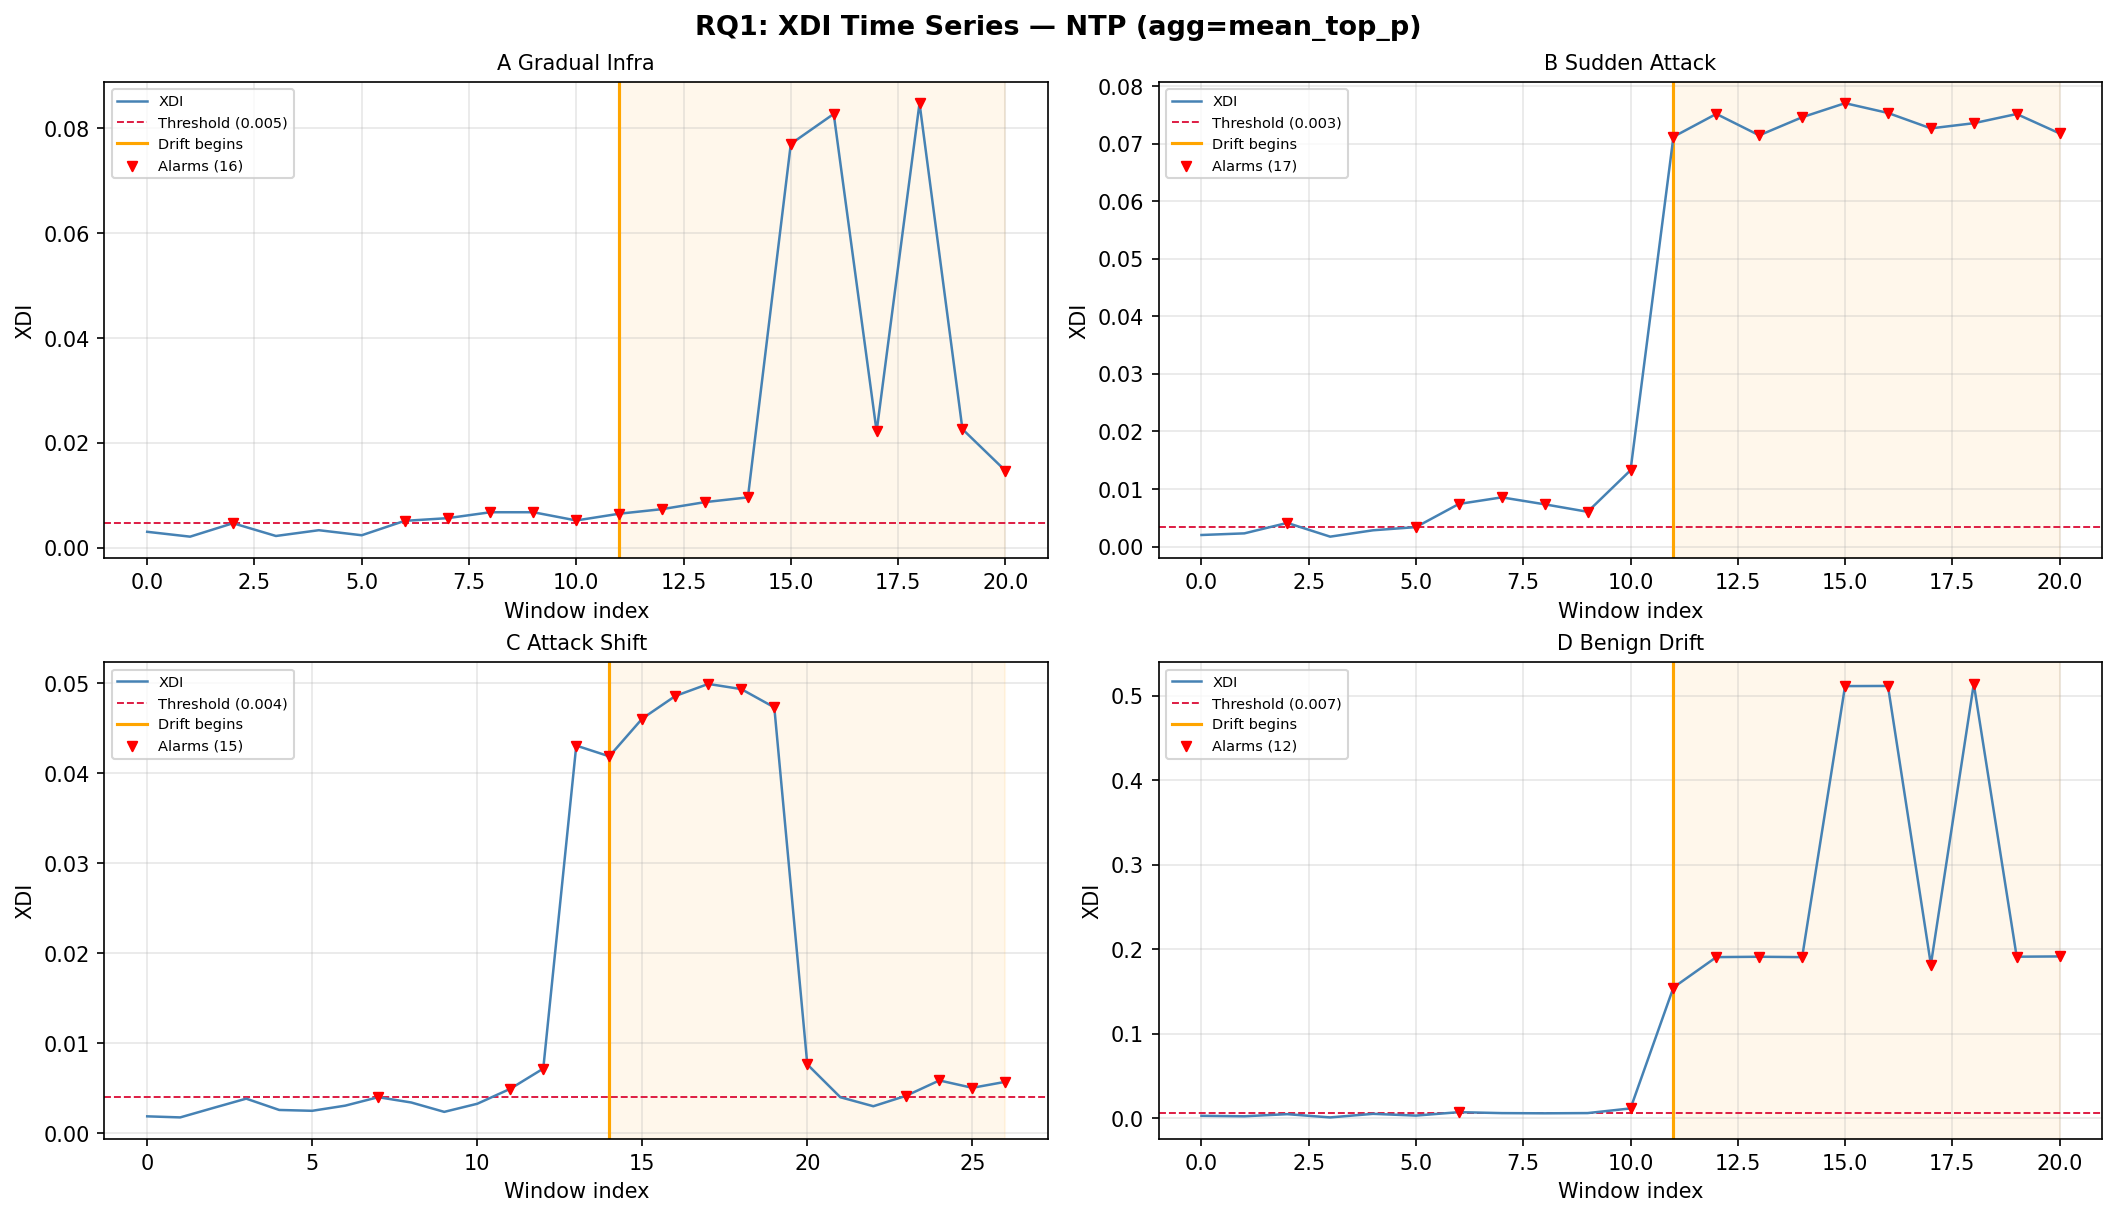

    NTP: saved rq1_xdi_ntp.png/pdf


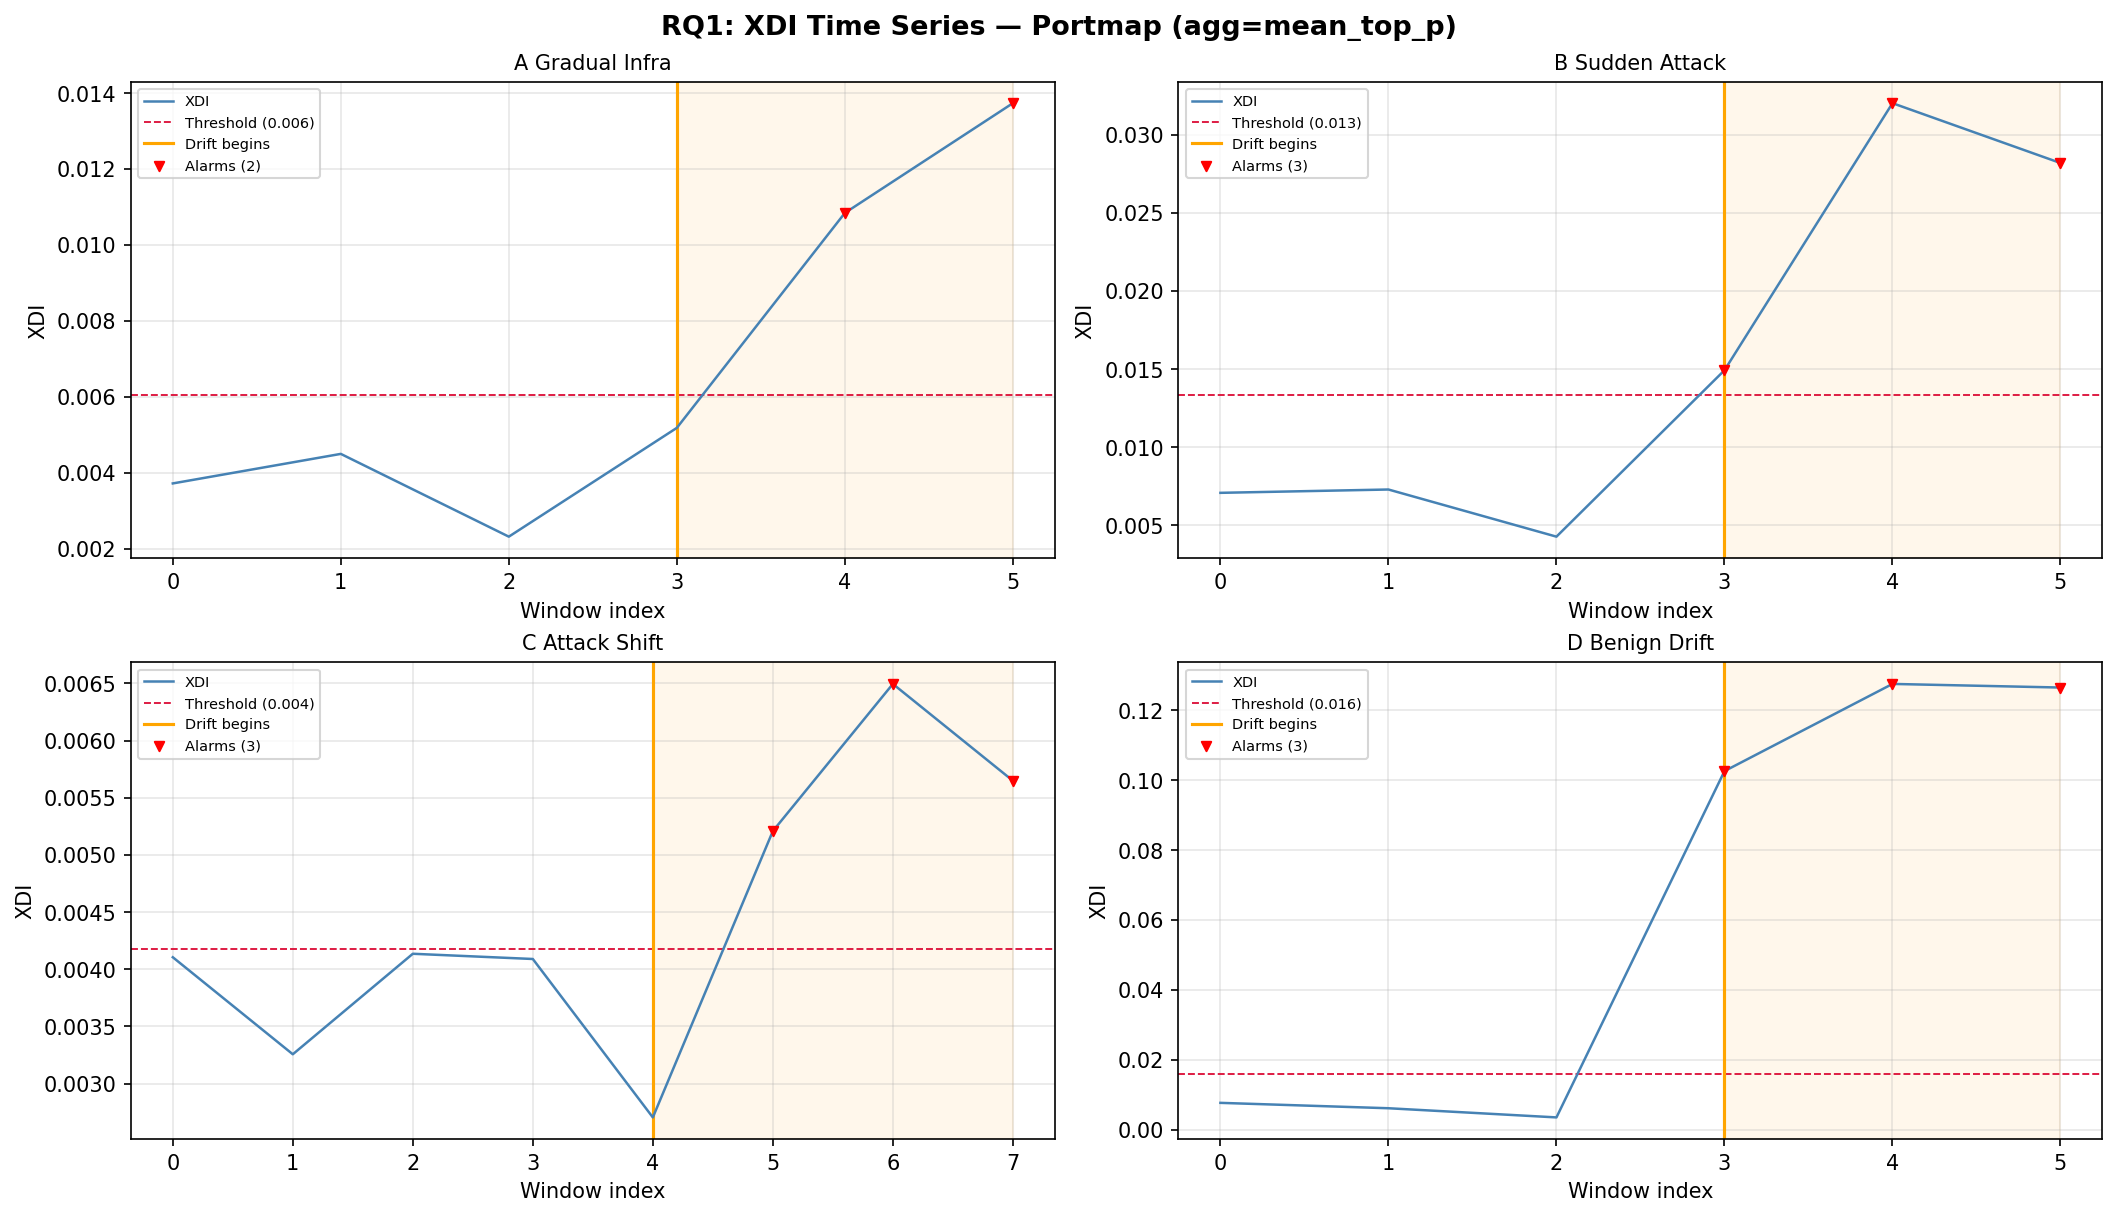

    Portmap: saved rq1_xdi_portmap.png/pdf


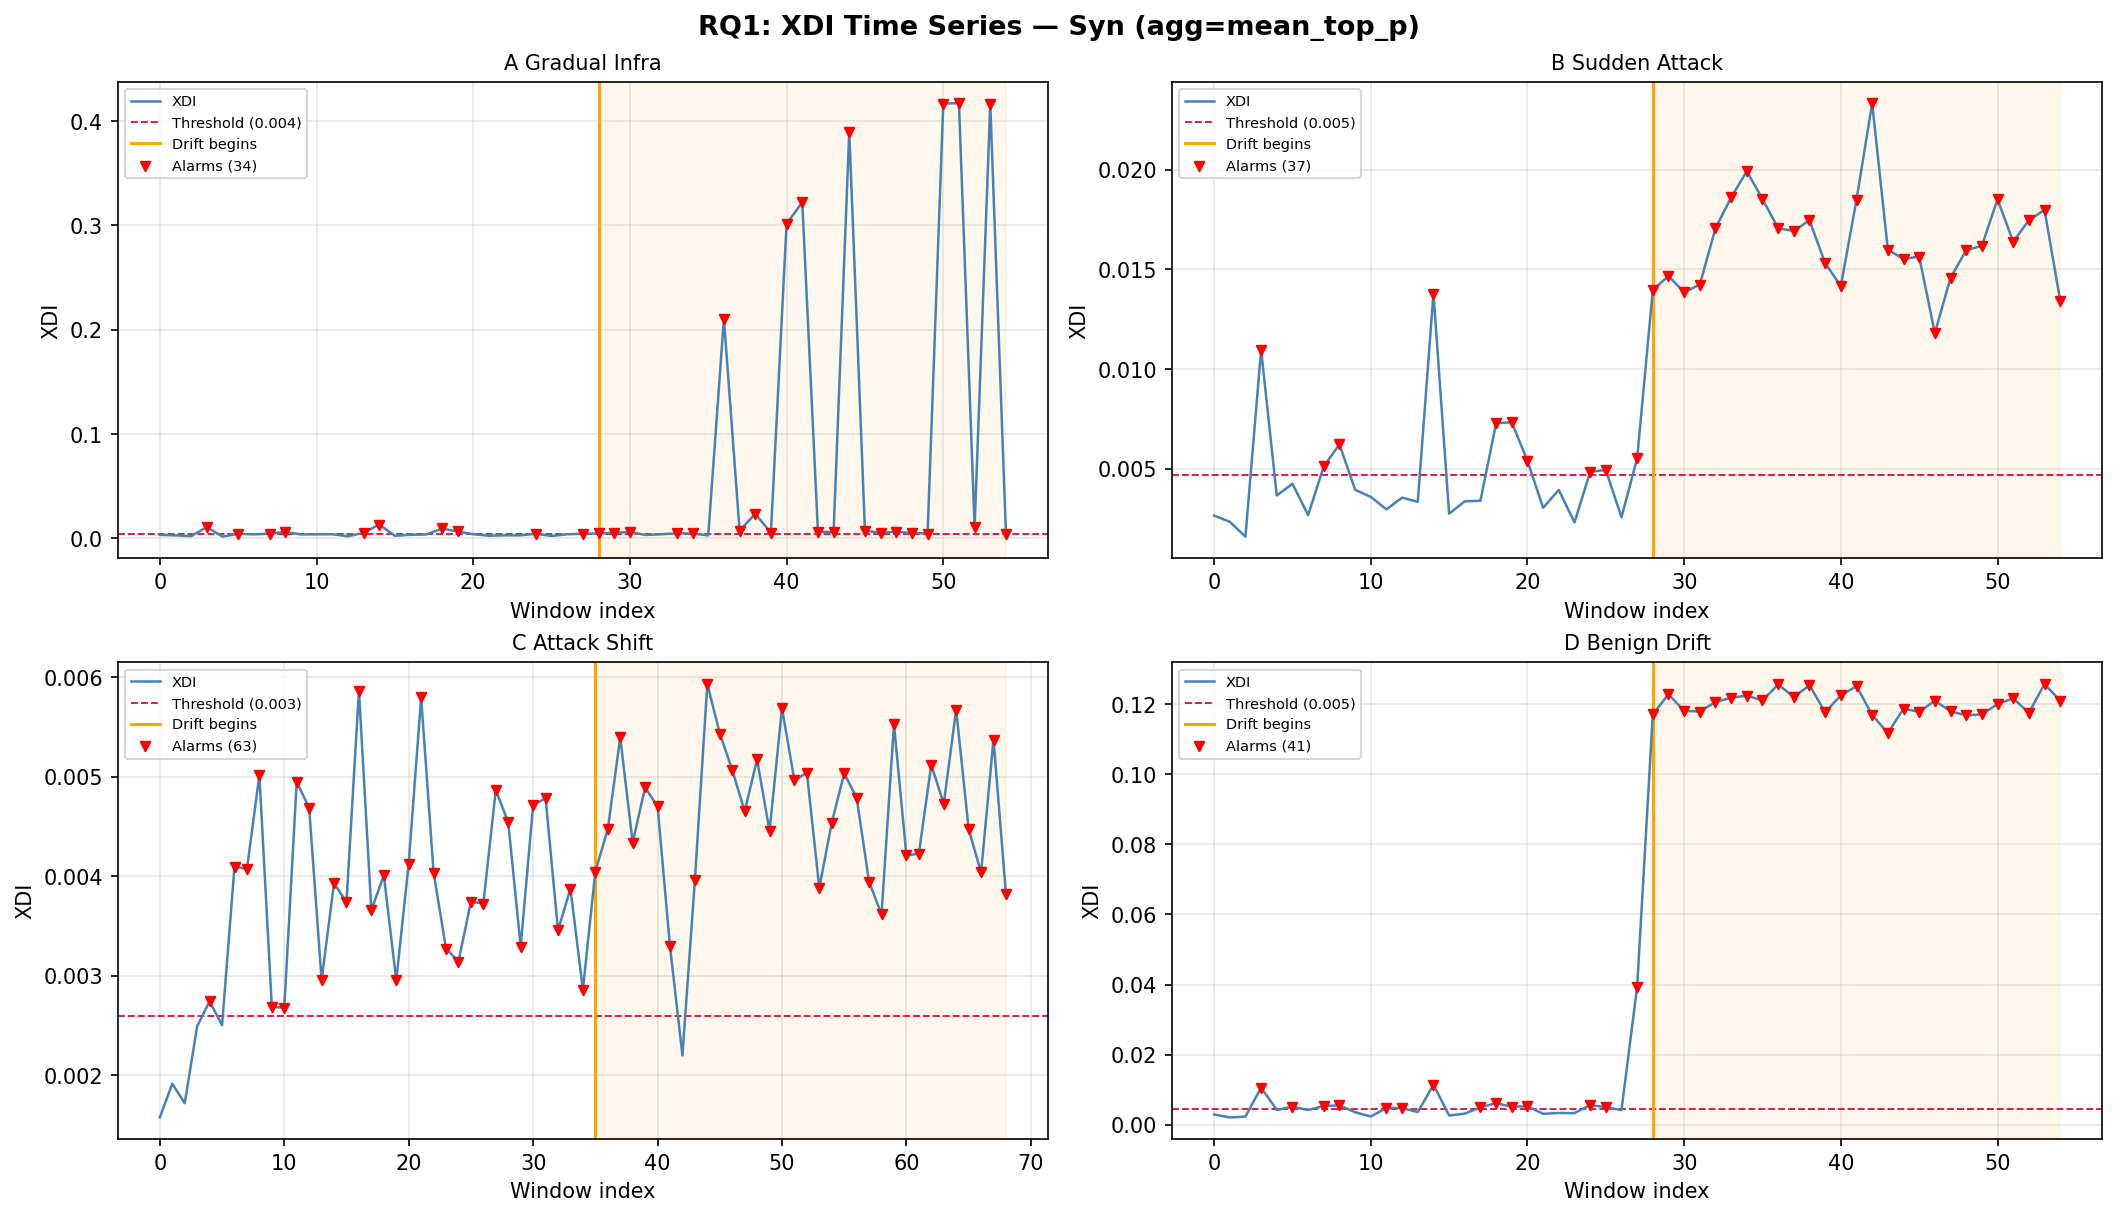

    Syn: saved rq1_xdi_syn.png/pdf


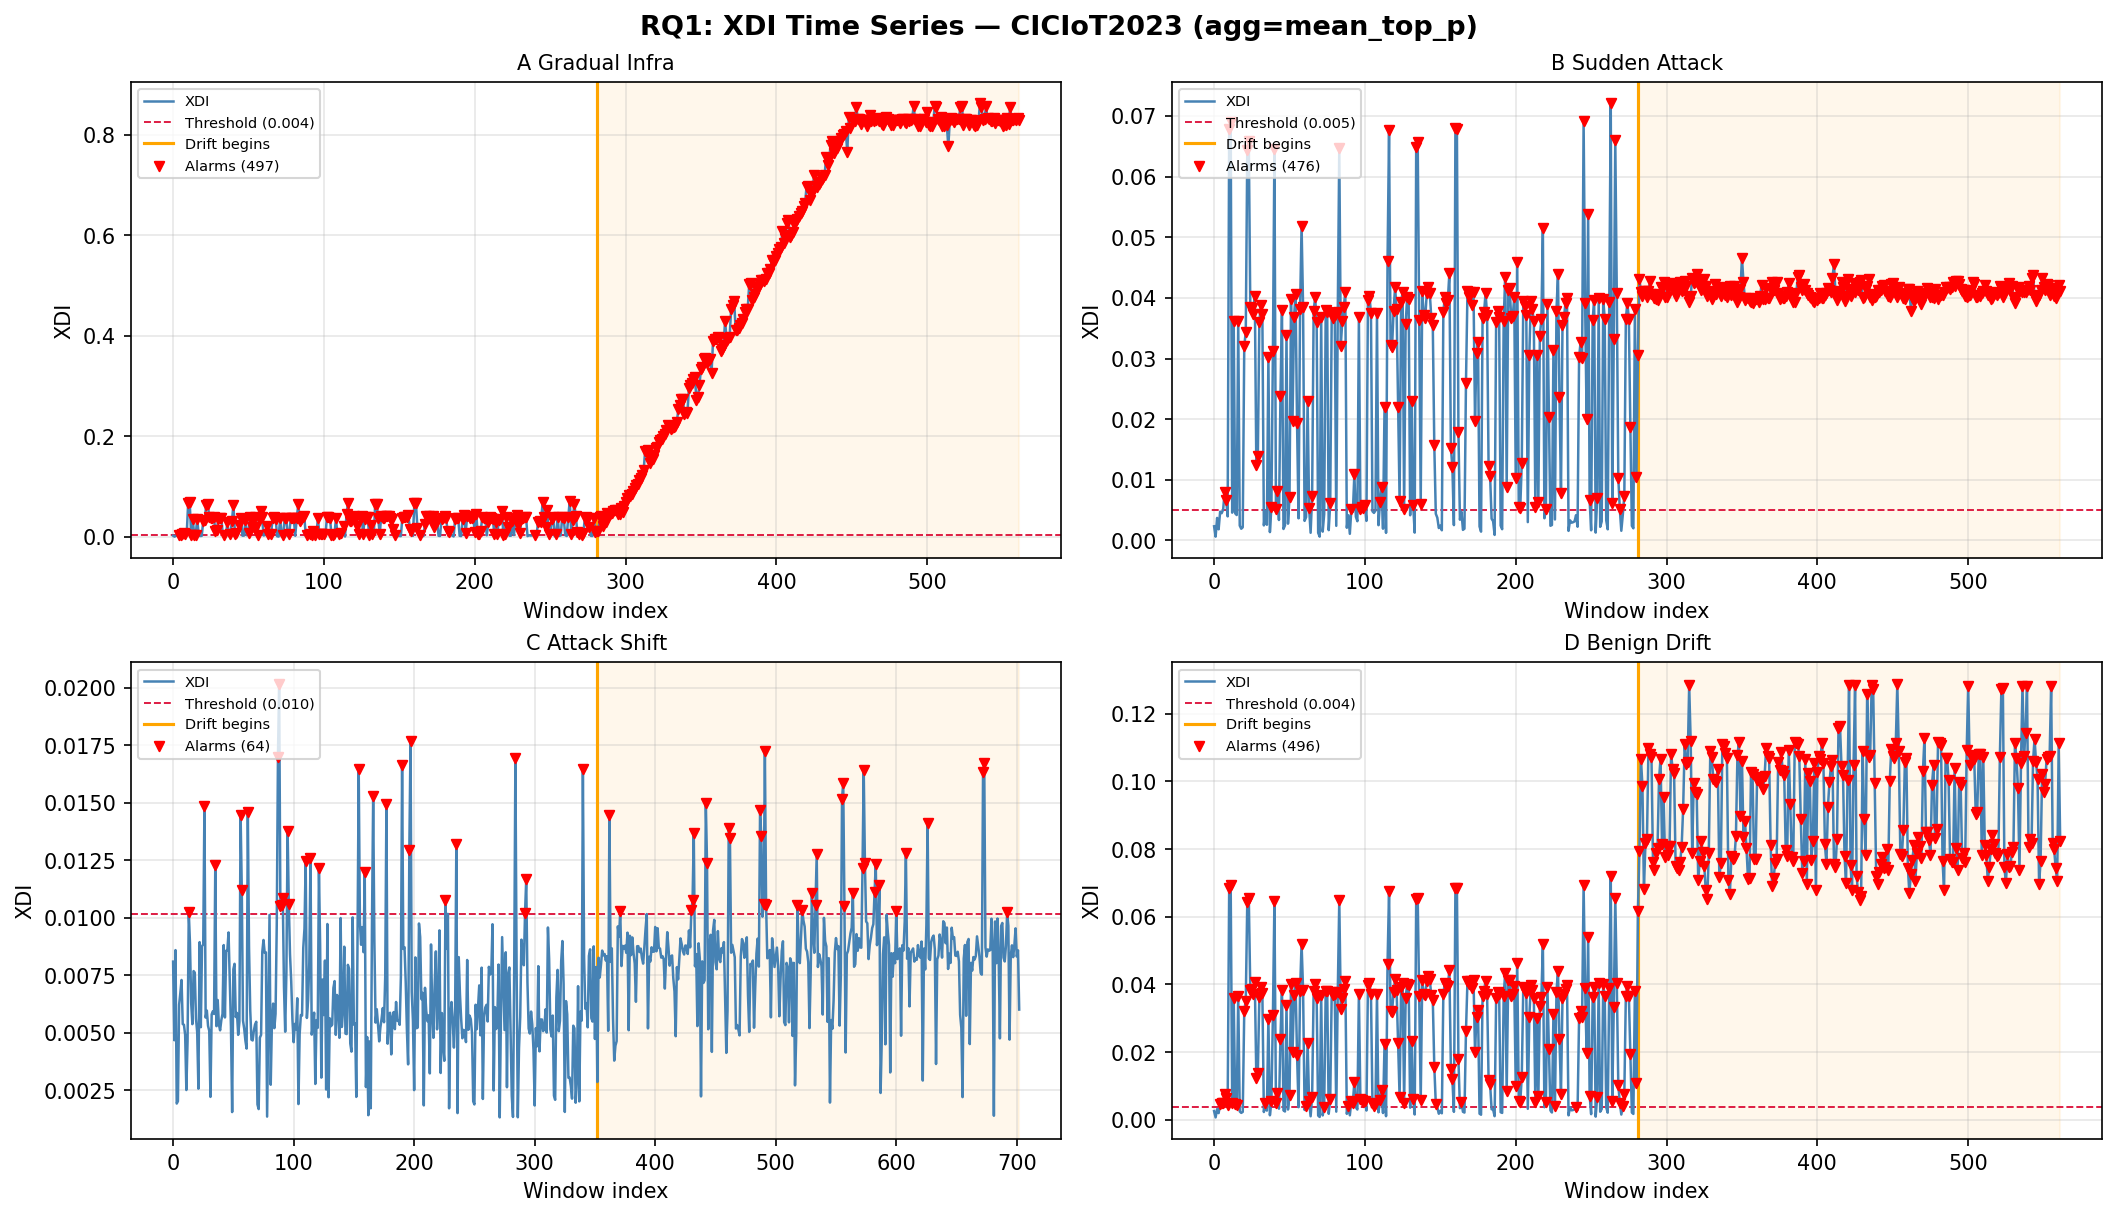

    CICIoT2023: saved rq1_xdi_ciciot2023.png/pdf


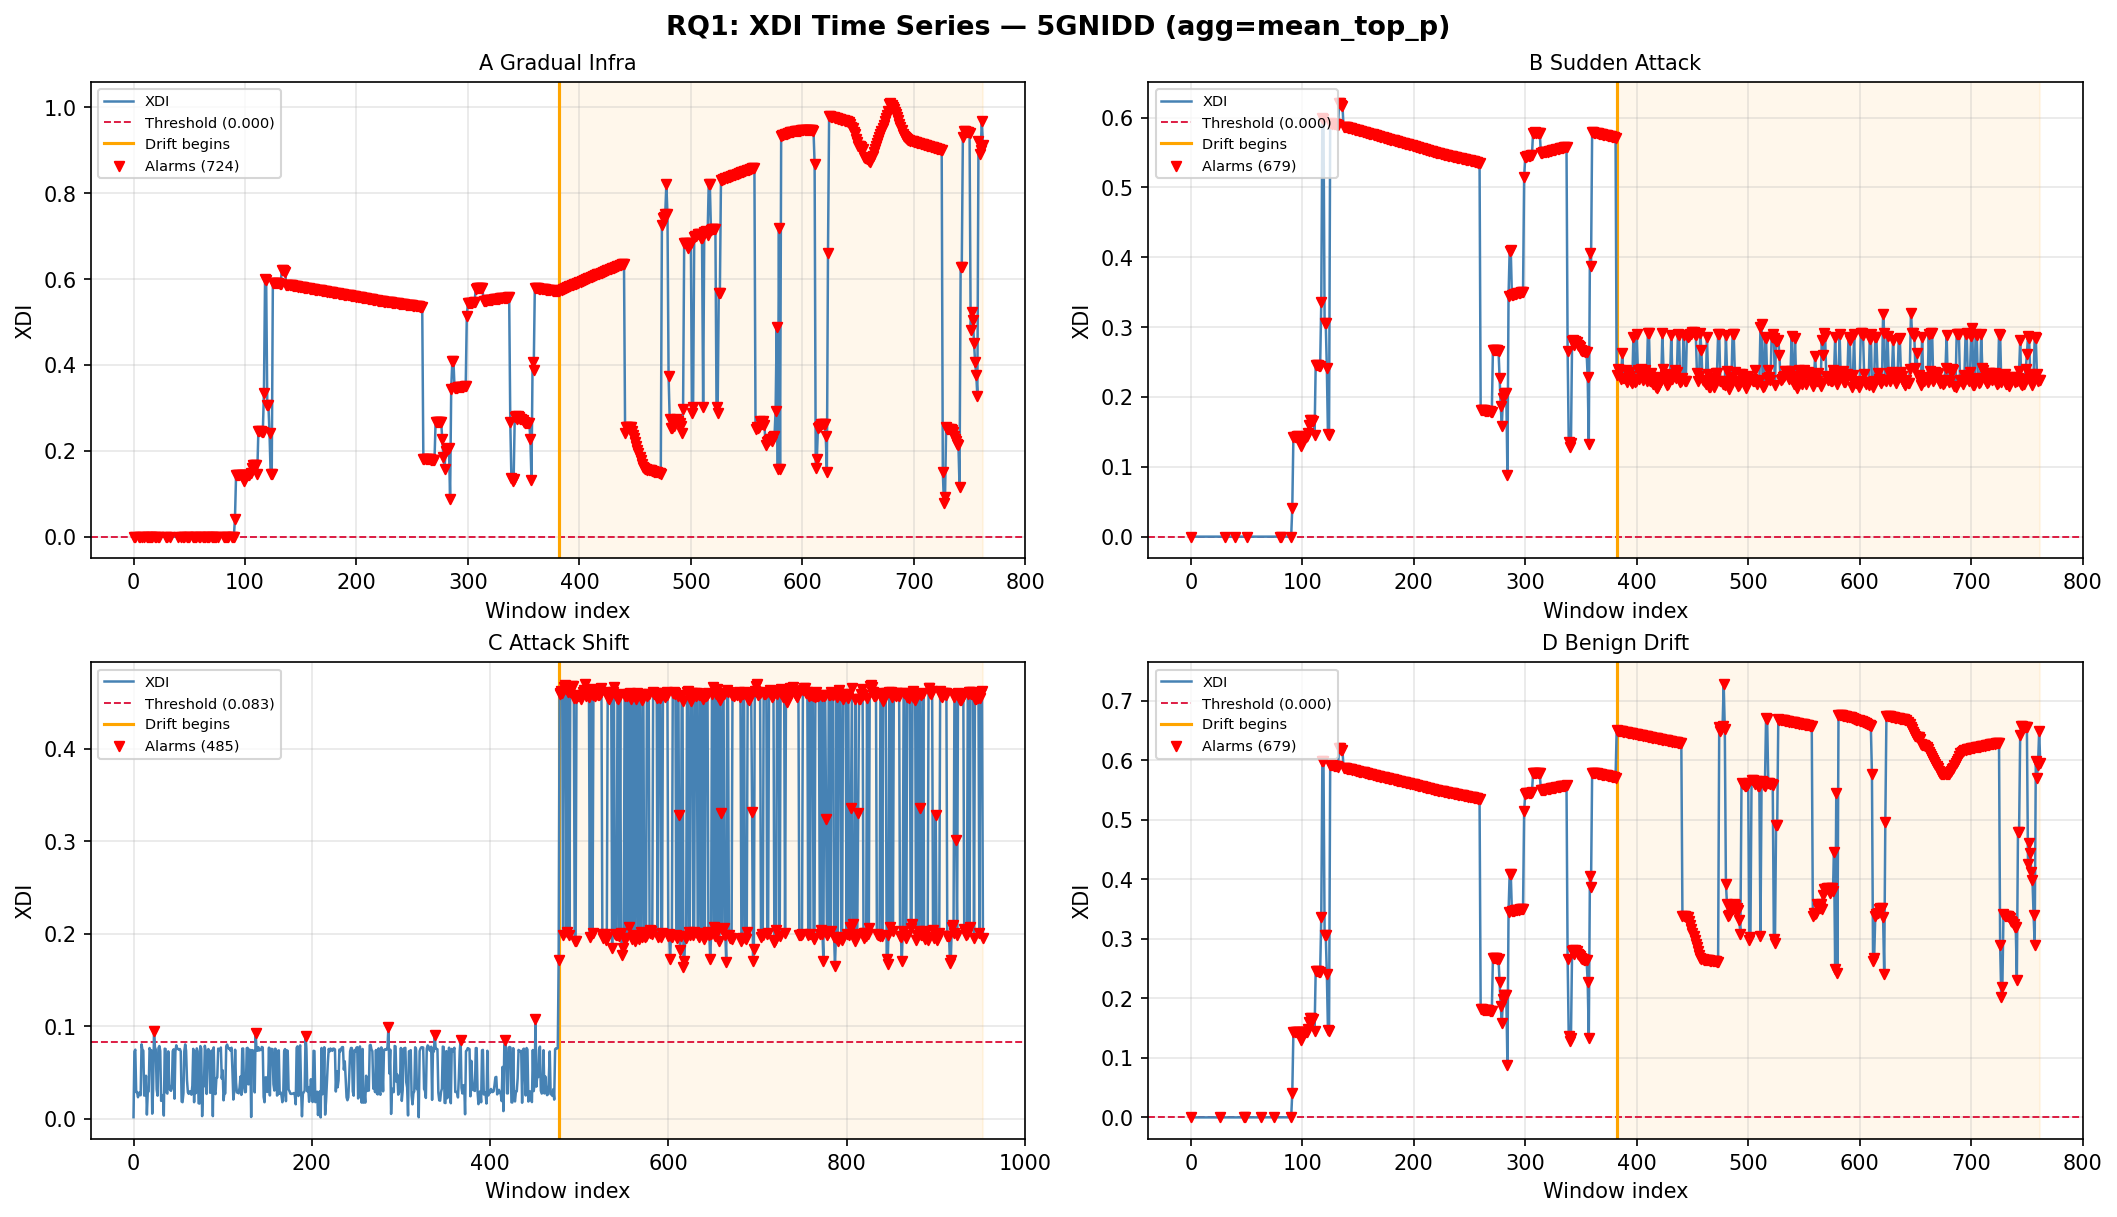

    5GNIDD: saved rq1_xdi_5gnidd.png/pdf


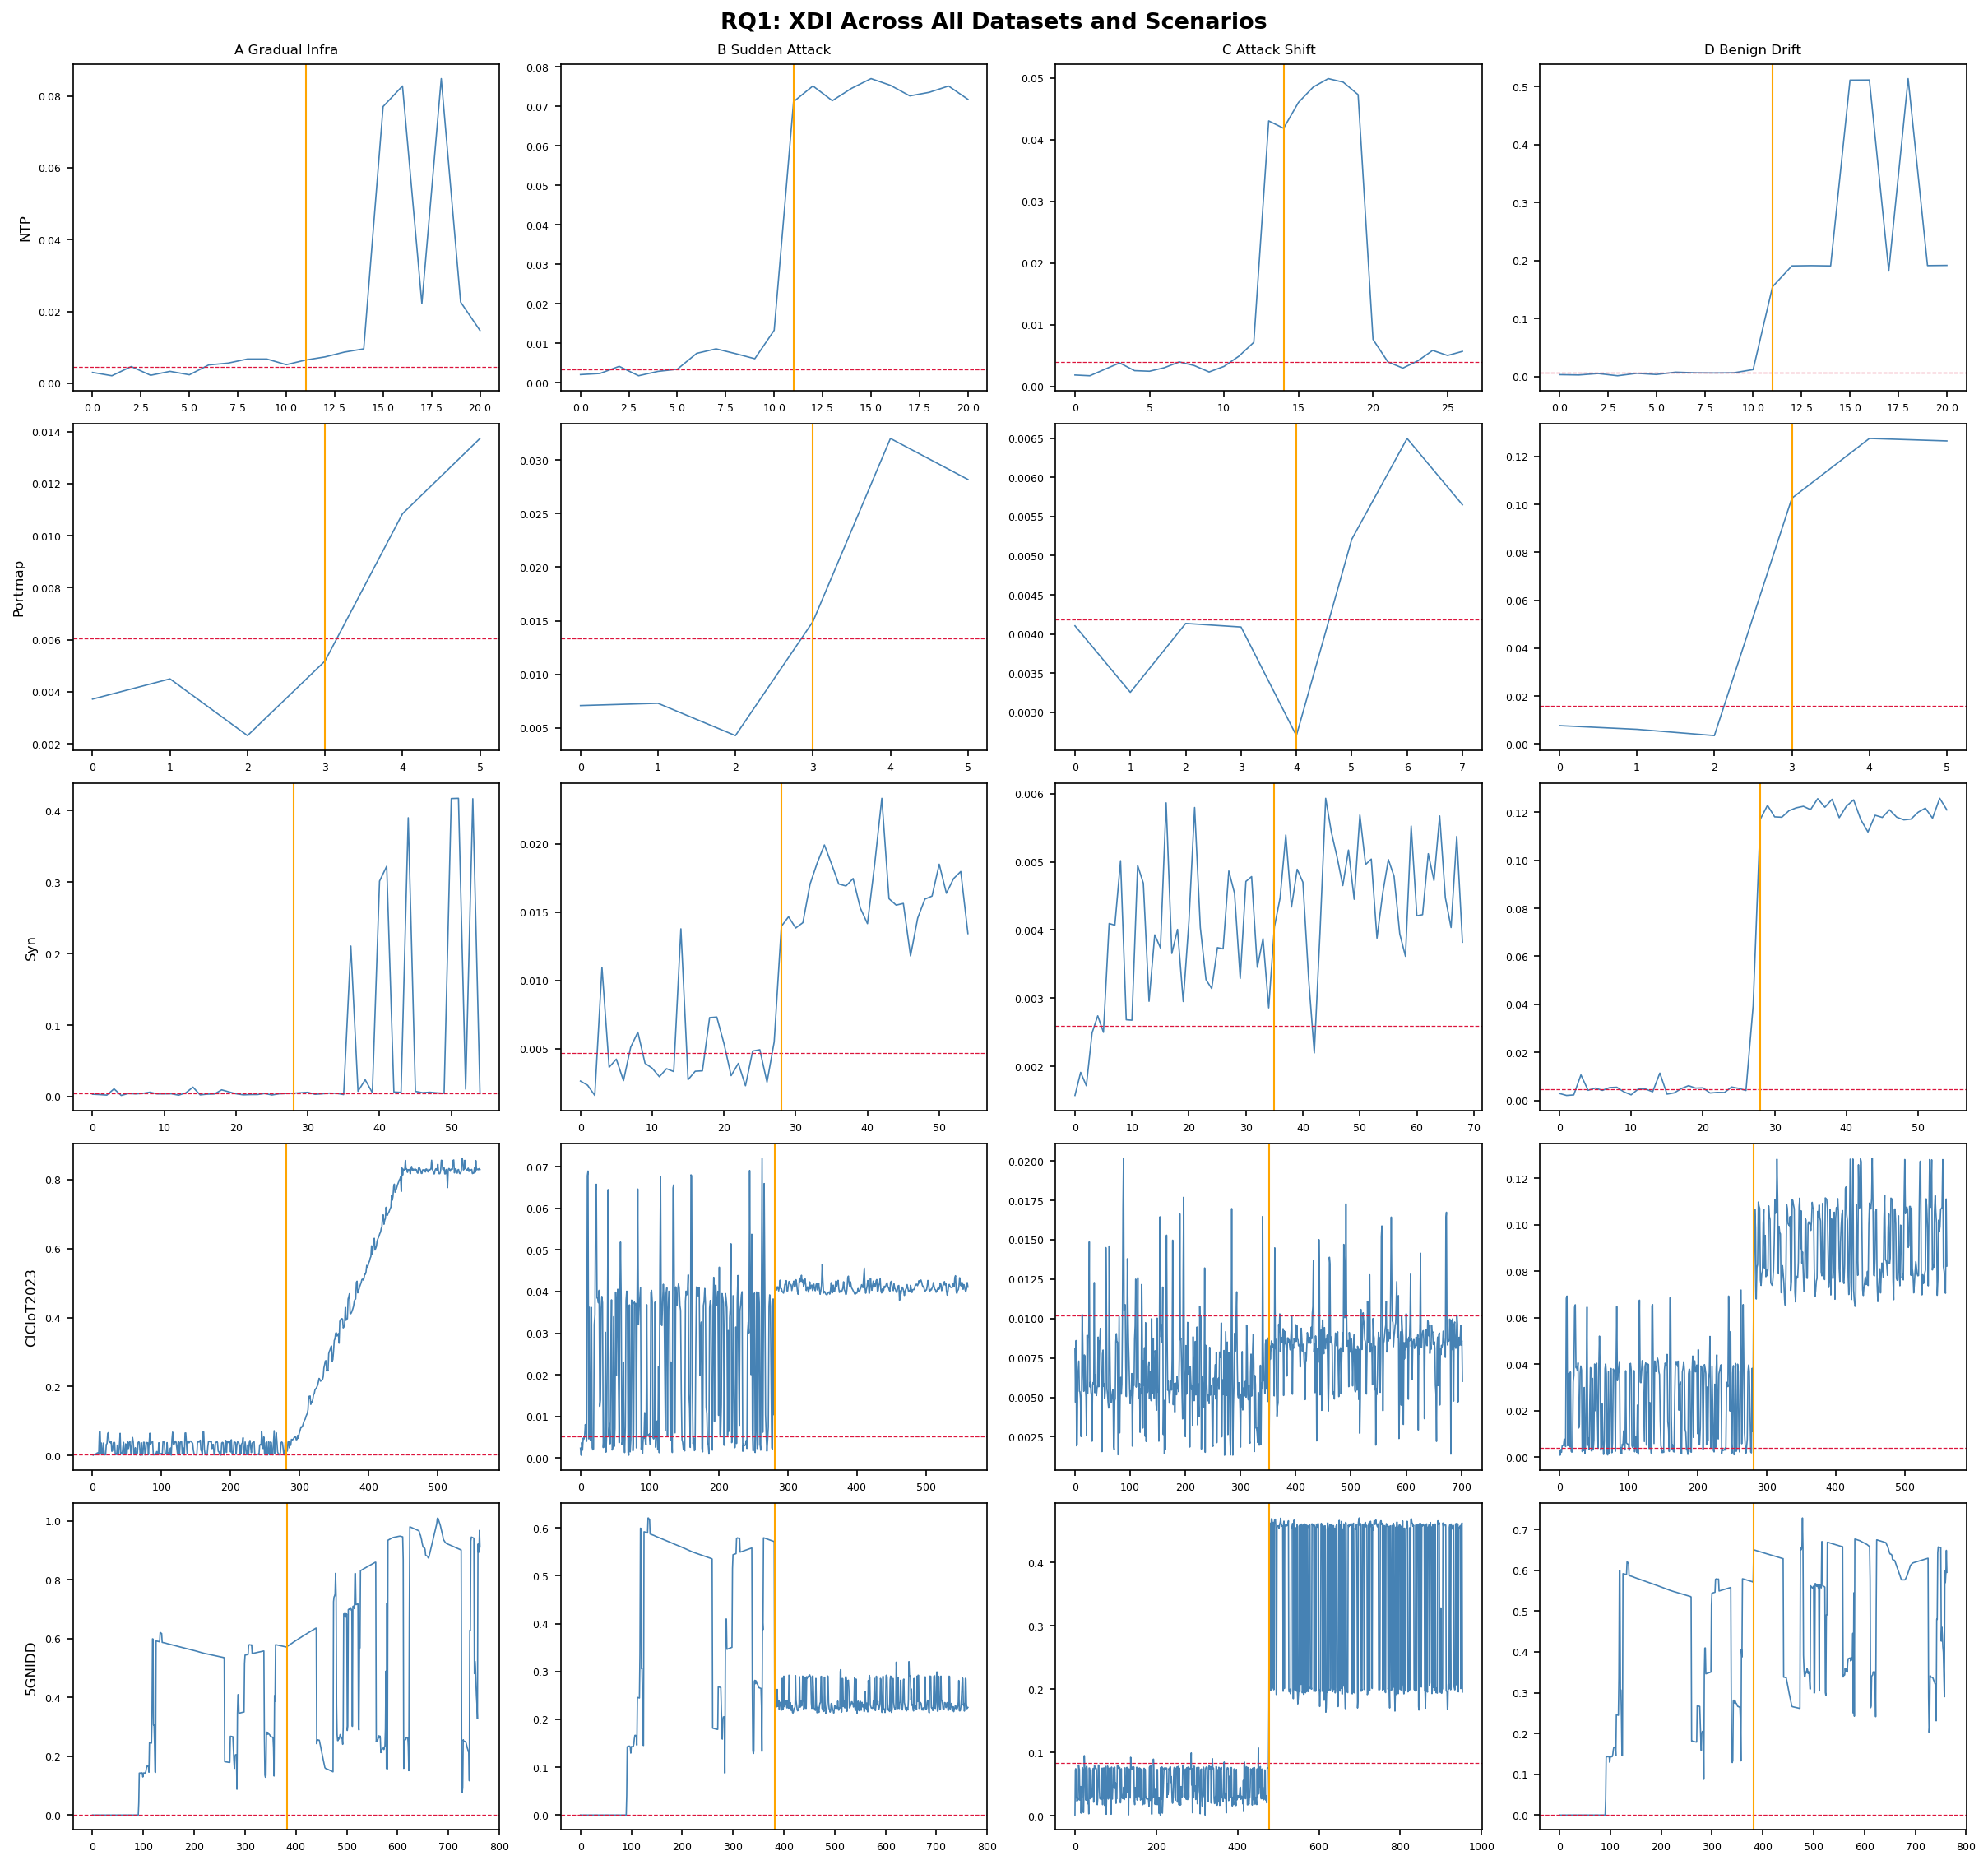


  All-datasets figure saved: E2D2_outputs/figures/rq1_xdi_all_datasets.png (PNG + PDF)

────────────────────────────────────────────────────────────
RQ1 SUMMARY
────────────────────────────────────────────────────────────
  A Gradual Infra               : STRONG detection (F1=0.754, AUC=0.922, delay=0.2, FAR=51.4)
  B Sudden Attack               : STRONG detection (F1=0.809, AUC=0.851, delay=0.0, FAR=49.4)
  C Attack Shift                : MODERATE detection (F1=0.697, AUC=0.826, delay=2.2, FAR=24.8)
  D Benign Drift                : STRONG detection (F1=0.829, AUC=0.961, delay=0.0, FAR=44.5)

  Per-dataset highlights:
    Best dataset:  Portmap (F1=0.914)
    Worst dataset: CICIoT2023 (F1=0.589)

  Overall: E2D2 detected 4/4 scenario types
  Mean F1=0.772, Mean AUC=0.890
  → XDI reliably detects ALL tested drift types in explanation space.
TIMING DIAGNOSTIC: Attribution cost per method
Key structure (6 elements): ('NTP', 'A_gradual_infra', 'VAE', 'raw_gradient', 'all', 'mean_top_p')


In [11]:
# =============================================================================
# CELL 6.1: RQ1 — Detection Performance Across Drift Types
# =============================================================================
# Changes from v2:
# - Generates individual per-dataset XDI time series figures
# - Keeps the combined all-datasets figure as well
# - Keeps scenario-averaged table (for Table II in paper)
# =============================================================================

RQ1_BACKBONE = "VAE"
RQ1_EXPLAINER = "raw_gradient"
RQ1_POPULATION = "all"

# Auto-select best aggregation
_agg_avg = df_e2d2.groupby("aggregation")["f1"].mean()
RQ1_AGGREGATION = _agg_avg.idxmax()

print("=" * 70)
print("CELL 6.1: RQ1 — Can Explanation-Space Drift Detection Reliably")
print("          Identify Diverse Drift Types?")
print("=" * 70)
print(f"  Composition: {RQ1_BACKBONE} × {RQ1_EXPLAINER} × {RQ1_POPULATION} × {RQ1_AGGREGATION}")
print()

# ── Filter to default composition ───────────────────────────────────────────
rq1_filter = (
    (df_e2d2["backbone"] == RQ1_BACKBONE) &
    (df_e2d2["explainer"] == RQ1_EXPLAINER) &
    (df_e2d2["population"] == RQ1_POPULATION) &
    (df_e2d2["aggregation"] == RQ1_AGGREGATION)
)
df_rq1 = df_e2d2[rq1_filter].copy()

metric_cols = ["detection_delay", "precision", "recall", "f1", "far_per_100win",
               "xdi_auc", "explanation_alignment"]

print("  Per-dataset, per-scenario results:")
print("  " + "─" * 90)
pivot = df_rq1.pivot_table(
    index="dataset", columns="scenario",
    values=["f1", "xdi_auc", "detection_delay", "far_per_100win"],
    aggfunc="first"
)
print(pivot.round(3).to_string())

print(f"\n  Scenario-averaged metrics (across all datasets):")
print("  " + "─" * 75)
scen_avg = df_rq1.groupby("scenario")[metric_cols].mean()
print(scen_avg.round(3).to_string())

# ── Per-dataset averaged metrics ────────────────────────────────────────────
print(f"\n  Dataset-averaged metrics (across all scenarios):")
print("  " + "─" * 75)
ds_avg = df_rq1.groupby("dataset")[metric_cols].mean()
print(ds_avg.round(3).to_string())

# ── Individual per-dataset XDI time series figures ──────────────────────────
all_datasets = df_rq1["dataset"].unique()
scenarios_list = list(SCENARIO_REGISTRY.keys())

print(f"\n  Generating individual XDI time series for {len(all_datasets)} datasets...")

for ds_name in all_datasets:
    ds_scenarios = df_rq1[df_rq1["dataset"] == ds_name]["scenario"].unique()
    n_scen = len(ds_scenarios)

    if n_scen == 0:
        print(f"    {ds_name}: skipped (no scenarios)")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    fig.suptitle(f"RQ1: XDI Time Series — {ds_name} (agg={RQ1_AGGREGATION})",
                 fontsize=13, fontweight="bold")

    for idx, ax in enumerate(axes.flat):
        if idx >= len(scenarios_list):
            ax.set_visible(False)
            continue

        scen_name = scenarios_list[idx]
        key = (ds_name, scen_name, RQ1_BACKBONE, RQ1_EXPLAINER,
               RQ1_POPULATION, RQ1_AGGREGATION)

        if key not in E2D2_RESULTS:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12, color="gray")
            ax.set_xticks([]); ax.set_yticks([])
            scen_short = scen_name.replace("_", " ").title()
            ax.set_title(scen_short, fontsize=10)
            continue

        res = E2D2_RESULTS[key]
        xdi = res["xdi"]
        alarms = res["alarm_indices"]
        threshold = res["threshold"]
        meta = res["scenario_metadata"]
        window_centers = res["window_centers"]
        drift_onset = meta.get("drift_onset_idx", None)

        T = len(xdi)
        t_axis = np.arange(T)

        ax.plot(t_axis, xdi, color="steelblue", linewidth=1.2, label="XDI", zorder=3)
        ax.axhline(y=threshold, color="crimson", linestyle="--", linewidth=0.9,
                    label=f"Threshold ({threshold:.3f})", zorder=2)

        if drift_onset is not None:
            onset_win = np.searchsorted(window_centers, drift_onset)
            ax.axvline(x=onset_win, color="orange", linestyle="-", linewidth=1.5,
                       label="Drift begins", zorder=2)
            ax.axvspan(onset_win, T - 1, alpha=0.08, color="orange")

        if len(alarms) > 0:
            ax.scatter(alarms, xdi[alarms], color="red", s=20, zorder=5,
                       label=f"Alarms ({len(alarms)})", marker="v")

        scen_short = scen_name.replace("_", " ").title()
        ax.set_title(scen_short, fontsize=10)
        ax.set_xlabel("Window index")
        ax.set_ylabel("XDI")
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3)

    # Save individual dataset figure
    fig_name = f"rq1_xdi_{ds_name.lower().replace(' ', '_')}"
    fig.savefig(FIGURE_DIR / f"{fig_name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{fig_name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"    {ds_name}: saved {fig_name}.png/pdf")

# ── Combined all-datasets figure (kept for reference) ───────────────────────
n_ds = len(all_datasets)

if n_ds > 1:
    fig2, axes2 = plt.subplots(n_ds, len(scenarios_list), figsize=(16, 3 * n_ds),
                                constrained_layout=True)
    fig2.suptitle("RQ1: XDI Across All Datasets and Scenarios", fontsize=13,
                  fontweight="bold")
    if n_ds == 1:
        axes2 = axes2[np.newaxis, :]

    for row, ds_name in enumerate(all_datasets):
        for col, scen_name in enumerate(scenarios_list):
            ax = axes2[row, col]
            key = (ds_name, scen_name, RQ1_BACKBONE, RQ1_EXPLAINER,
                   RQ1_POPULATION, RQ1_AGGREGATION)

            if key not in E2D2_RESULTS:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                        transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                if row == 0: ax.set_title(scen_name.replace("_", " ").title(), fontsize=8)
                if col == 0: ax.set_ylabel(ds_name, fontsize=8)
                continue

            res = E2D2_RESULTS[key]
            xdi = res["xdi"]
            threshold = res["threshold"]
            meta = res["scenario_metadata"]
            window_centers = res["window_centers"]
            drift_onset = meta.get("drift_onset_idx", None)

            ax.plot(xdi, color="steelblue", linewidth=0.8)
            ax.axhline(y=threshold, color="crimson", linestyle="--", linewidth=0.6)
            if drift_onset is not None:
                onset_win = np.searchsorted(window_centers, drift_onset)
                ax.axvline(x=onset_win, color="orange", linewidth=1.0)
            if row == 0: ax.set_title(scen_name.replace("_", " ").title(), fontsize=8)
            if col == 0: ax.set_ylabel(ds_name, fontsize=8)
            ax.tick_params(labelsize=6)

    fig2_path = FIGURE_DIR / "rq1_xdi_all_datasets.png"
    fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
    fig2.savefig(FIGURE_DIR / "rq1_xdi_all_datasets.pdf", bbox_inches="tight")
    plt.show()
    print(f"\n  All-datasets figure saved: {fig2_path} (PNG + PDF)")

# ── Dynamic RQ1 summary ────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print("RQ1 SUMMARY")
print(f"{'─' * 60}")

for scen in scen_avg.index:
    row = scen_avg.loc[scen]
    f1_val, auc_val = row["f1"], row["xdi_auc"]
    delay_val, far_val = row["detection_delay"], row["far_per_100win"]

    if f1_val > 0.7 and auc_val > 0.8:
        verdict = "STRONG detection"
    elif f1_val > 0.4 and auc_val > 0.6:
        verdict = "MODERATE detection"
    elif f1_val > 0 or auc_val > 0.5:
        verdict = "WEAK detection"
    else:
        verdict = "NOT detected"

    print(f"  {scen.replace('_', ' ').title():30s}: {verdict} "
          f"(F1={f1_val:.3f}, AUC={auc_val:.3f}, delay={delay_val:.1f}, FAR={far_val:.1f})")

print(f"\n  Per-dataset highlights:")
best_ds = ds_avg["f1"].idxmax()
worst_ds = ds_avg["f1"].idxmin()
print(f"    Best dataset:  {best_ds} (F1={ds_avg.loc[best_ds, 'f1']:.3f})")
print(f"    Worst dataset: {worst_ds} (F1={ds_avg.loc[worst_ds, 'f1']:.3f})")

overall_f1 = scen_avg["f1"].mean()
overall_auc = scen_avg["xdi_auc"].mean()
n_detected = (scen_avg["f1"] > 0.3).sum()
n_scenarios = len(scen_avg)

print(f"\n  Overall: E2D2 detected {n_detected}/{n_scenarios} scenario types")
print(f"  Mean F1={overall_f1:.3f}, Mean AUC={overall_auc:.3f}")

if n_detected == n_scenarios and overall_auc > 0.7:
    print("  → XDI reliably detects ALL tested drift types in explanation space.")
elif n_detected >= n_scenarios - 1:
    weak = scen_avg["f1"].idxmin()
    print(f"  → XDI detects most drift types; weakest on {weak.replace('_',' ')}.")
else:
    print("  → XDI detection is scenario-dependent; further tuning needed.")

# ── Diagnostic: Extract timing data for paper ────────────────────────
import numpy as np
from collections import defaultdict

print("=" * 70)
print("TIMING DIAGNOSTIC: Attribution cost per method")
print("=" * 70)

sample_key = list(E2D2_RESULTS.keys())[0]
print(f"Key structure ({len(sample_key)} elements): {sample_key}\n")

# Key = (ds, scen, bb, explainer, population, aggregation)
explainer_times = defaultdict(list)
for key, val in E2D2_RESULTS.items():
    ds, scen, bb, exp, pop, agg = key
    if pop == "all" and agg == "mean_top_p":  # count once per attribution
        explainer_times[exp].append(val.get("attr_time_s", 0))

print("E2D2 attribution time (averaged across datasets/scenarios/backbones):")
for exp, times in sorted(explainer_times.items()):
    times = [t for t in times if t > 0]
    if times:
        avg_time = np.mean(times)
        print(f"  {exp:25s}: {avg_time:.3f}s total | {avg_time*1000:.1f}ms")

# If still empty, check what keys are available in the value dict
if not any(t > 0 for ts in explainer_times.values() for t in ts):
    print("\n  WARNING: attr_time_s is 0 or missing. Available value keys:")
    sample_val = list(E2D2_RESULTS.values())[0]
    print(f"  {list(sample_val.keys())}")
    # Try alternative timing keys
    for alt_key in ["runtime_s", "total_time_s", "time_s", "elapsed_s"]:
        if alt_key in sample_val:
            print(f"  Found '{alt_key}': {sample_val[alt_key]}")

# Baseline timing
print("\nBaseline runtime (averaged across datasets/scenarios/backbones):")
baseline_times = defaultdict(list)
for key, val in BASELINE_RESULTS.items():
    bl = key[-1]
    baseline_times[bl].append(val.get("runtime_s", 0))

for bl, times in sorted(baseline_times.items()):
    times = [t for t in times if t > 0]
    if times:
        avg_time = np.mean(times)
        print(f"  {bl:25s}: {avg_time:.3f}s total | {avg_time*1000:.1f}ms")

print("\n" + "=" * 70)

print("=" * 70)
print("Cell 6.1 complete.")

CELL 6.2: RQ2 — Which Combination of Backbone, Explainer,
          Population, and Aggregation Provides the Best E2D2?

  Top-15 compositions ranked by F1 (then AUC):
  ───────────────────────────────────────────────────────────────────────────────────────────────
                                                  f1  xdi_auc  detection_delay  far_per_100win  precision  recall
composition                                                                                                      
VAE × integrated_gradients × all × max         0.790    0.858             0.05          48.474      0.695   0.957
VAE × integrated_gradients × all × mean_top_p  0.784    0.874             0.15          47.455      0.708   0.946
AE × integrated_gradients × all × mean_top_p   0.779    0.862             0.15          32.399      0.718   0.882
VAE × raw_gradient × ben × max                 0.778    0.802             0.35          35.978      0.729   0.875
VAE × raw_gradient × ben × mean_top_p          0.7

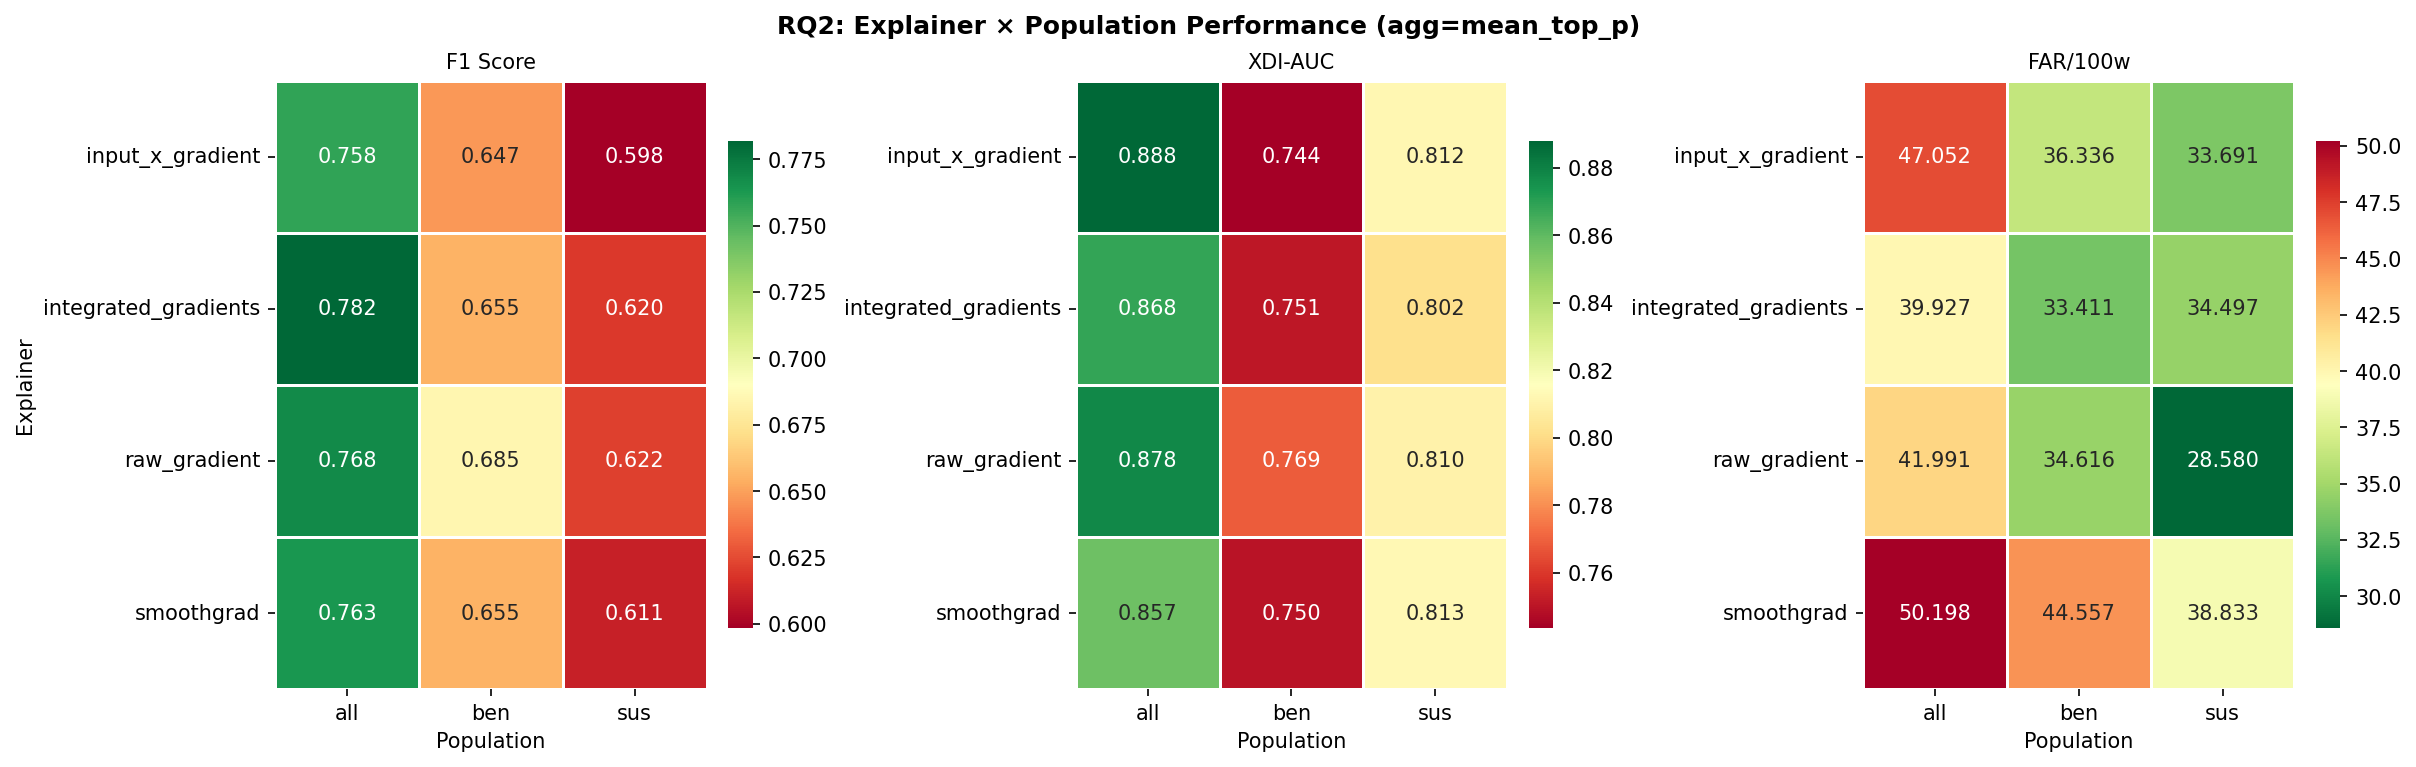

  Heatmap saved: E2D2_outputs/figures/rq2_explainer_population_heatmap.png


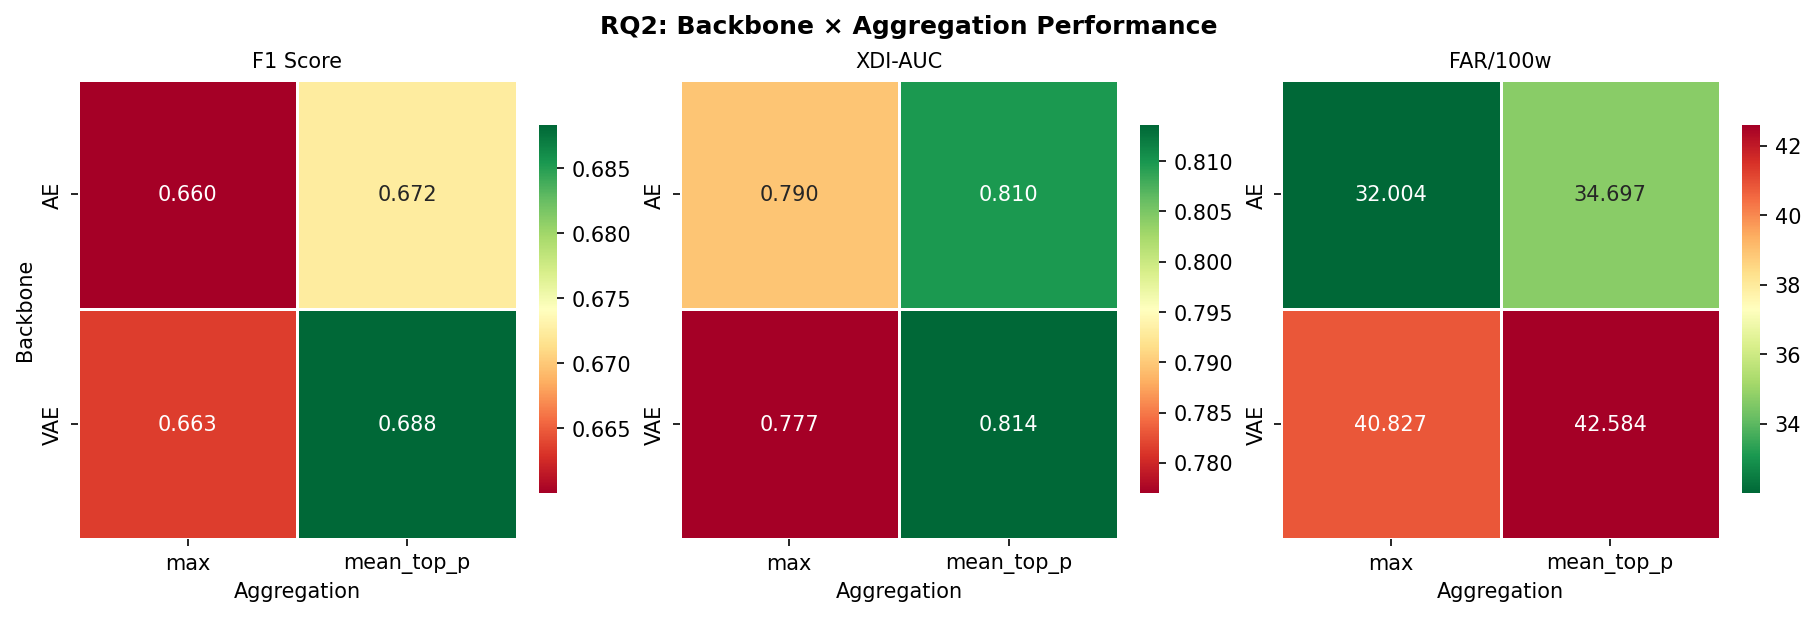

  Heatmap saved: E2D2_outputs/figures/rq2_backbone_aggregation_heatmap.png


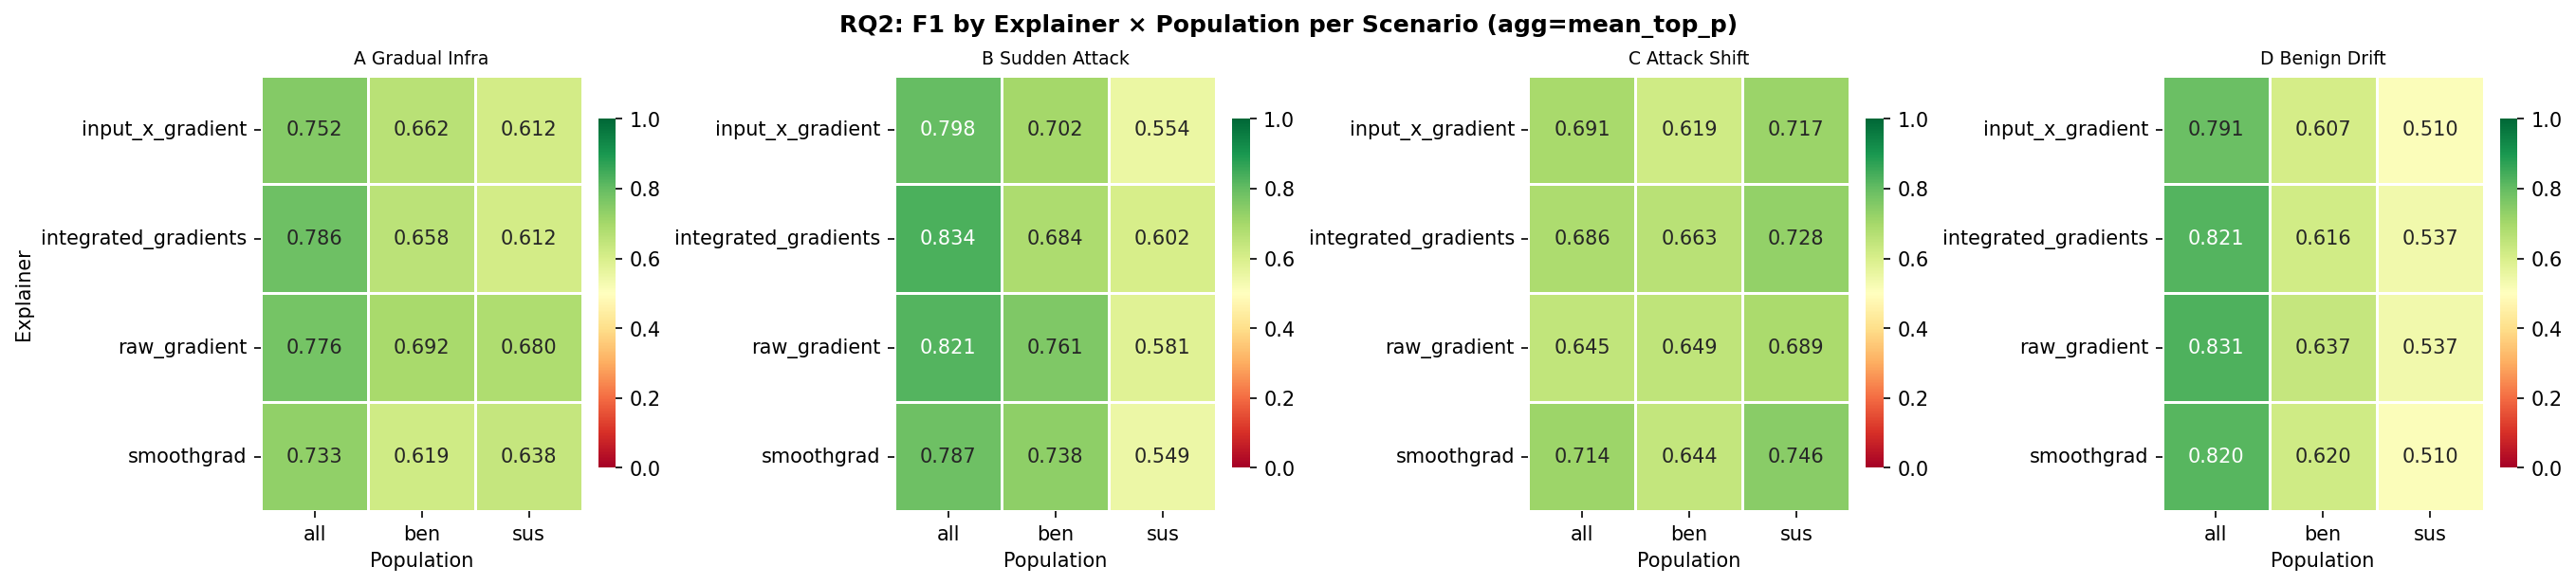

  Per-scenario heatmap saved: E2D2_outputs/figures/rq2_f1_per_scenario.png

────────────────────────────────────────────────────────────
RQ2 SUMMARY
────────────────────────────────────────────────────────────
  Best overall composition: VAE × integrated_gradients × all × max
    Backbone:    VAE
    Explainer:   integrated_gradients
    Population:  all
    Aggregation: max
    F1=0.790, AUC=0.858

  Factor importance ranking (by F1 range):
    1. population   ΔF1=0.149, ΔAUC=0.121
    2. aggregation  ΔF1=0.019, ΔAUC=0.028
    3. explainer    ΔF1=0.012, ΔAUC=0.011
    4. backbone     ΔF1=0.010, ΔAUC=0.004
Cell 6.2 complete.


In [12]:
# =============================================================================
# CELL 6.2: RQ2 — Compositional Analysis
# =============================================================================
# - Composition now includes aggregation: backbone × explainer × population × aggregation
# - Factor analysis includes aggregation as a 4th factor
# - Otherwise same structure as v1
# =============================================================================

print("=" * 70)
print("CELL 6.2: RQ2 — Which Combination of Backbone, Explainer,")
print("          Population, and Aggregation Provides the Best E2D2?")
print("=" * 70)

metric_cols_rq2 = ["f1", "xdi_auc", "detection_delay", "far_per_100win",
                    "precision", "recall", "explanation_alignment"]

# ── Full composition label ──────────────────────────────────────────────────
df_e2d2["composition"] = (df_e2d2["backbone"] + " × " +
                           df_e2d2["explainer"] + " × " +
                           df_e2d2["population"] + " × " +
                           df_e2d2["aggregation"])

comp_avg = df_e2d2.groupby("composition")[metric_cols_rq2].mean()
comp_avg_sorted = comp_avg.sort_values(["f1", "xdi_auc"], ascending=[False, False])

print("\n  Top-15 compositions ranked by F1 (then AUC):")
print("  " + "─" * 95)
print(comp_avg_sorted.head(15)[["f1", "xdi_auc", "detection_delay", "far_per_100win",
                                 "precision", "recall"]].round(3).to_string())

best_comp = comp_avg_sorted.index[0]
best_row = comp_avg_sorted.iloc[0]
print(f"\n  ★ Best overall: {best_comp}")
print(f"    F1={best_row['f1']:.3f}, AUC={best_row['xdi_auc']:.3f}, "
      f"Delay={best_row['detection_delay']:.1f}, FAR={best_row['far_per_100win']:.1f}")

# ── Per-scenario best compositions ──────────────────────────────────────────
print(f"\n  Best composition per scenario:")
print("  " + "─" * 85)
for scen in df_e2d2["scenario"].unique():
    df_scen = df_e2d2[df_e2d2["scenario"] == scen]
    scen_comp = df_scen.groupby("composition")[["f1", "xdi_auc"]].mean()
    best_scen = scen_comp.sort_values("f1", ascending=False).index[0]
    best_vals = scen_comp.loc[best_scen]
    print(f"    {scen.replace('_', ' ').title():30s}: {best_scen} "
          f"(F1={best_vals['f1']:.3f})")

# ── Factor analysis ─────────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print("  Factor Analysis: Which Axis Matters Most?")
print(f"{'─' * 60}")

factor_importance = {}

for factor in ["backbone", "explainer", "population", "aggregation"]:
    group = df_e2d2.groupby(factor)[["f1", "xdi_auc"]].mean()
    f1_range = group["f1"].max() - group["f1"].min()
    auc_range = group["xdi_auc"].max() - group["xdi_auc"].min()
    factor_importance[factor] = {"f1_range": f1_range, "auc_range": auc_range}

    print(f"\n  By {factor}:")
    print(group[["f1", "xdi_auc"]].round(3).to_string())
    print(f"    F1 range: {f1_range:.3f}, AUC range: {auc_range:.3f}")

dominant = max(factor_importance, key=lambda k: factor_importance[k]["f1_range"])
print(f"\n  Dominant factor (largest F1 range): {dominant} "
      f"(ΔF1={factor_importance[dominant]['f1_range']:.3f})")

# ── Heatmap: Explainer × Population (best aggregation) ─────────────────────
best_agg = df_e2d2.groupby("aggregation")["f1"].mean().idxmax()
df_best_agg = df_e2d2[df_e2d2["aggregation"] == best_agg].copy()

def plot_explainer_population_heatmap(df_input, title_suffix, file_stem):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    fig.suptitle(
        f"RQ2: Explainer × Population Performance (agg={best_agg}){title_suffix}",
        fontsize=12,
        fontweight="bold"
    )

    for idx, metric in enumerate(["f1", "xdi_auc", "far_per_100win"]):
        ax = axes[idx]
        pivot = df_input.pivot_table(
            index="explainer",
            columns="population",
            values=metric,
            aggfunc="mean"
        )

        pop_order = [p for p in ["all", "ben", "sus"] if p in pivot.columns]
        pivot = pivot[pop_order]

        cmap = "RdYlGn" if metric != "far_per_100win" else "RdYlGn_r"
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".3f",
            cmap=cmap,
            ax=ax,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8}
        )

        metric_label = {
            "f1": "F1 Score",
            "xdi_auc": "XDI-AUC",
            "far_per_100win": "FAR/100w"
        }[metric]
        ax.set_title(metric_label, fontsize=10)
        ax.set_ylabel("Explainer" if idx == 0 else "")
        ax.set_xlabel("Population")

    png_path = FIGURE_DIR / f"{file_stem}.png"
    pdf_path = FIGURE_DIR / f"{file_stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    print(f"  Heatmap saved: {png_path}")

# Heatmap of explainer x population mean F1 / mean AUC
plot_explainer_population_heatmap(
    df_input=df_best_agg,
    title_suffix="",
    file_stem="rq2_explainer_population_heatmap"
)

# ── Heatmap: Backbone × Aggregation ────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
fig3.suptitle("RQ2: Backbone × Aggregation Performance", fontsize=12, fontweight="bold")

for idx, metric in enumerate(["f1", "xdi_auc", "far_per_100win"]):
    ax = axes3[idx]
    pivot = df_e2d2.pivot_table(
        index="backbone", columns="aggregation", values=metric, aggfunc="mean"
    )
    cmap = "RdYlGn" if metric != "far_per_100win" else "RdYlGn_r"
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax,
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    metric_label = {"f1": "F1 Score", "xdi_auc": "XDI-AUC",
                    "far_per_100win": "FAR/100w"}[metric]
    ax.set_title(metric_label, fontsize=10)
    ax.set_ylabel("Backbone" if idx == 0 else "")
    ax.set_xlabel("Aggregation")

fig3_path = FIGURE_DIR / "rq2_backbone_aggregation_heatmap.png"
fig3.savefig(fig3_path, dpi=300, bbox_inches="tight")
fig3.savefig(FIGURE_DIR / "rq2_backbone_aggregation_heatmap.pdf", bbox_inches="tight")
plt.show()
print(f"  Heatmap saved: {fig3_path}")

# ── Per-scenario F1 heatmap (Explainer × Population, best agg) ──────────────
scenarios = df_e2d2["scenario"].unique()
n_scen = len(scenarios)

fig4, axes4 = plt.subplots(1, n_scen, figsize=(4.5 * n_scen, 4), constrained_layout=True)
fig4.suptitle(f"RQ2: F1 by Explainer × Population per Scenario (agg={best_agg})",
              fontsize=12, fontweight="bold")
if n_scen == 1:
    axes4 = [axes4]

for idx, scen in enumerate(scenarios):
    ax = axes4[idx]
    df_scen = df_best_agg[df_best_agg["scenario"] == scen]
    pivot = df_scen.pivot_table(
        index="explainer", columns="population", values="f1", aggfunc="mean"
    )
    pop_order = [p for p in ["all", "ben", "sus"] if p in pivot.columns]
    pivot = pivot[pop_order]
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", ax=ax,
                linewidths=0.5, vmin=0, vmax=1, cbar_kws={"shrink": 0.8})
    ax.set_title(scen.replace("_", " ").title(), fontsize=9)
    ax.set_ylabel("Explainer" if idx == 0 else "")
    ax.set_xlabel("Population")

fig4_path = FIGURE_DIR / "rq2_f1_per_scenario.png"
fig4.savefig(fig4_path, dpi=300, bbox_inches="tight")
fig4.savefig(FIGURE_DIR / "rq2_f1_per_scenario.pdf", bbox_inches="tight")
plt.show()
print(f"  Per-scenario heatmap saved: {fig4_path}")

# ── Dynamic RQ2 summary ────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print("RQ2 SUMMARY")
print(f"{'─' * 60}")

best_parts = best_comp.split(" × ")
print(f"  Best overall composition: {best_comp}")
print(f"    Backbone:    {best_parts[0]}")
print(f"    Explainer:   {best_parts[1]}")
print(f"    Population:  {best_parts[2]}")
print(f"    Aggregation: {best_parts[3]}")
print(f"    F1={best_row['f1']:.3f}, AUC={best_row['xdi_auc']:.3f}")

print(f"\n  Factor importance ranking (by F1 range):")
sorted_factors = sorted(factor_importance.items(), key=lambda x: x[1]["f1_range"], reverse=True)
for rank, (factor, vals) in enumerate(sorted_factors, 1):
    print(f"    {rank}. {factor:12s} ΔF1={vals['f1_range']:.3f}, ΔAUC={vals['auc_range']:.3f}")

print("=" * 70)
print("Cell 6.2 complete.")

CELL 6.3: RQ3 — How Does the Best E2D2 Composition Compare
          Against Strong Drift-Detection Baselines?
  Building df_e2d2 from E2D2_RESULTS...
  Built df_e2d2: (960, 15)
  Best E2D2: VAE × integrated_gradients × all × max

  E2D2-best rows: 20

  Overall comparison (averaged across all datasets and scenarios):
  ────────────────────────────────────────────────────────────────────────────────
                  precision  recall     f1  detection_delay  far_per_100win  xdi_auc
method                                                                              
PCA-CD                0.828   0.951  0.868             0.40          25.875    0.951
SHAP-Mahalanobis      0.819   0.946  0.861             0.30          25.294    0.917
KL-Divergence         0.852   0.855  0.801             0.20          22.546    0.929
E2D2-best             0.695   0.957  0.790             0.05          48.474    0.858
ADWIN                 0.669   0.885  0.707             0.35          56.175    0.870

 

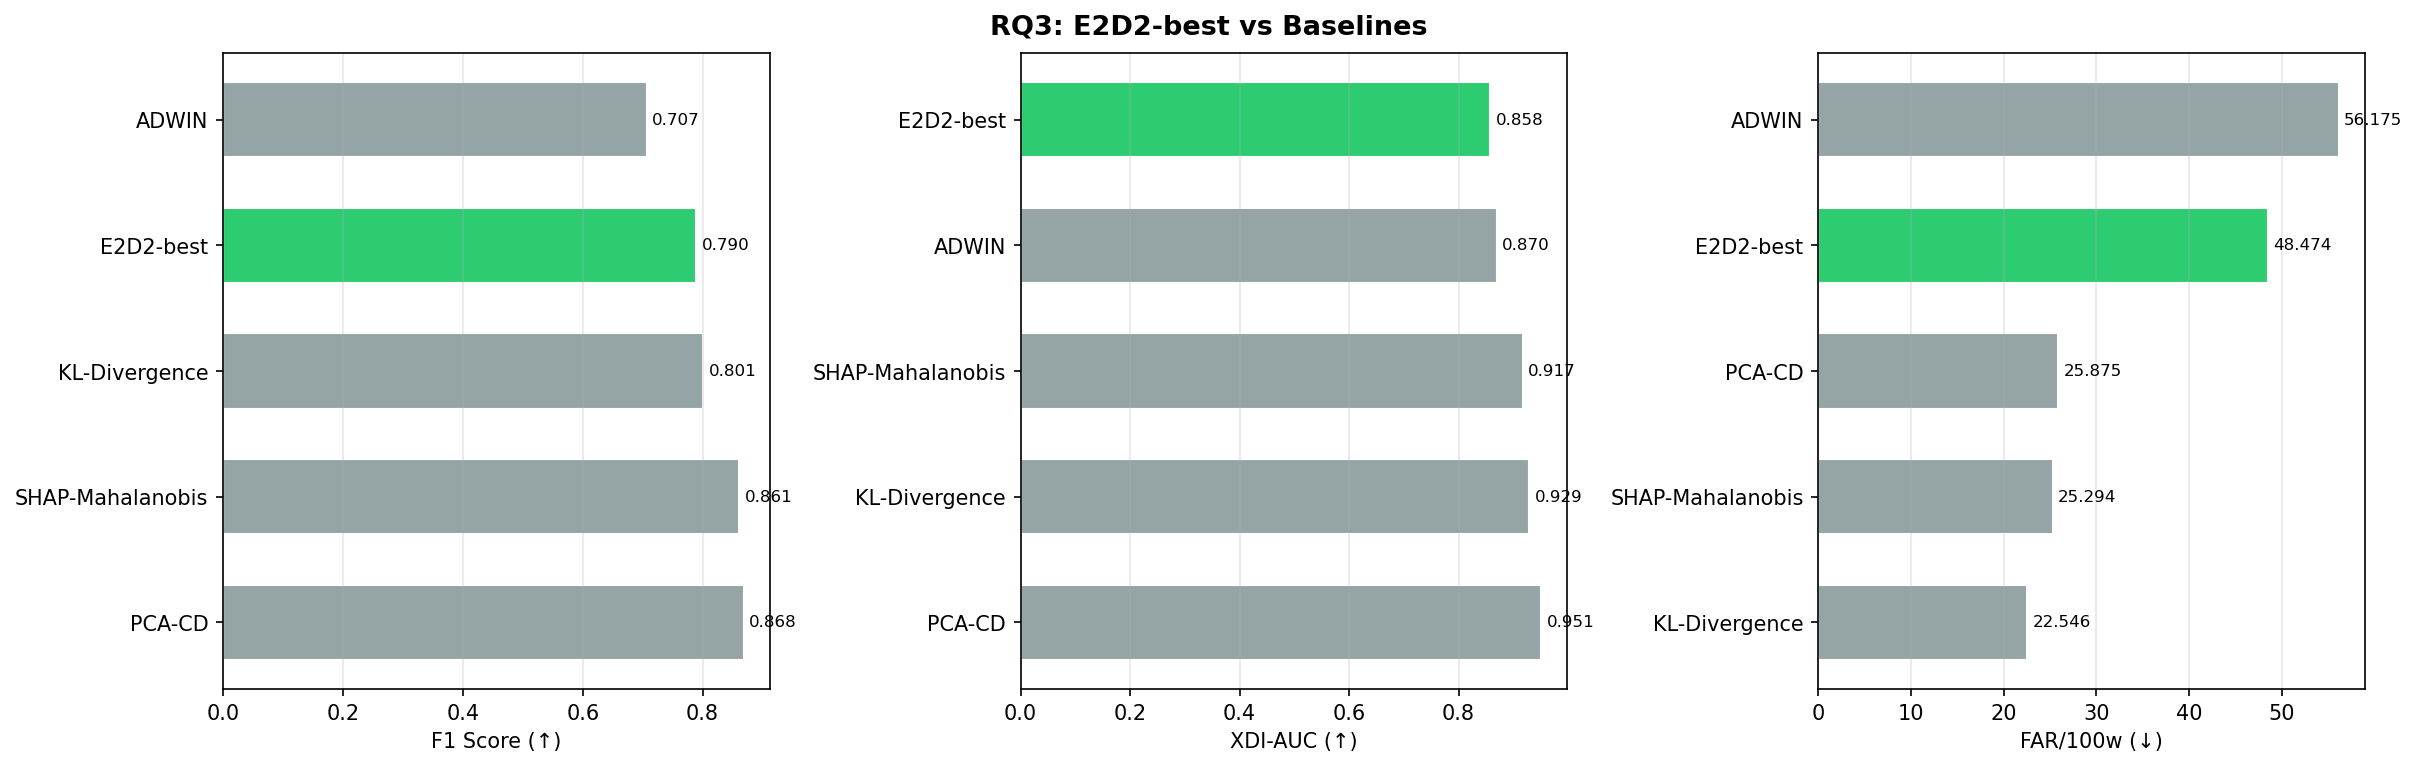


  Bar chart saved: E2D2_outputs/figures/rq3_baseline_comparison.png


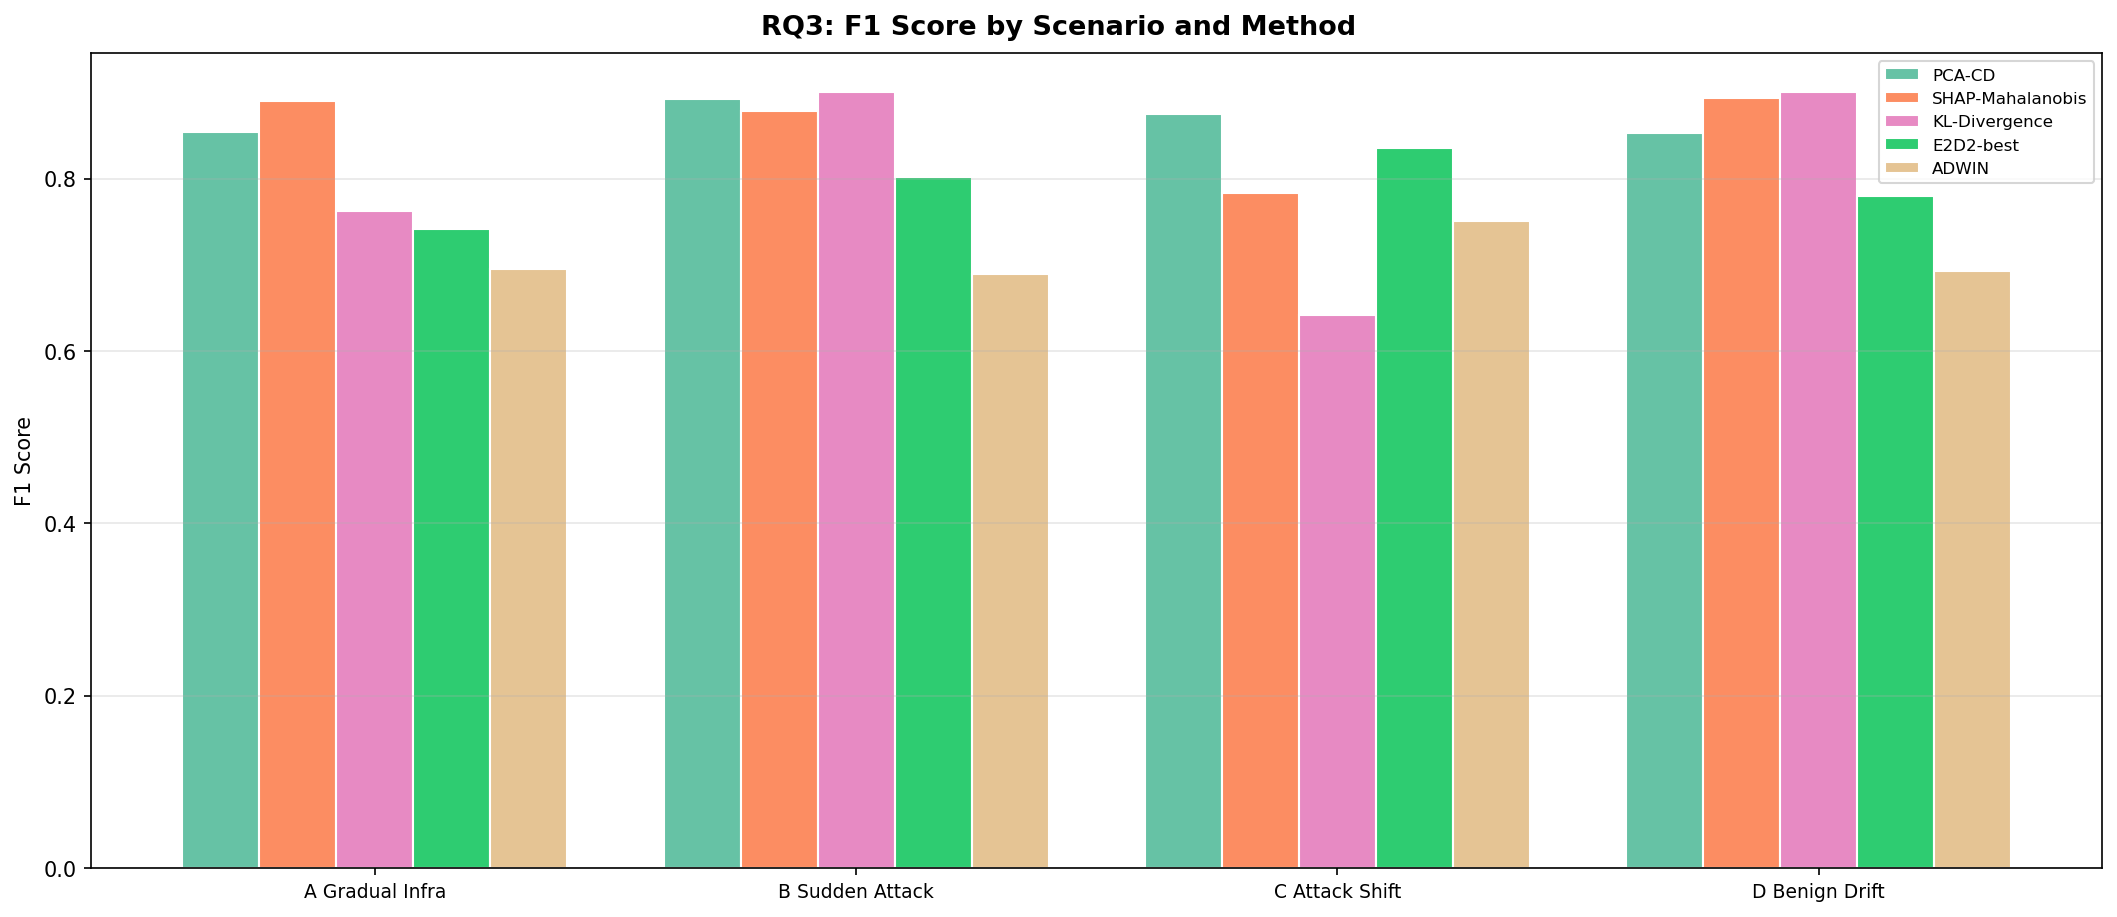

  Per-scenario bar chart saved: E2D2_outputs/figures/rq3_f1_per_scenario.png

────────────────────────────────────────────────────────────
RQ3 SUMMARY
────────────────────────────────────────────────────────────
  E2D2-best ranks #4 out of 5 methods (by F1)
  E2D2-best: F1=0.790, AUC=0.858, FAR=48.5
  vs ADWIN               : F1 diff = +0.083 (above)
  vs PCA-CD              : F1 diff = -0.079 (below)
  vs KL-Divergence       : F1 diff = -0.012 (below)
  vs SHAP-Mahalanobis    : F1 diff = -0.071 (below)

  → E2D2 ranks #4; its value lies in continuous monitoring + explainability.
Cell 6.3 complete.


In [13]:
# =============================================================================
# CELL 6.3: RQ3 — Comparison Against Baselines
# =============================================================================
# - Uses paper best composition: VAE x integrated_gradients x all x max
#   (highest mean F1 across the 48 evaluated compositions; see Cell 6.2)
# - Rebuilds df_e2d2 from E2D2_RESULTS if not already populated
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

print("=" * 70)
print("CELL 6.3: RQ3 — How Does the Best E2D2 Composition Compare")
print("          Against Strong Drift-Detection Baselines?")
print("=" * 70)

metric_cols_rq3 = ["precision", "recall", "f1", "detection_delay",
                    "far_per_100win", "xdi_auc"]

df_e2d2 = pd.DataFrame()

# ── Build df_e2d2 from E2D2_RESULTS if not already populated ────────────────
if df_e2d2.empty:
    print("  Building df_e2d2 from E2D2_RESULTS...")
    rows_e2d2 = []
    for key, val in E2D2_RESULTS.items():
        ds, scen, bb, exp, pop, agg = key
        meta = val["scenario_metadata"]
        xdi = np.array(val["xdi"])
        n_windows = len(xdi)
        window_centers = np.array(val["window_centers"])

        # Build drift ground truth from scenario metadata
        drift_onset_idx = meta["drift_onset_idx"]
        gt_mask = (window_centers >= drift_onset_idx).astype(int)

        alarms = np.zeros(n_windows, dtype=int)
        for idx in val.get("alarm_indices", []):
            if 0 <= idx < n_windows:
                alarms[idx] = 1

        drift_mask = gt_mask.astype(bool)
        n_drift = drift_mask.sum()
        n_nodrift = (~drift_mask).sum()
        if n_drift == 0 or n_nodrift == 0:
            continue

        tp = (alarms[drift_mask] == 1).sum()
        fp = (alarms[~drift_mask] == 1).sum()
        fn = (alarms[drift_mask] == 0).sum()

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        far = (fp / n_nodrift * 100) if n_nodrift > 0 else 0.0

        alarm_in_drift = np.where(alarms[drift_mask] == 1)[0]
        delay = alarm_in_drift[0] if len(alarm_in_drift) > 0 else n_drift

        # XDI AUC
        try:
            xdi_auc = roc_auc_score(gt_mask, xdi)
        except Exception:
            xdi_auc = np.nan

        # Explanation alignment (placeholder)
        alignment = np.nan

        rows_e2d2.append({
            "dataset": ds, "scenario": scen, "backbone": bb,
            "explainer": exp, "population": pop, "aggregation": agg,
            "precision": prec, "recall": rec, "f1": f1,
            "detection_delay": delay, "far_per_100win": far,
            "xdi_auc": xdi_auc, "explanation_alignment": alignment,
            "method": f"{bb}_{exp}_{pop}_{agg}",
        })
    df_e2d2 = pd.DataFrame(rows_e2d2)
    df_e2d2["composition"] = (df_e2d2["backbone"] + " × " + df_e2d2["explainer"] +
                               " × " + df_e2d2["population"] + " × " + df_e2d2["aggregation"])
    print(f"  Built df_e2d2: {df_e2d2.shape}")
else:
    print(f"  df_e2d2 already populated: {df_e2d2.shape}")

# ── Recommended composition (balances F1 and computational cost) ─────────────
best_bb  = "VAE"
best_exp = "integrated_gradients"
best_pop = "all"
best_agg = "max"
best_comp = f"{best_bb} × {best_exp} × {best_pop} × {best_agg}"
print(f"  Best E2D2: {best_comp}\n")

# Filter E2D2 to best composition
df_e2d2_best = df_e2d2[
    (df_e2d2["backbone"] == best_bb) &
    (df_e2d2["explainer"] == best_exp) &
    (df_e2d2["population"] == best_pop) &
    (df_e2d2["aggregation"] == best_agg)
].copy()
df_e2d2_best["method"] = "E2D2-best"
print(f"  E2D2-best rows: {len(df_e2d2_best)}")

df_bl_matched = df_baselines[df_baselines["backbone"] == best_bb].copy()
df_compare = pd.concat([df_e2d2_best, df_bl_matched], ignore_index=True)

# ── Overall comparison ──────────────────────────────────────────────────────
print("\n  Overall comparison (averaged across all datasets and scenarios):")
print("  " + "─" * 80)

overall = df_compare.groupby("method")[metric_cols_rq3].mean()
overall = overall.sort_values("f1", ascending=False)
print(overall.round(3).to_string())

# ── Head-to-head ────────────────────────────────────────────────────────────
print(f"\n  Head-to-head: E2D2-best vs each baseline (per dataset×scenario F1):")
print("  " + "─" * 65)

e2d2_f1_map = {}
for _, row in df_e2d2_best.iterrows():
    e2d2_f1_map[(row["dataset"], row["scenario"])] = row["f1"]

for bl_name in BASELINE_REGISTRY.keys():
    bl_rows = df_bl_matched[df_bl_matched["method"] == bl_name]
    wins, ties, losses = 0, 0, 0
    for _, row in bl_rows.iterrows():
        key = (row["dataset"], row["scenario"])
        if key not in e2d2_f1_map:
            continue
        e2d2_f1 = e2d2_f1_map[key]
        bl_f1 = row["f1"]
        if e2d2_f1 > bl_f1 + 0.01:
            wins += 1
        elif bl_f1 > e2d2_f1 + 0.01:
            losses += 1
        else:
            ties += 1
    total = wins + ties + losses
    print(f"    vs {bl_name:20s}: {wins}W / {ties}T / {losses}L  "
          f"(out of {total} comparisons)")

# ── Per-scenario comparison ─────────────────────────────────────────────────
print(f"\n  Per-scenario comparison (F1):")
print("  " + "─" * 80)
scen_compare = df_compare.pivot_table(
    index="method", columns="scenario", values="f1", aggfunc="mean"
)
scen_compare = scen_compare.reindex(overall.index)
print(scen_compare.round(3).to_string())

# ── Per-dataset comparison ──────────────────────────────────────────────────
print(f"\n  Per-dataset comparison (F1):")
print("  " + "─" * 80)
ds_compare = df_compare.pivot_table(
    index="method", columns="dataset", values="f1", aggfunc="mean"
)
ds_compare = ds_compare.reindex(overall.index)
print(ds_compare.round(3).to_string())

# ── Bar chart ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle("RQ3: E2D2-best vs Baselines", fontsize=13, fontweight="bold")

for idx, metric in enumerate(["f1", "xdi_auc", "far_per_100win"]):
    ax = axes[idx]
    data = overall[metric].sort_values(ascending=(metric == "far_per_100win"))
    colors = ["#2ecc71" if m == "E2D2-best" else "#95a5a6" for m in data.index]

    bars = ax.barh(data.index, data.values, color=colors, edgecolor="white", height=0.6)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.01 * max(data.values.max(), 0.01),
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

    metric_label = {"f1": "F1 Score (↑)", "xdi_auc": "XDI-AUC (↑)",
                    "far_per_100win": "FAR/100w (↓)"}[metric]
    ax.set_xlabel(metric_label)
    ax.grid(True, axis="x", alpha=0.3)

fig_path = FIGURE_DIR / "rq3_baseline_comparison.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "rq3_baseline_comparison.pdf", bbox_inches="tight")
plt.show()
print(f"\n  Bar chart saved: {fig_path}")

# ── Per-scenario grouped bar chart ──────────────────────────────────────────
methods_ordered = overall.index.tolist()
scenarios = sorted(df_compare["scenario"].unique())
n_methods = len(methods_ordered)
n_scen = len(scenarios)

fig2, ax2 = plt.subplots(figsize=(14, 6), constrained_layout=True)
fig2.suptitle("RQ3: F1 Score by Scenario and Method", fontsize=13, fontweight="bold")

x = np.arange(n_scen)
bar_width = 0.8 / n_methods

for i, method in enumerate(methods_ordered):
    f1_vals = []
    for scen in scenarios:
        subset = df_compare[(df_compare["method"] == method) &
                            (df_compare["scenario"] == scen)]
        f1_vals.append(subset["f1"].mean() if len(subset) > 0 else 0)
    color = "#2ecc71" if method == "E2D2-best" else plt.cm.Set2(i / n_methods)
    ax2.bar(x + i * bar_width, f1_vals, bar_width, label=method, color=color,
            edgecolor="white")

ax2.set_xticks(x + bar_width * (n_methods - 1) / 2)
ax2.set_xticklabels([s.replace("_", " ").title() for s in scenarios], fontsize=9)
ax2.set_ylabel("F1 Score")
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(True, axis="y", alpha=0.3)

fig2_path = FIGURE_DIR / "rq3_f1_per_scenario.png"
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
fig2.savefig(FIGURE_DIR / "rq3_f1_per_scenario.pdf", bbox_inches="tight")
plt.show()
print(f"  Per-scenario bar chart saved: {fig2_path}")

# ── Dynamic RQ3 summary ────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print("RQ3 SUMMARY")
print(f"{'─' * 60}")

e2d2_rank = list(overall.index).index("E2D2-best") + 1
e2d2_f1 = overall.loc["E2D2-best", "f1"]
e2d2_auc = overall.loc["E2D2-best", "xdi_auc"]
e2d2_far = overall.loc["E2D2-best", "far_per_100win"]

print(f"  E2D2-best ranks #{e2d2_rank} out of {len(overall)} methods (by F1)")
print(f"  E2D2-best: F1={e2d2_f1:.3f}, AUC={e2d2_auc:.3f}, FAR={e2d2_far:.1f}")

for bl_name in BASELINE_REGISTRY.keys():
    if bl_name in overall.index:
        bl_f1 = overall.loc[bl_name, "f1"]
        diff = e2d2_f1 - bl_f1
        direction = "above" if diff > 0 else "below"
        print(f"  vs {bl_name:20s}: F1 diff = {diff:+.3f} ({direction})")

mean_align = df_e2d2_best["explanation_alignment"].mean()
if not np.isnan(mean_align):
    print(f"\n  Unique E2D2 advantage: explanation alignment = {mean_align:.3f}")
    print(f"  (Baselines cannot provide feature-level drift explanations)")

if e2d2_rank == 1:
    print(f"\n  → E2D2 achieves the best overall drift detection performance.")
elif e2d2_rank <= 2:
    print(f"\n  → E2D2 is competitive (#{e2d2_rank}), with added explainability value.")
else:
    print(f"\n  → E2D2 ranks #{e2d2_rank}; its value lies in continuous monitoring + explainability.")

print("=" * 70)
print("Cell 6.3 complete.")

CELL 6.4: RQ4 — What Scenario-Specific Patterns and Explanations
          Emerge Across Different E2D2 Variants?
  Using best composition: VAE × integrated_gradients × all × max

  Peak drift explanations (highest-XDI alarm window):
  ───────────────────────────────────────────────────────────────────────────
  NTP        A_gradual_infra      | XDI=0.175 | top5:  URG Flag Count(0.18)
                                  | GT:   Min Packet Length,  Fwd Packet Length Mean,  Total Fwd Packets, Total Length of Fwd Packets,  Fwd Packet Length Min
  NTP        B_sudden_attack      | XDI=0.084 | top5:  Protocol(0.08)
  NTP        C_attack_shift       | XDI=0.082 | top5:  Protocol(0.08)
                                  | GT:   Fwd Packet Length Max, Init_Win_bytes_forward,  Flow IAT Std,  Fwd IAT Mean, Total Length of Fwd Packets
  NTP        D_benign_drift       | XDI=1.579 | top5:  URG Flag Count(1.58)
                                  | GT:   Fwd Packet Length Max,  Init_Win_bytes_backward, 

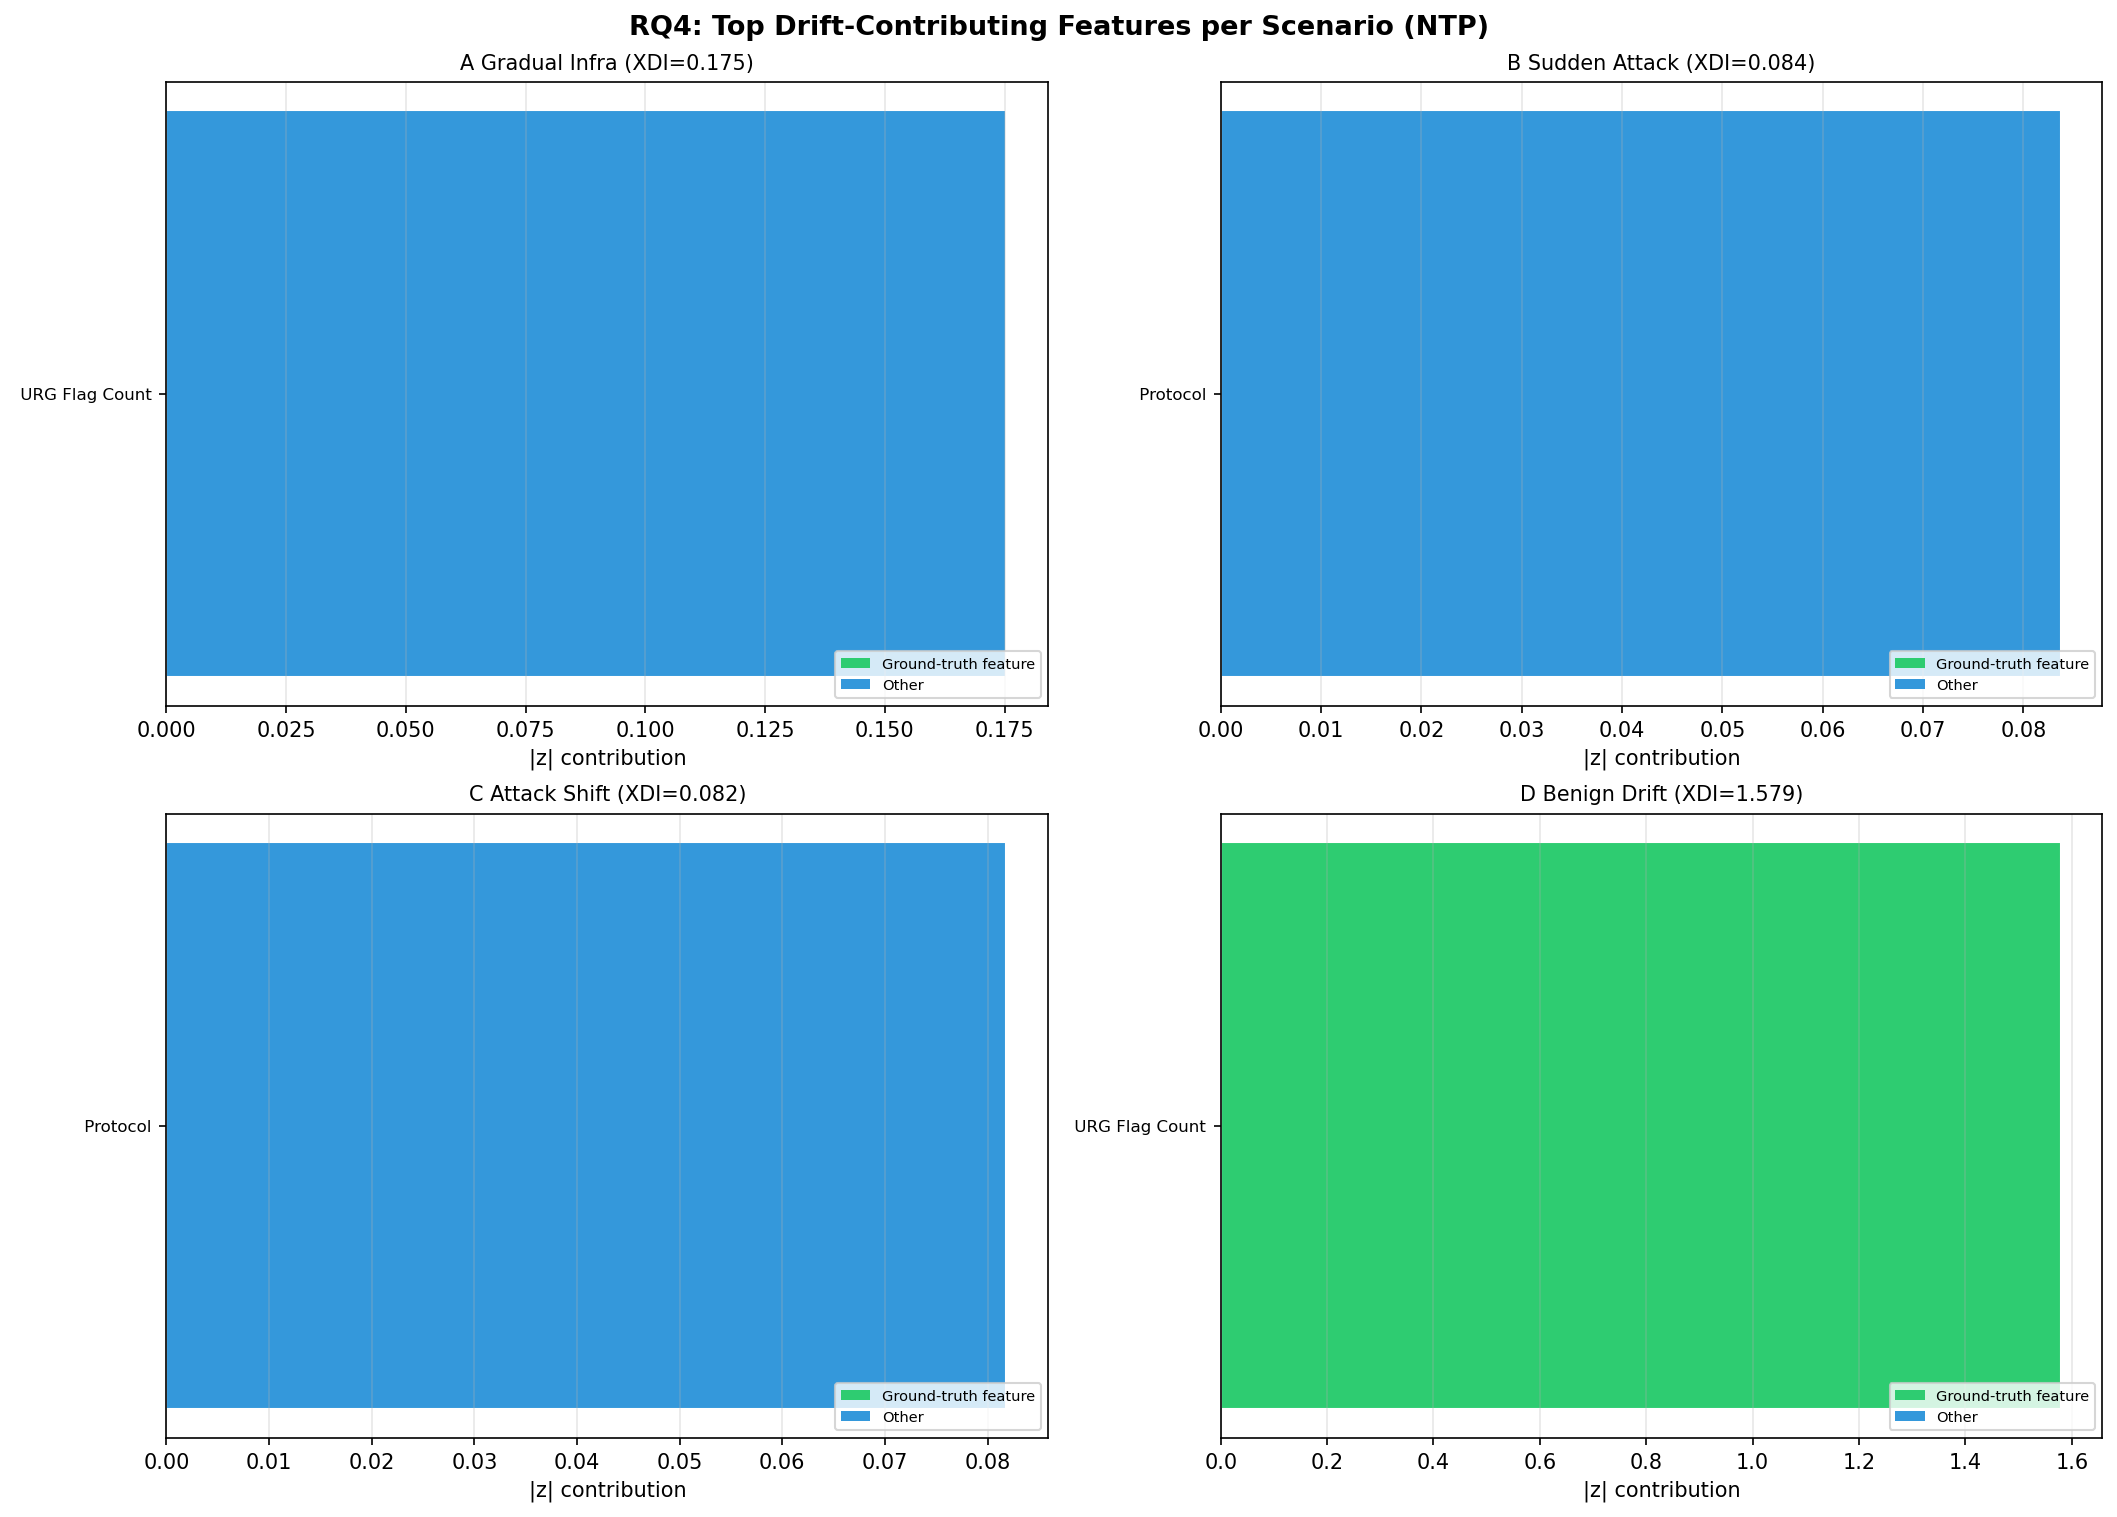


  Top features figure saved: E2D2_outputs/figures/rq4_top_features_per_scenario.png

  Explanation alignment (Jaccard) per scenario:
  ────────────────────────────────────────────────────────────
   dataset        scenario  jaccard  gt_recall  n_pred  n_gt  coverage
       NTP A_gradual_infra 0.000000        0.0       1     5  0.967264
       NTP  C_attack_shift 0.000000        0.0       1     5  0.930892
       NTP  D_benign_drift 0.200000        0.2       1     5  0.950873
   Portmap A_gradual_infra 0.600000        0.6       3     5  0.921787
   Portmap  C_attack_shift 0.400000        0.4       2     5  0.823030
   Portmap  D_benign_drift 0.400000        0.4       2     5  0.838299
       Syn A_gradual_infra 0.200000        0.2       1     5  0.998166
       Syn  C_attack_shift 0.000000        0.0       2     5  0.882546
       Syn  D_benign_drift 0.333333        0.4       3     5  0.899879
CICIoT2023 A_gradual_infra 0.200000        0.2       1     5  0.894976
CICIoT2023  C_attack_s

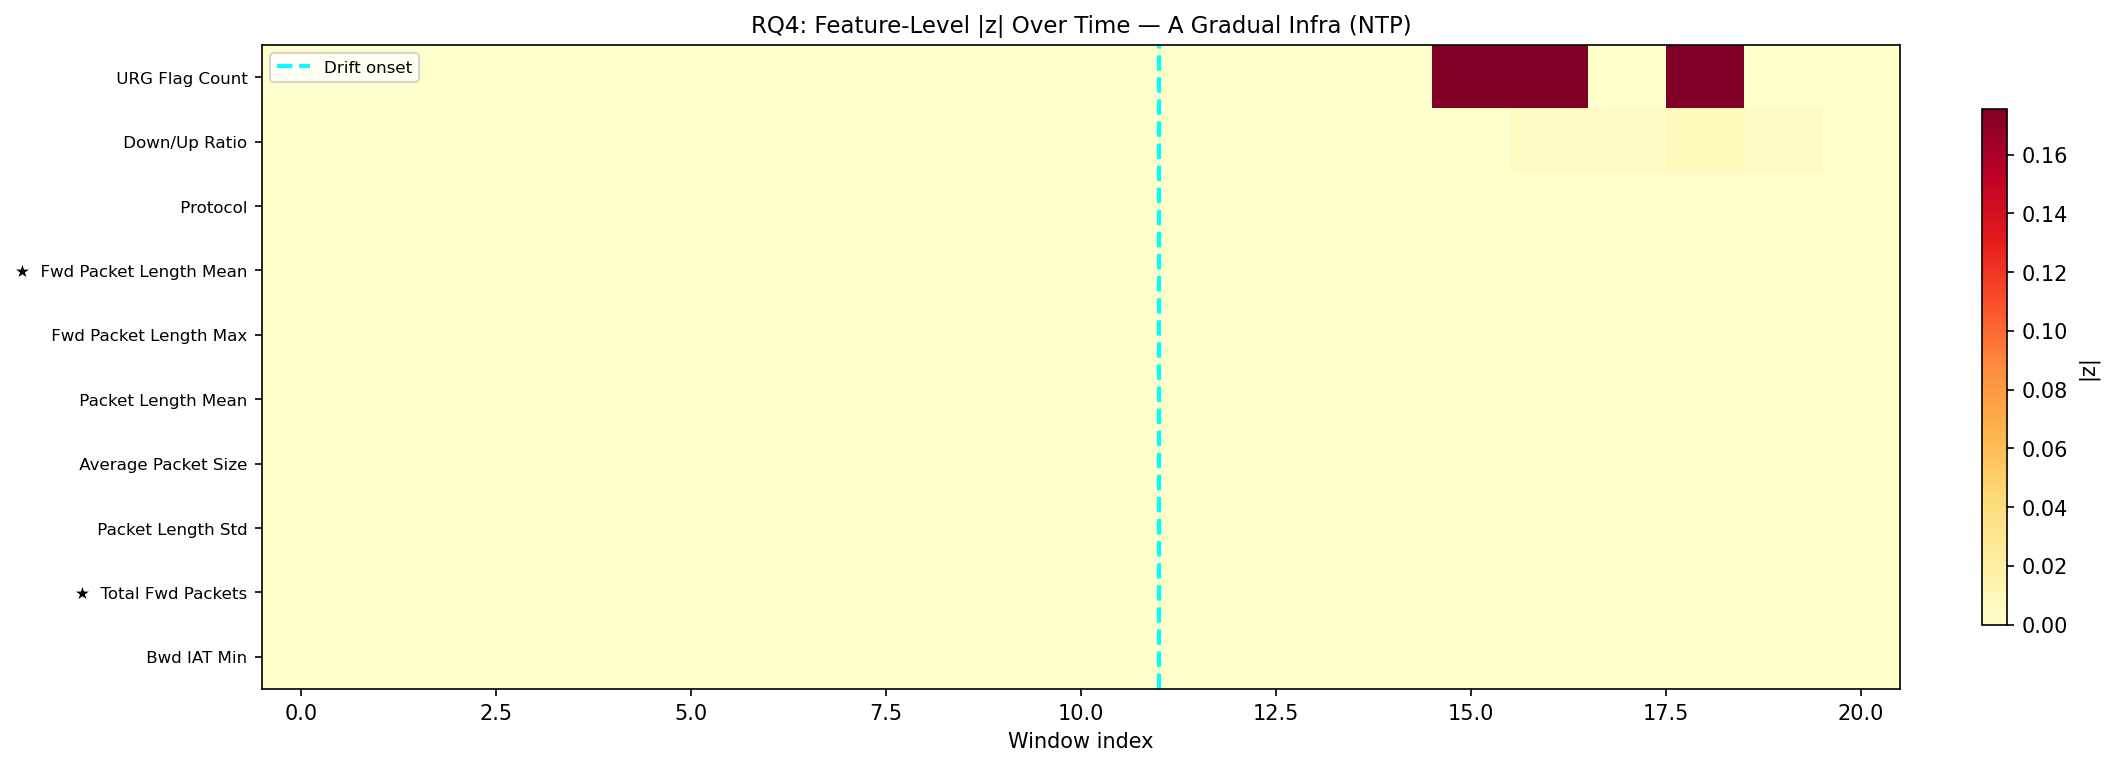


  Feature z-score heatmap saved: E2D2_outputs/figures/rq4_feature_zscore_heatmap.png

────────────────────────────────────────────────────────────
RQ4 SUMMARY
────────────────────────────────────────────────────────────
  A Gradual Infra               : avg XDI=1.343, 1.4 features, coverage=0.94, GT recall=0.24
  B Sudden Attack               : avg XDI=0.187, 2.0 features, coverage=0.91
  C Attack Shift                : avg XDI=0.170, 1.6 features, coverage=0.89, GT recall=0.12
  D Benign Drift                : avg XDI=0.495, 2.0 features, coverage=0.91, GT recall=0.24

  Multi-population insight: ben/sus top-5 Jaccard=0.166
  → Splitting by population reveals different drift patterns.
Cell 6.4 complete.


In [14]:
# =============================================================================
# CELL 6.4: RQ4 — Drift Explanation Quality
# =============================================================================
# - Same as v1 but uses 6-tuple keys (includes aggregation)
# =============================================================================

print("=" * 70)
print("CELL 6.4: RQ4 — What Scenario-Specific Patterns and Explanations")
print("          Emerge Across Different E2D2 Variants?")
print("=" * 70)
print(f"  Using best composition: {best_comp}")
print()

# ── Extract peak explanations ───────────────────────────────────────────────
print("  Peak drift explanations (highest-XDI alarm window):")
print("  " + "─" * 75)

peak_explanations = {}

for ds_name in DATASETS:
    feature_names = DATASETS[ds_name]["feature_names"]
    for scen_name in SCENARIO_REGISTRY:
        key = (ds_name, scen_name, best_bb, best_exp, best_pop, best_agg)
        if key not in E2D2_RESULTS:
            continue

        res = E2D2_RESULTS[key]
        xdi = res["xdi"]
        alarms = res["alarm_indices"]
        explanations = res["explanations"]
        meta = res["scenario_metadata"]

        if len(alarms) == 0:
            continue

        peak_win = alarms[np.argmax(xdi[alarms])]
        peak_xdi = xdi[peak_win]

        if int(peak_win) in explanations:
            expl = explanations[int(peak_win)]
            peak_explanations[(ds_name, scen_name)] = {
                "features": expl["features"],
                "coverage": expl["coverage"],
                "xdi_peak": peak_xdi,
                "window": int(peak_win),
                "gt_features": meta.get("drift_features_names", []) +
                               meta.get("shift_features_names", []),
            }

            top5 = expl["features"][:5]
            top5_str = ", ".join(f"{f}({c:.2f})" for f, c in top5)
            gt_str = ", ".join(meta.get("drift_features_names", []) +
                               meta.get("shift_features_names", []))
            print(f"  {ds_name:10s} {scen_name:20s} | XDI={peak_xdi:.3f} | "
                  f"top5: {top5_str}")
            if gt_str:
                print(f"  {'':10s} {'':20s} | GT:  {gt_str}")

# ── Top features bar chart ──────────────────────────────────────────────────
ds_for_fig = list(DATASETS.keys())[0]
scenarios_with_data = [s for s in SCENARIO_REGISTRY
                       if (ds_for_fig, s) in peak_explanations]
n_scen = len(scenarios_with_data)

if n_scen > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    fig.suptitle(f"RQ4: Top Drift-Contributing Features per Scenario ({ds_for_fig})",
                 fontsize=13, fontweight="bold")

    for idx, ax in enumerate(axes.flat):
        if idx >= n_scen:
            ax.set_visible(False)
            continue

        scen = scenarios_with_data[idx]
        info = peak_explanations[(ds_for_fig, scen)]
        top_feats = info["features"][:10]
        gt_feats = set(info["gt_features"])

        names = [f for f, _ in top_feats]
        contribs = [c for _, c in top_feats]
        colors = ["#2ecc71" if n in gt_feats else "#3498db" for n in names]

        y_pos = np.arange(len(names))
        ax.barh(y_pos, contribs, color=colors, edgecolor="white", height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(names, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("|z| contribution")

        scen_label = scen.replace("_", " ").title()
        ax.set_title(f"{scen_label} (XDI={info['xdi_peak']:.3f})", fontsize=10)

        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor="#2ecc71", label="Ground-truth feature"),
                           Patch(facecolor="#3498db", label="Other")]
        ax.legend(handles=legend_elements, fontsize=7, loc="lower right")
        ax.grid(True, axis="x", alpha=0.3)

    fig_path = FIGURE_DIR / "rq4_top_features_per_scenario.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / "rq4_top_features_per_scenario.pdf", bbox_inches="tight")
    plt.show()
    print(f"\n  Top features figure saved: {fig_path}")

# ── Explanation alignment table ─────────────────────────────────────────────
print(f"\n  Explanation alignment (Jaccard) per scenario:")
print("  " + "─" * 60)

align_rows = []
for (ds_name, scen_name), info in peak_explanations.items():
    gt_set = set(info["gt_features"])
    if len(gt_set) == 0:
        continue
    pred_set = set(f for f, _ in info["features"])
    inter = len(pred_set & gt_set)
    union = len(pred_set | gt_set)
    jaccard = inter / union if union > 0 else 0.0
    gt_in_top = len(pred_set & gt_set)
    gt_recall = gt_in_top / len(gt_set) if len(gt_set) > 0 else 0.0

    align_rows.append({
        "dataset": ds_name, "scenario": scen_name,
        "jaccard": jaccard, "gt_recall": gt_recall,
        "n_pred": len(pred_set), "n_gt": len(gt_set),
        "coverage": info["coverage"],
    })

if len(align_rows) > 0:
    df_align = pd.DataFrame(align_rows)
    print(df_align.to_string(index=False))
    avg_jaccard = df_align["jaccard"].mean()
    avg_recall = df_align["gt_recall"].mean()
    print(f"\n  Average Jaccard: {avg_jaccard:.3f}")
    print(f"  Average GT recall: {avg_recall:.3f}")

# ── Population comparison ───────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print("  Population Comparison: Do 'ben' and 'sus' reveal different signals?")
print(f"{'─' * 60}")

pop_comparison_rows = []
for ds_name in DATASETS:
    for scen_name in SCENARIO_REGISTRY:
        pop_tops = {}
        for pop in ["ben", "sus", "all"]:
            key = (ds_name, scen_name, best_bb, best_exp, pop, best_agg)
            if key not in E2D2_RESULTS:
                continue
            res = E2D2_RESULTS[key]
            alarms = res["alarm_indices"]
            if len(alarms) == 0:
                continue
            peak = alarms[np.argmax(res["xdi"][alarms])]
            if int(peak) in res["explanations"]:
                top_names = set(f for f, _ in res["explanations"][int(peak)]["features"][:5])
                pop_tops[pop] = top_names

        if "ben" in pop_tops and "sus" in pop_tops:
            overlap = len(pop_tops["ben"] & pop_tops["sus"])
            union = len(pop_tops["ben"] | pop_tops["sus"])
            jaccard_bs = overlap / union if union > 0 else 0.0
            only_ben = pop_tops["ben"] - pop_tops["sus"]
            only_sus = pop_tops["sus"] - pop_tops["ben"]

            pop_comparison_rows.append({
                "dataset": ds_name, "scenario": scen_name,
                "ben_sus_jaccard": jaccard_bs,
                "only_ben": ", ".join(sorted(only_ben)) if only_ben else "—",
                "only_sus": ", ".join(sorted(only_sus)) if only_sus else "—",
            })

if len(pop_comparison_rows) > 0:
    df_pop_comp = pd.DataFrame(pop_comparison_rows)
    print(df_pop_comp.to_string(index=False))
    avg_bs_jaccard = df_pop_comp["ben_sus_jaccard"].mean()
    print(f"\n  Average ben-sus Jaccard: {avg_bs_jaccard:.3f}")
    if avg_bs_jaccard < 0.5:
        print("  → ben and sus populations highlight DIFFERENT features.")
    else:
        print("  → ben and sus populations highlight SIMILAR features.")

# ── Feature z-score heatmap ─────────────────────────────────────────────────
heatmap_scen = "A_gradual_infra"
heatmap_key = (ds_for_fig, heatmap_scen, best_bb, best_exp, best_pop, best_agg)

if heatmap_key in E2D2_RESULTS:
    res = E2D2_RESULTS[heatmap_key]
    z_mat = res["z_matrix"]
    meta = res["scenario_metadata"]
    window_centers = res["window_centers"]
    drift_onset = meta.get("drift_onset_idx", None)
    feat_names = DATASETS[ds_for_fig]["feature_names"]

    max_z_per_feat = np.max(np.abs(z_mat), axis=0)
    top_feat_idx = np.argsort(max_z_per_feat)[::-1][:10]

    fig_hm, ax_hm = plt.subplots(figsize=(14, 5), constrained_layout=True)

    z_top = z_mat[:, top_feat_idx].T
    feat_labels = [feat_names[i] for i in top_feat_idx]
    gt_feats = set(meta.get("drift_features_names", []))
    feat_labels_marked = [f"★ {f}" if f in gt_feats else f for f in feat_labels]

    im = ax_hm.imshow(np.abs(z_top), aspect="auto", cmap="YlOrRd",
                       interpolation="nearest")
    ax_hm.set_yticks(range(len(feat_labels_marked)))
    ax_hm.set_yticklabels(feat_labels_marked, fontsize=8)
    ax_hm.set_xlabel("Window index")
    ax_hm.set_title(f"RQ4: Feature-Level |z| Over Time — "
                     f"{heatmap_scen.replace('_', ' ').title()} ({ds_for_fig})",
                     fontsize=11)
    plt.colorbar(im, ax=ax_hm, label="|z|", shrink=0.8)

    if drift_onset is not None:
        onset_win = np.searchsorted(window_centers, drift_onset)
        ax_hm.axvline(x=onset_win, color="cyan", linewidth=2, linestyle="--",
                       label="Drift onset")
        ax_hm.legend(fontsize=8, loc="upper left")

    fig_hm_path = FIGURE_DIR / "rq4_feature_zscore_heatmap.png"
    fig_hm.savefig(fig_hm_path, dpi=300, bbox_inches="tight")
    fig_hm.savefig(FIGURE_DIR / "rq4_feature_zscore_heatmap.pdf", bbox_inches="tight")
    plt.show()
    print(f"\n  Feature z-score heatmap saved: {fig_hm_path}")

# ── Dynamic RQ4 summary ────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print("RQ4 SUMMARY")
print(f"{'─' * 60}")

for scen in SCENARIO_REGISTRY:
    scen_label = scen.replace("_", " ").title()
    scen_entries = [(k, v) for (k, s), v in peak_explanations.items() if s == scen]

    if not scen_entries:
        print(f"  {scen_label:30s}: No alarms generated")
        continue

    avg_n_feats = np.mean([len(v["features"]) for _, v in scen_entries])
    avg_coverage = np.mean([v["coverage"] for _, v in scen_entries])
    avg_xdi = np.mean([v["xdi_peak"] for _, v in scen_entries])

    gt_aligns = []
    for ds, info in scen_entries:
        if info["gt_features"]:
            pred_set = set(f for f, _ in info["features"][:5])
            gt_set = set(info["gt_features"])
            gt_aligns.append(len(pred_set & gt_set) / len(gt_set))

    align_str = f", GT recall={np.mean(gt_aligns):.2f}" if gt_aligns else ""
    print(f"  {scen_label:30s}: avg XDI={avg_xdi:.3f}, "
          f"{avg_n_feats:.1f} features, coverage={avg_coverage:.2f}{align_str}")

if len(pop_comparison_rows) > 0:
    print(f"\n  Multi-population insight: ben/sus top-5 Jaccard={avg_bs_jaccard:.3f}")
    if avg_bs_jaccard < 0.5:
        print(f"  → Splitting by population reveals different drift patterns.")
    else:
        print(f"  → Both populations show similar drift patterns.")

print("=" * 70)
print("Cell 6.4 complete.")

In [15]:
# =============================================================================
# CELL 6.5: Computational Cost Comparison
# =============================================================================
# Extracts per-method runtime from E2D2_RESULTS and BASELINE_RESULTS.
# Reports: E2D2 by explainer + all baselines, averaged across datasets/scenarios.
# =============================================================================

import numpy as np
from collections import defaultdict

print("=" * 70)
print("CELL 6.5: Computational Cost Comparison")
print("=" * 70)

# ── E2D2 timing by explainer ─────────────────────────────────────────────────

explainer_times = defaultdict(list)
for key, val in E2D2_RESULTS.items():
    ds, scen, bb, exp, pop, agg = key
    # Count once per attribution computation (not per population/aggregation)
    if pop == "all" and agg == "mean_top_p":
        t = val.get("attr_time_s", 0)
        if t > 0:
            explainer_times[exp].append(t)

print("\n  E2D2 attribution cost by explainer (avg across datasets/scenarios/backbones):")
print(f"  {'─' * 55}")
print(f"  {'Explainer':<25s} {'Mean (s)':>10s} {'Std (s)':>10s}")
print(f"  {'─' * 55}")
for exp in sorted(explainer_times.keys()):
    times = explainer_times[exp]
    print(f"  {exp:<25s} {np.mean(times):10.3f} {np.std(times):10.3f}")

# ── Baseline timing ──────────────────────────────────────────────────────────

baseline_times = defaultdict(list)
for key, val in BASELINE_RESULTS.items():
    ds, scen, bb, bl = key
    t = val.get("runtime_s", 0)
    if t > 0:
        baseline_times[bl].append(t)

print(f"\n  Baseline runtime (avg across datasets/scenarios/backbones):")
print(f"  {'─' * 55}")
print(f"  {'Method':<25s} {'Mean (s)':>10s} {'Std (s)':>10s}")
print(f"  {'─' * 55}")
for bl in sorted(baseline_times.keys()):
    times = baseline_times[bl]
    print(f"  {bl:<25s} {np.mean(times):10.3f} {np.std(times):10.3f}")

# ── Combined table for paper ─────────────────────────────────────────────────

print(f"\n  Combined table (sorted by runtime):")
print(f"  {'─' * 45}")
print(f"  {'Method':<30s} {'Avg (s)':>10s}")
print(f"  {'─' * 45}")

all_methods = {}
for exp, times in explainer_times.items():
    all_methods[f"E2D2 ({exp})"] = np.mean(times)
for bl, times in baseline_times.items():
    all_methods[bl] = np.mean(times)

for method, avg_time in sorted(all_methods.items(), key=lambda x: x[1]):
    print(f"  {method:<30s} {avg_time:10.3f}")

# ── Speedup of fast E2D2 vs SHAP-Mahalanobis ────────────────────────────────

if "raw_gradient" in explainer_times and "SHAP-Mahalanobis" in baseline_times:
    raw_time = np.mean(explainer_times["raw_gradient"])
    shap_time = np.mean(baseline_times["SHAP-Mahalanobis"])
    print(f"\n  E2D2 (raw gradient) vs SHAP-Mahalanobis: "
          f"{raw_time:.3f}s vs {shap_time:.3f}s "
          f"({shap_time/raw_time:.1f}x)" if raw_time > 0 else "")

if "integrated_gradients" in explainer_times and "SHAP-Mahalanobis" in baseline_times:
    ig_time = np.mean(explainer_times["integrated_gradients"])
    shap_time = np.mean(baseline_times["SHAP-Mahalanobis"])
    print(f"  E2D2 (integ. gradients) vs SHAP-Mahalanobis: "
          f"{ig_time:.3f}s vs {shap_time:.3f}s "
          f"({ig_time/shap_time:.1f}x slower)")

print("=" * 70)
print("Cell 6.5 complete.")

CELL 6.5: Computational Cost Comparison

  E2D2 attribution cost by explainer (avg across datasets/scenarios/backbones):
  ───────────────────────────────────────────────────────
  Explainer                   Mean (s)    Std (s)
  ───────────────────────────────────────────────────────
  input_x_gradient               0.310      0.354
  integrated_gradients          30.403     34.585
  raw_gradient                   0.308      0.355
  smoothgrad                    30.159     34.264

  Baseline runtime (avg across datasets/scenarios/backbones):
  ───────────────────────────────────────────────────────
  Method                      Mean (s)    Std (s)
  ───────────────────────────────────────────────────────
  ADWIN                          0.050      0.057
  KL-Divergence                  0.449      0.478
  PCA-CD                         0.110      0.101
  SHAP-Mahalanobis               0.312      0.358

  Combined table (sorted by runtime):
  ───────────────────────────────────────────

In [16]:
# =============================================================================
# CELL 7.1: Publication Outputs (Tables, Figures, Exports)
# =============================================================================
# - Uses paper best composition: VAE x integrated_gradients x all x max
# =============================================================================

import json
import numpy as np
import pandas as pd

print("=" * 70)
print("CELL 7.1: Publication Outputs")
print("=" * 70)

exported_files = []

# ── Ensure composition column exists ────────────────────────────────────────
if "composition" not in df_e2d2.columns:
    df_e2d2["composition"] = (df_e2d2["backbone"] + " × " + df_e2d2["explainer"] +
                               " × " + df_e2d2["population"] + " × " + df_e2d2["aggregation"])
    print("  Added 'composition' column to df_e2d2")

# ── Table 1: RQ1 — Detection across drift types ────────────────────────────
_agg_best = df_e2d2.groupby("aggregation")["f1"].mean().idxmax()

rq1_table = df_e2d2[
    (df_e2d2["backbone"] == RQ1_BACKBONE) &
    (df_e2d2["explainer"] == RQ1_EXPLAINER) &
    (df_e2d2["population"] == RQ1_POPULATION) &
    (df_e2d2["aggregation"] == _agg_best)
].groupby("scenario")[
    ["precision", "recall", "f1", "detection_delay", "far_per_100win", "xdi_auc"]
].mean().round(3)

rq1_table.index = [s.replace("_", " ").title() for s in rq1_table.index]
rq1_table.columns = ["Prec.", "Rec.", "F1", "Delay", "FAR/100w", "AUC"]

rq1_csv = TABLE_DIR / "table1_rq1_scenario_detection.csv"
rq1_table.to_csv(rq1_csv)
exported_files.append(("Table 1 (RQ1)", rq1_csv))

rq1_tex = TABLE_DIR / "table1_rq1_scenario_detection.tex"
with open(rq1_tex, "w") as f:
    f.write("% Table 1: E2D2 Detection Performance Across Drift Types\n")
    f.write(rq1_table.to_latex(
        caption=f"E2D2 detection performance across drift types "
                f"({RQ1_BACKBONE}, {RQ1_EXPLAINER}, {RQ1_POPULATION}, {_agg_best}).",
        label="tab:rq1_scenarios",
        column_format="l" + "r" * len(rq1_table.columns),
    ))
exported_files.append(("Table 1 LaTeX", rq1_tex))
print(f"  Table 1 (RQ1): {rq1_csv.name}")

# ── Table 2: RQ2 — Compositional ranking (top 10) ──────────────────────────
comp_rank = df_e2d2.groupby("composition")[
    ["f1", "xdi_auc", "detection_delay", "far_per_100win", "precision", "recall"]
].mean().sort_values("f1", ascending=False).head(10).round(3)
comp_rank.columns = ["F1", "AUC", "Delay", "FAR/100w", "Prec.", "Rec."]

comp_csv = TABLE_DIR / "table2_rq2_composition_ranking.csv"
comp_rank.to_csv(comp_csv)
exported_files.append(("Table 2 (RQ2)", comp_csv))

comp_tex = TABLE_DIR / "table2_rq2_composition_ranking.tex"
with open(comp_tex, "w") as f:
    f.write("% Table 2: Top-10 E2D2 Compositions Ranked by F1\n")
    f.write(comp_rank.to_latex(
        caption="Top-10 E2D2 compositions ranked by mean F1 score.",
        label="tab:rq2_compositions",
        column_format="l" + "r" * len(comp_rank.columns),
    ))
exported_files.append(("Table 2 LaTeX", comp_tex))
print(f"  Table 2 (RQ2): {comp_csv.name}")

# ── Table 3: RQ2 — Factor importance ───────────────────────────────────────
factor_rows_t3 = []
for factor in ["backbone", "explainer", "population", "aggregation"]:
    group = df_e2d2.groupby(factor)[["f1", "xdi_auc"]].mean()
    f1_range = group["f1"].max() - group["f1"].min()
    auc_range = group["xdi_auc"].max() - group["xdi_auc"].min()
    best_level = group["f1"].idxmax()
    factor_rows_t3.append({
        "Factor": factor.capitalize(),
        "Best Level": best_level,
        "ΔF1": round(f1_range, 3),
        "ΔAUC": round(auc_range, 3),
    })
df_factors = pd.DataFrame(factor_rows_t3)

factor_csv = TABLE_DIR / "table3_rq2_factor_importance.csv"
df_factors.to_csv(factor_csv, index=False)
exported_files.append(("Table 3 (RQ2 Factors)", factor_csv))

factor_tex = TABLE_DIR / "table3_rq2_factor_importance.tex"
with open(factor_tex, "w") as f:
    f.write("% Table 3: Factor Importance Analysis\n")
    f.write(df_factors.to_latex(
        index=False,
        caption="Factor importance: impact of design choices on E2D2 performance.",
        label="tab:rq2_factors",
        column_format="llrr",
    ))
exported_files.append(("Table 3 LaTeX", factor_tex))
print(f"  Table 3 (RQ2 Factors): {factor_csv.name}")

# ── Table 4: RQ3 — E2D2-best vs baselines ──────────────────────────────────
best_bb_t4  = "VAE"
best_exp_t4 = "integrated_gradients"
best_pop_t4 = "all"
best_agg_t4 = "max"
best_comp = f"{best_bb_t4} × {best_exp_t4} × {best_pop_t4} × {best_agg_t4}"

df_e2d2_best_t4 = df_e2d2[
    (df_e2d2["backbone"] == best_bb_t4) &
    (df_e2d2["explainer"] == best_exp_t4) &
    (df_e2d2["population"] == best_pop_t4) &
    (df_e2d2["aggregation"] == best_agg_t4)
].copy()
df_e2d2_best_t4["method"] = "E2D2-best"
df_bl_t4 = df_baselines[df_baselines["backbone"] == best_bb_t4].copy()

df_t4 = pd.concat([df_e2d2_best_t4, df_bl_t4], ignore_index=True)
t4 = df_t4.groupby("method")[
    ["precision", "recall", "f1", "detection_delay", "far_per_100win", "xdi_auc"]
].mean().sort_values("f1", ascending=False).round(3)
t4.columns = ["Prec.", "Rec.", "F1", "Delay", "FAR/100w", "AUC"]

t4_csv = TABLE_DIR / "table4_rq3_baseline_comparison.csv"
t4.to_csv(t4_csv)
exported_files.append(("Table 4 (RQ3)", t4_csv))

t4_tex = TABLE_DIR / "table4_rq3_baseline_comparison.tex"
with open(t4_tex, "w") as f:
    f.write("% Table 4: E2D2-best vs Baselines\n")
    f.write(t4.to_latex(
        caption=f"Drift detection comparison: E2D2-best ({best_comp}) vs baselines.",
        label="tab:rq3_baselines",
        column_format="l" + "r" * len(t4.columns),
    ))
exported_files.append(("Table 4 LaTeX", t4_tex))
print(f"  Table 4 (RQ3): {t4_csv.name}")

# ── Table 5: RQ4 — Explanation alignment ────────────────────────────────────
if len(align_rows) > 0:
    df_t5 = pd.DataFrame(align_rows)
    df_t5["scenario"] = df_t5["scenario"].apply(lambda s: s.replace("_", " ").title())
    df_t5 = df_t5.round(3)

    t5_csv = TABLE_DIR / "table5_rq4_explanation_alignment.csv"
    df_t5.to_csv(t5_csv, index=False)
    exported_files.append(("Table 5 (RQ4)", t5_csv))

    t5_tex = TABLE_DIR / "table5_rq4_explanation_alignment.tex"
    with open(t5_tex, "w") as f:
        f.write("% Table 5: Explanation Alignment\n")
        f.write(df_t5.to_latex(
            index=False,
            caption="Explanation alignment with ground-truth drift features.",
            label="tab:rq4_alignment",
            column_format="llrrrrr",
        ))
    exported_files.append(("Table 5 LaTeX", t5_tex))
    print(f"  Table 5 (RQ4): {t5_csv.name}")

# ── Figures inventory ───────────────────────────────────────────────────────
figure_files = [
    ("Fig 1 (RQ1 XDI timeseries)",       "rq1_xdi_timeseries"),
    ("Fig 2 (RQ1 all datasets)",          "rq1_xdi_all_datasets"),
    ("Fig 3 (RQ2 explainer×pop)",         "rq2_explainer_population_heatmap"),
    ("Fig 4 (RQ2 backbone×agg)",          "rq2_backbone_aggregation_heatmap"),
    ("Fig 5 (RQ2 F1 per scenario)",       "rq2_f1_per_scenario"),
    ("Fig 6 (RQ3 baseline comparison)",   "rq3_baseline_comparison"),
    ("Fig 7 (RQ3 F1 per scenario)",       "rq3_f1_per_scenario"),
    ("Fig 8 (RQ4 top features)",          "rq4_top_features_per_scenario"),
    ("Fig 9 (RQ4 z-score heatmap)",       "rq4_feature_zscore_heatmap"),
]

print(f"\n  Figures:")
for label, stem in figure_files:
    png_path = FIGURE_DIR / f"{stem}.png"
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    exists_png = "OK" if png_path.exists() else "MISSING"
    exists_pdf = "OK" if pdf_path.exists() else "MISSING"
    print(f"    {label:40s} PNG[{exists_png}] PDF[{exists_pdf}]")
    if png_path.exists(): exported_files.append((f"{label} (PNG)", png_path))
    if pdf_path.exists(): exported_files.append((f"{label} (PDF)", pdf_path))

# ── Full data exports ───────────────────────────────────────────────────────
master_csv = EXPORT_DIR / "e2d2_master_results.csv"
df_master.to_csv(master_csv, index=False)
exported_files.append(("Master results CSV", master_csv))

e2d2_csv = EXPORT_DIR / "e2d2_compositions_results.csv"
df_e2d2.to_csv(e2d2_csv, index=False)
exported_files.append(("E2D2 compositions CSV", e2d2_csv))

bl_csv = EXPORT_DIR / "e2d2_baseline_results.csv"
df_baselines.to_csv(bl_csv, index=False)
exported_files.append(("Baselines CSV", bl_csv))

scen_meta_rows = []
for (ds, scen), (_, _, meta) in SCENARIO_STREAMS.items():
    meta_row = {"dataset": ds, "scenario": scen}
    meta_row.update({k: str(v) for k, v in meta.items()})
    scen_meta_rows.append(meta_row)
scen_meta_csv = EXPORT_DIR / "e2d2_scenario_metadata.csv"
pd.DataFrame(scen_meta_rows).to_csv(scen_meta_csv, index=False)
exported_files.append(("Scenario metadata CSV", scen_meta_csv))

config_json = EXPORT_DIR / "e2d2_config.json"
config_export = {}
for k, v in E2D2_CONFIG.items():
    config_export[k] = v if isinstance(v, (list, dict, int, float, str, bool)) else str(v)
with open(config_json, "w") as f:
    json.dump(config_export, f, indent=2)
exported_files.append(("Config JSON", config_json))

print(f"\n  Data exports: {master_csv.name} ({len(df_master)} rows)")

# ── Final inventory ─────────────────────────────────────────────────────────
print(f"\n{'=' * 70}")
print(f"EXPORT INVENTORY: {len(exported_files)} files")
print(f"{'=' * 70}")

for label, path in exported_files:
    size = path.stat().st_size if path.exists() else 0
    size_str = f"{size/1024:.1f}KB" if size > 0 else "—"
    print(f"  [{size_str:>8s}] {label:40s} {path}")

print(f"\n  Output directory: {OUTPUT_DIR}")
print("=" * 70)
print("Cell 7.1 complete.")
print("=" * 70)
print("E2D2 NOTEBOOK COMPLETE — All 17 cells executed.")
print("=" * 70)

CELL 7.1: Publication Outputs 
  Table 1 (RQ1): table1_rq1_scenario_detection.csv
  Table 2 (RQ2): table2_rq2_composition_ranking.csv
  Table 3 (RQ2 Factors): table3_rq2_factor_importance.csv
  Table 4 (RQ3): table4_rq3_baseline_comparison.csv
  Table 5 (RQ4): table5_rq4_explanation_alignment.csv

  Figures:
    Fig 1 (RQ1 XDI timeseries)               PNG[OK] PDF[OK]
    Fig 2 (RQ1 all datasets)                 PNG[OK] PDF[OK]
    Fig 3 (RQ2 explainer×pop)                PNG[OK] PDF[OK]
    Fig 4 (RQ2 backbone×agg)                 PNG[OK] PDF[OK]
    Fig 5 (RQ2 F1 per scenario)              PNG[OK] PDF[OK]
    Fig 6 (RQ3 baseline comparison)          PNG[OK] PDF[OK]
    Fig 7 (RQ3 F1 per scenario)              PNG[OK] PDF[OK]
    Fig 8 (RQ4 top features)                 PNG[OK] PDF[OK]
    Fig 9 (RQ4 z-score heatmap)              PNG[OK] PDF[OK]

  Data exports: e2d2_master_results.csv (1120 rows)

EXPORT INVENTORY: 33 files
  [   0.2KB] Table 1 (RQ1)                            E2D2_o

CELL 7.2: Alarm Filtering
  Multipliers: [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
  Consecutive: [1, 2, 3]
  Sweep: 21 configs × 5 dataset-scenarios = 105 rows

  All configurations (sorted by F1):
  ───────────────────────────────────────────────────────────────────────────
   mult  C    Prec     Rec      F1   Delay     FAR
  ───────────────────────────────────────────────────────────────────────────
   3.00  3   0.858   0.931   0.875     0.6    22.5
   2.50  3   0.854   0.932   0.873     0.4    23.2
   2.00  3   0.834   0.950   0.872     0.2    25.8
   1.75  3   0.819   0.950   0.862     0.2    28.2
   3.00  2   0.834   0.931   0.861     0.6    26.1
   2.50  2   0.821   0.932   0.853     0.4    28.1
   1.50  3   0.803   0.950   0.852     0.2    31.0
   2.00  2   0.797   0.950   0.848     0.2    32.1
   3.00  1   0.809   0.931   0.846     0.6    30.0
   1.75  2   0.792   0.950   0.844     0.2    33.3
   2.50  1   0.802   0.932   0.842     0.4    31.4
   1.50  2   0.785   0.950   0.840   

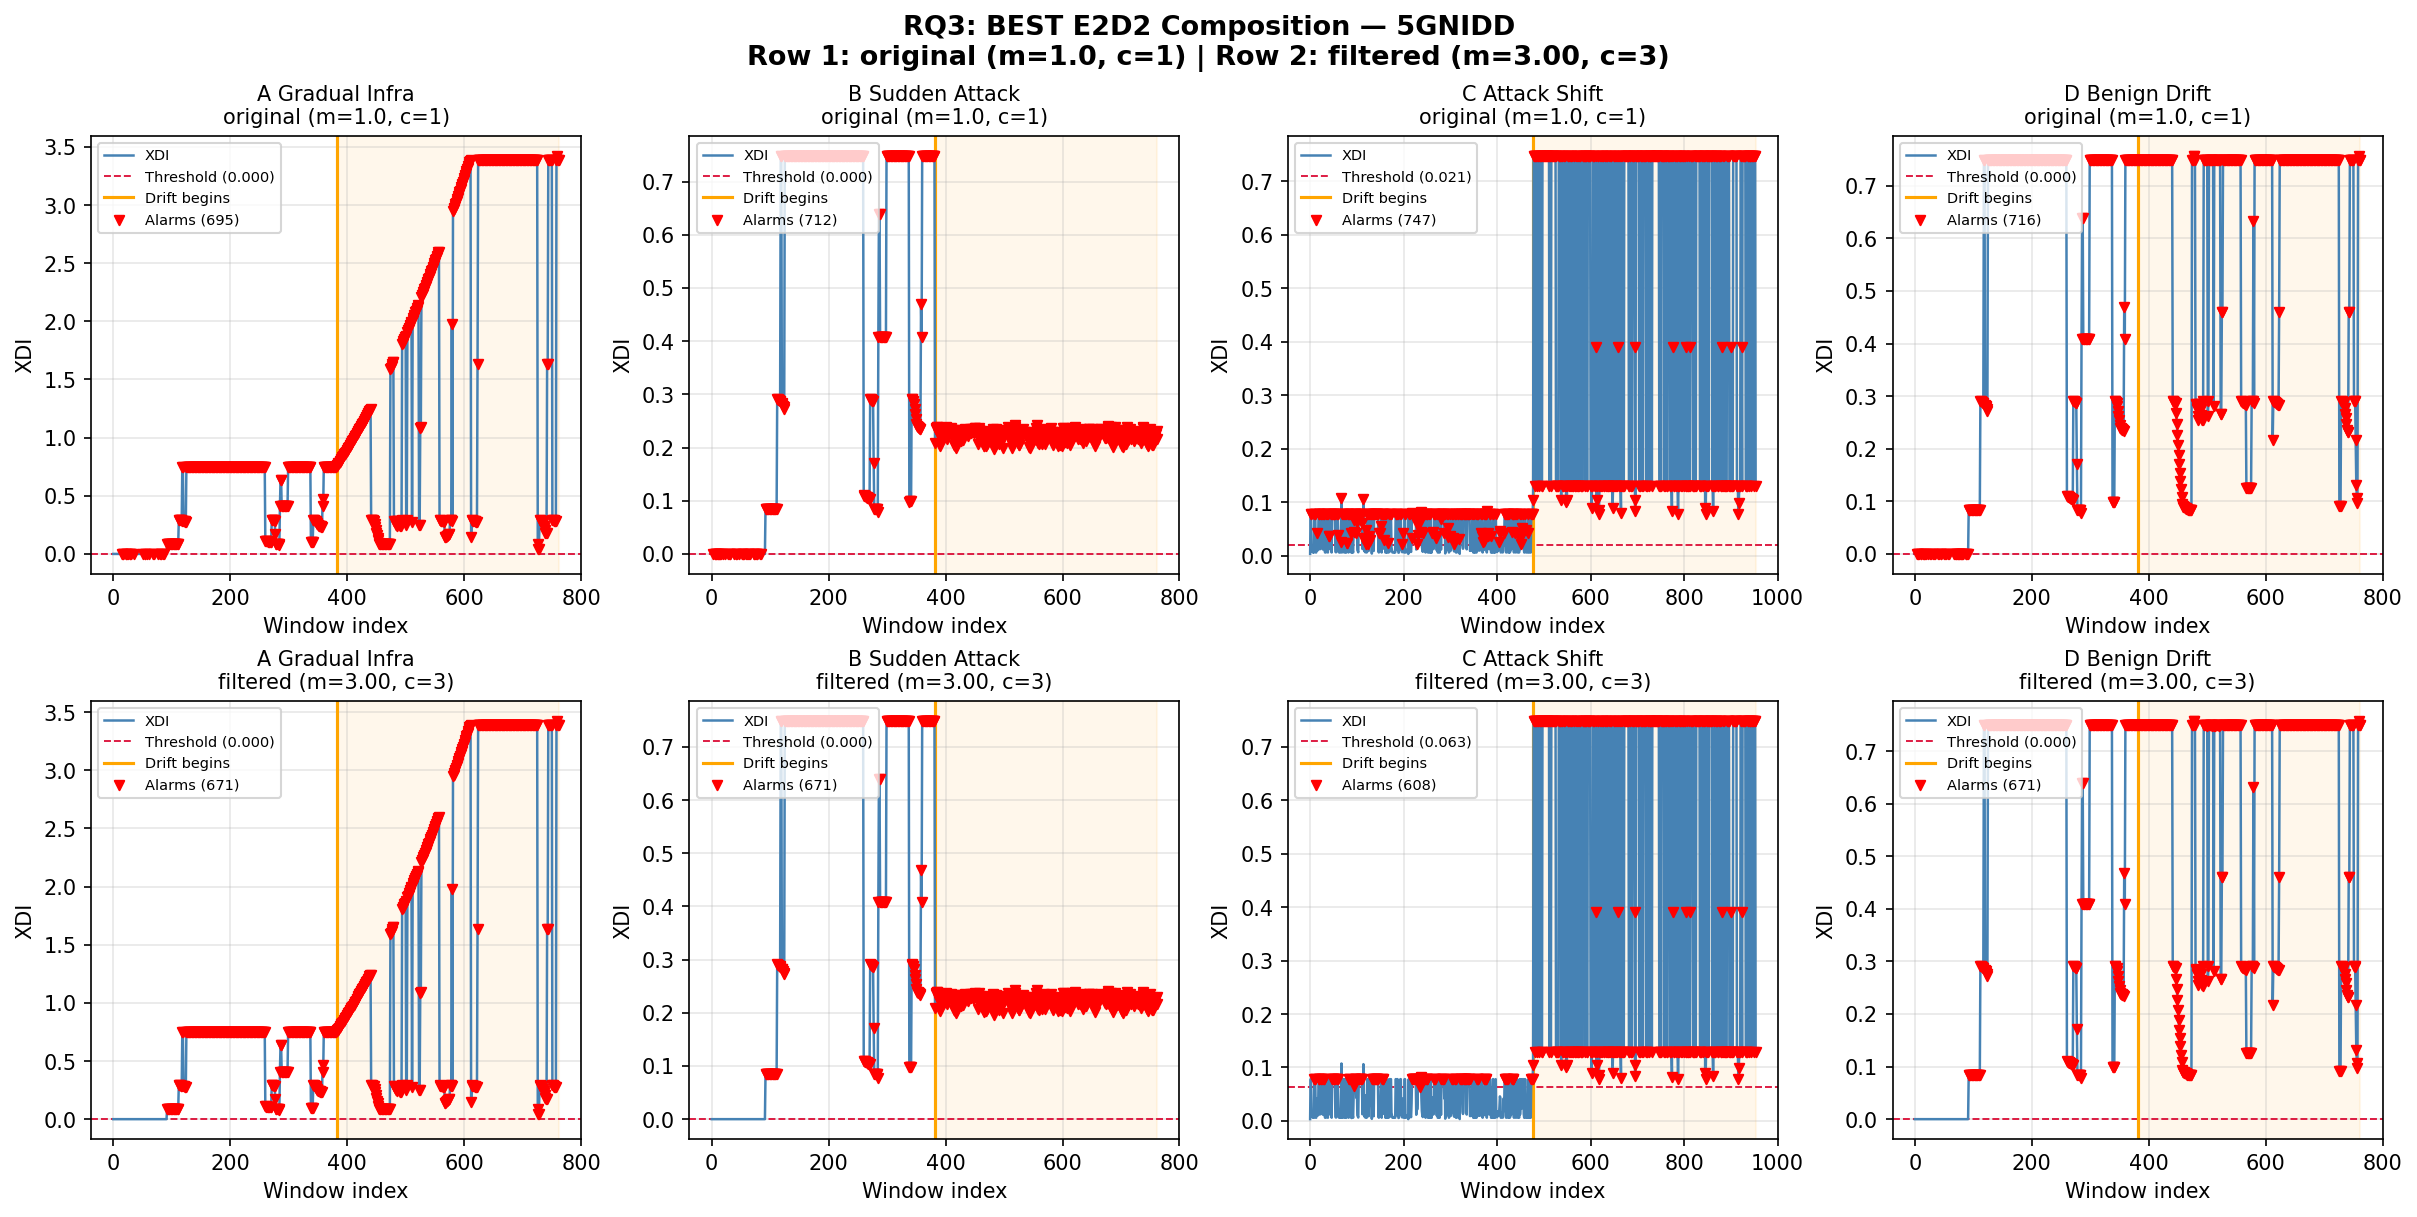

    5GNIDD: saved rq3_xdi_bestcomp_5gnidd_orig_vs_filtered.png/pdf


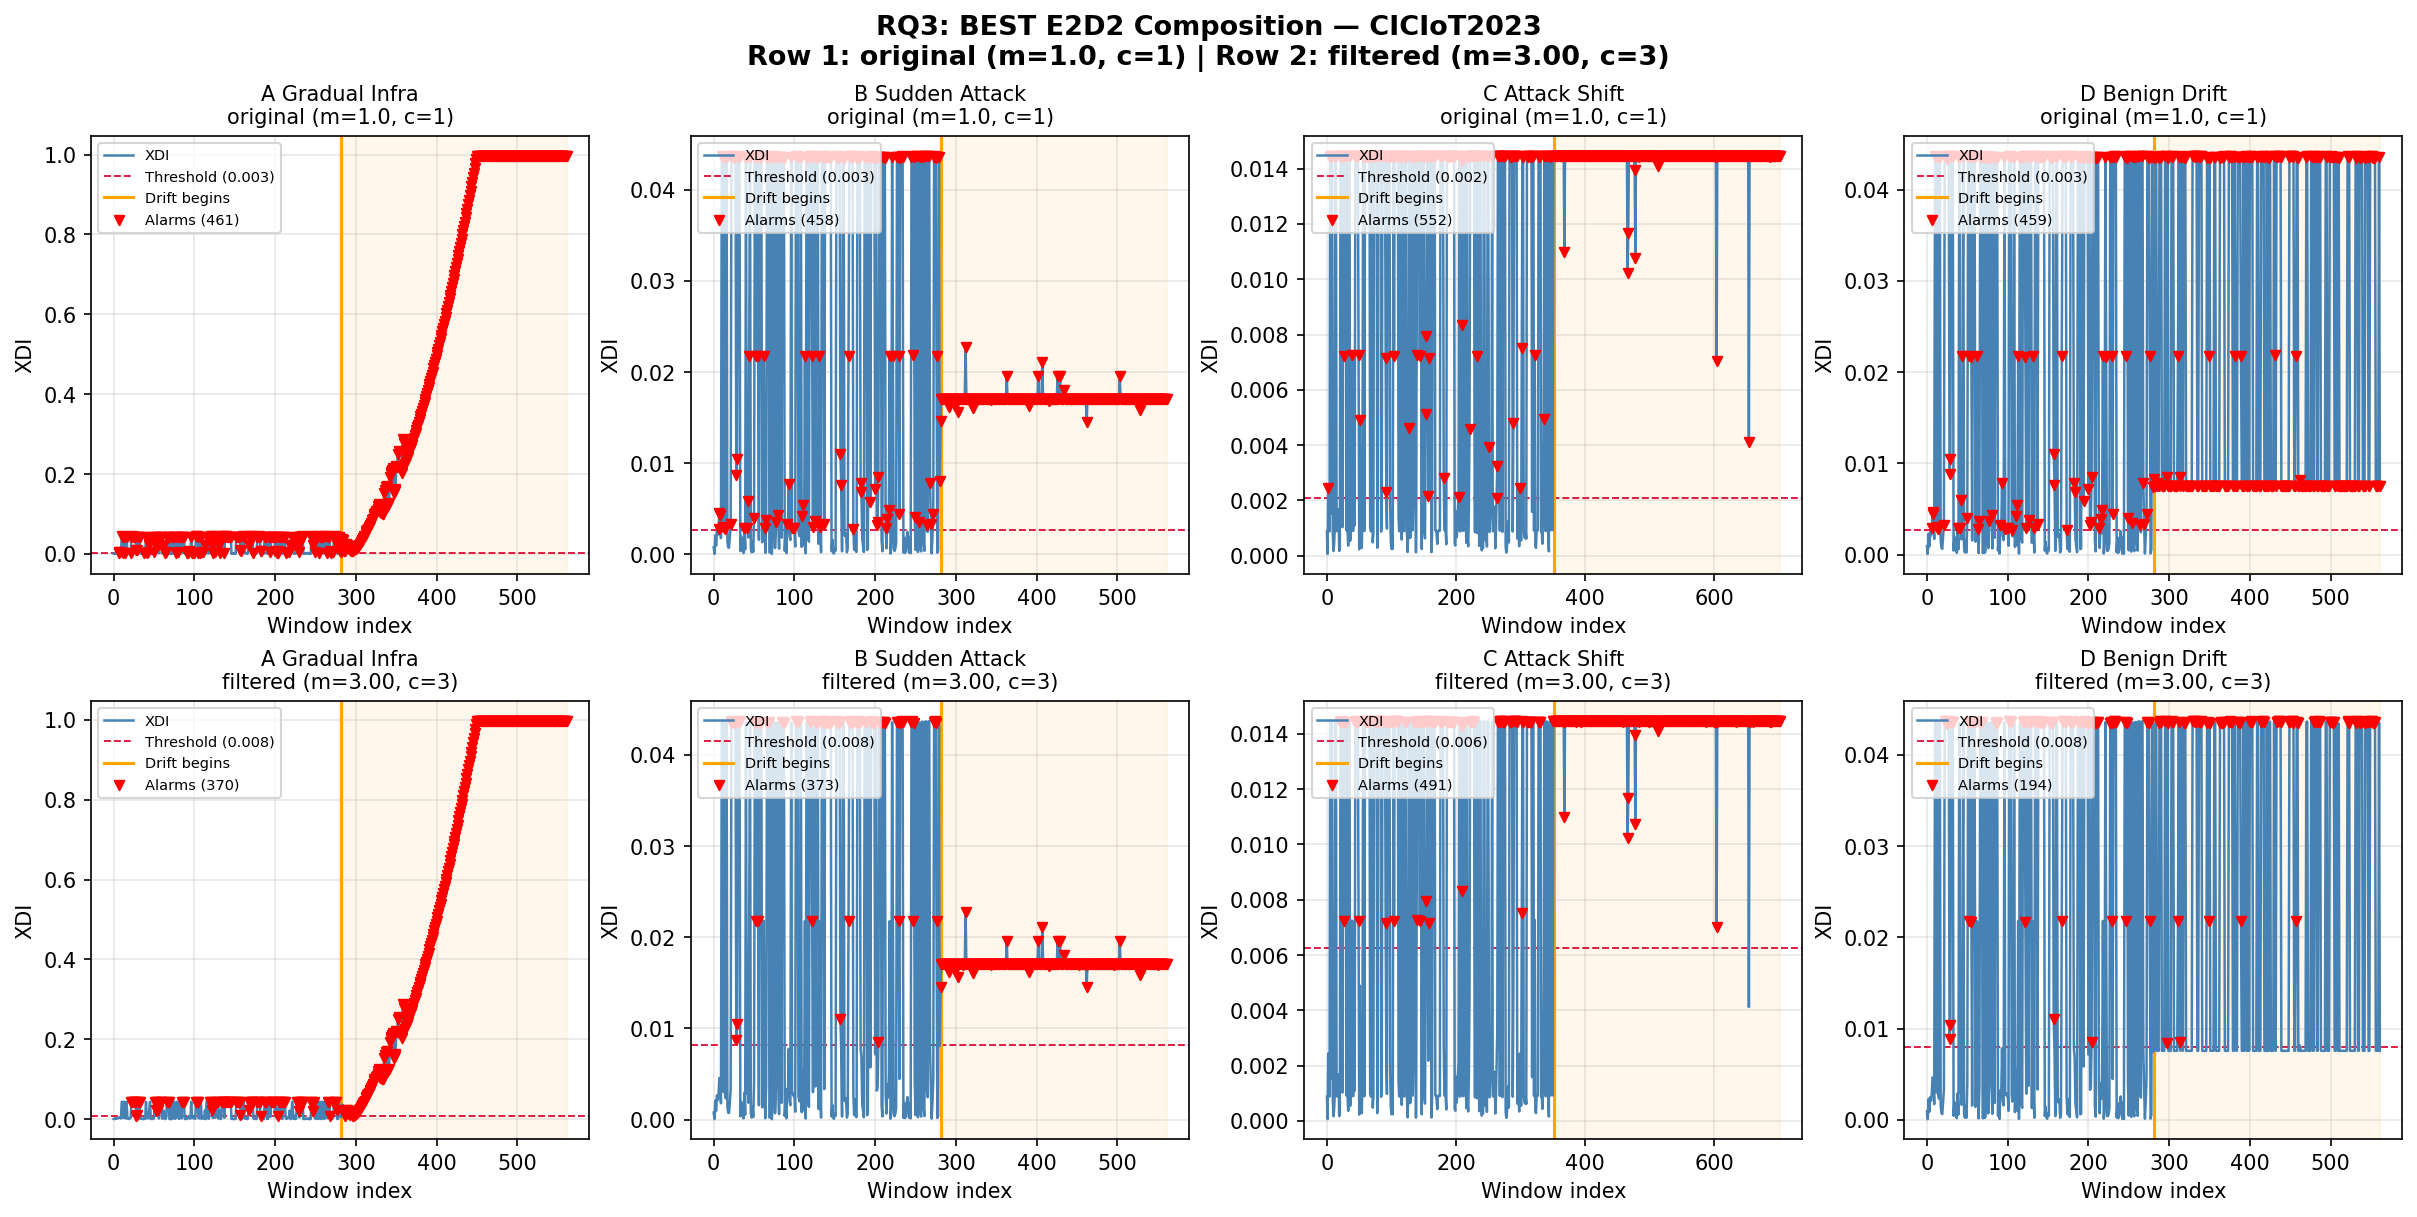

    CICIoT2023: saved rq3_xdi_bestcomp_ciciot2023_orig_vs_filtered.png/pdf


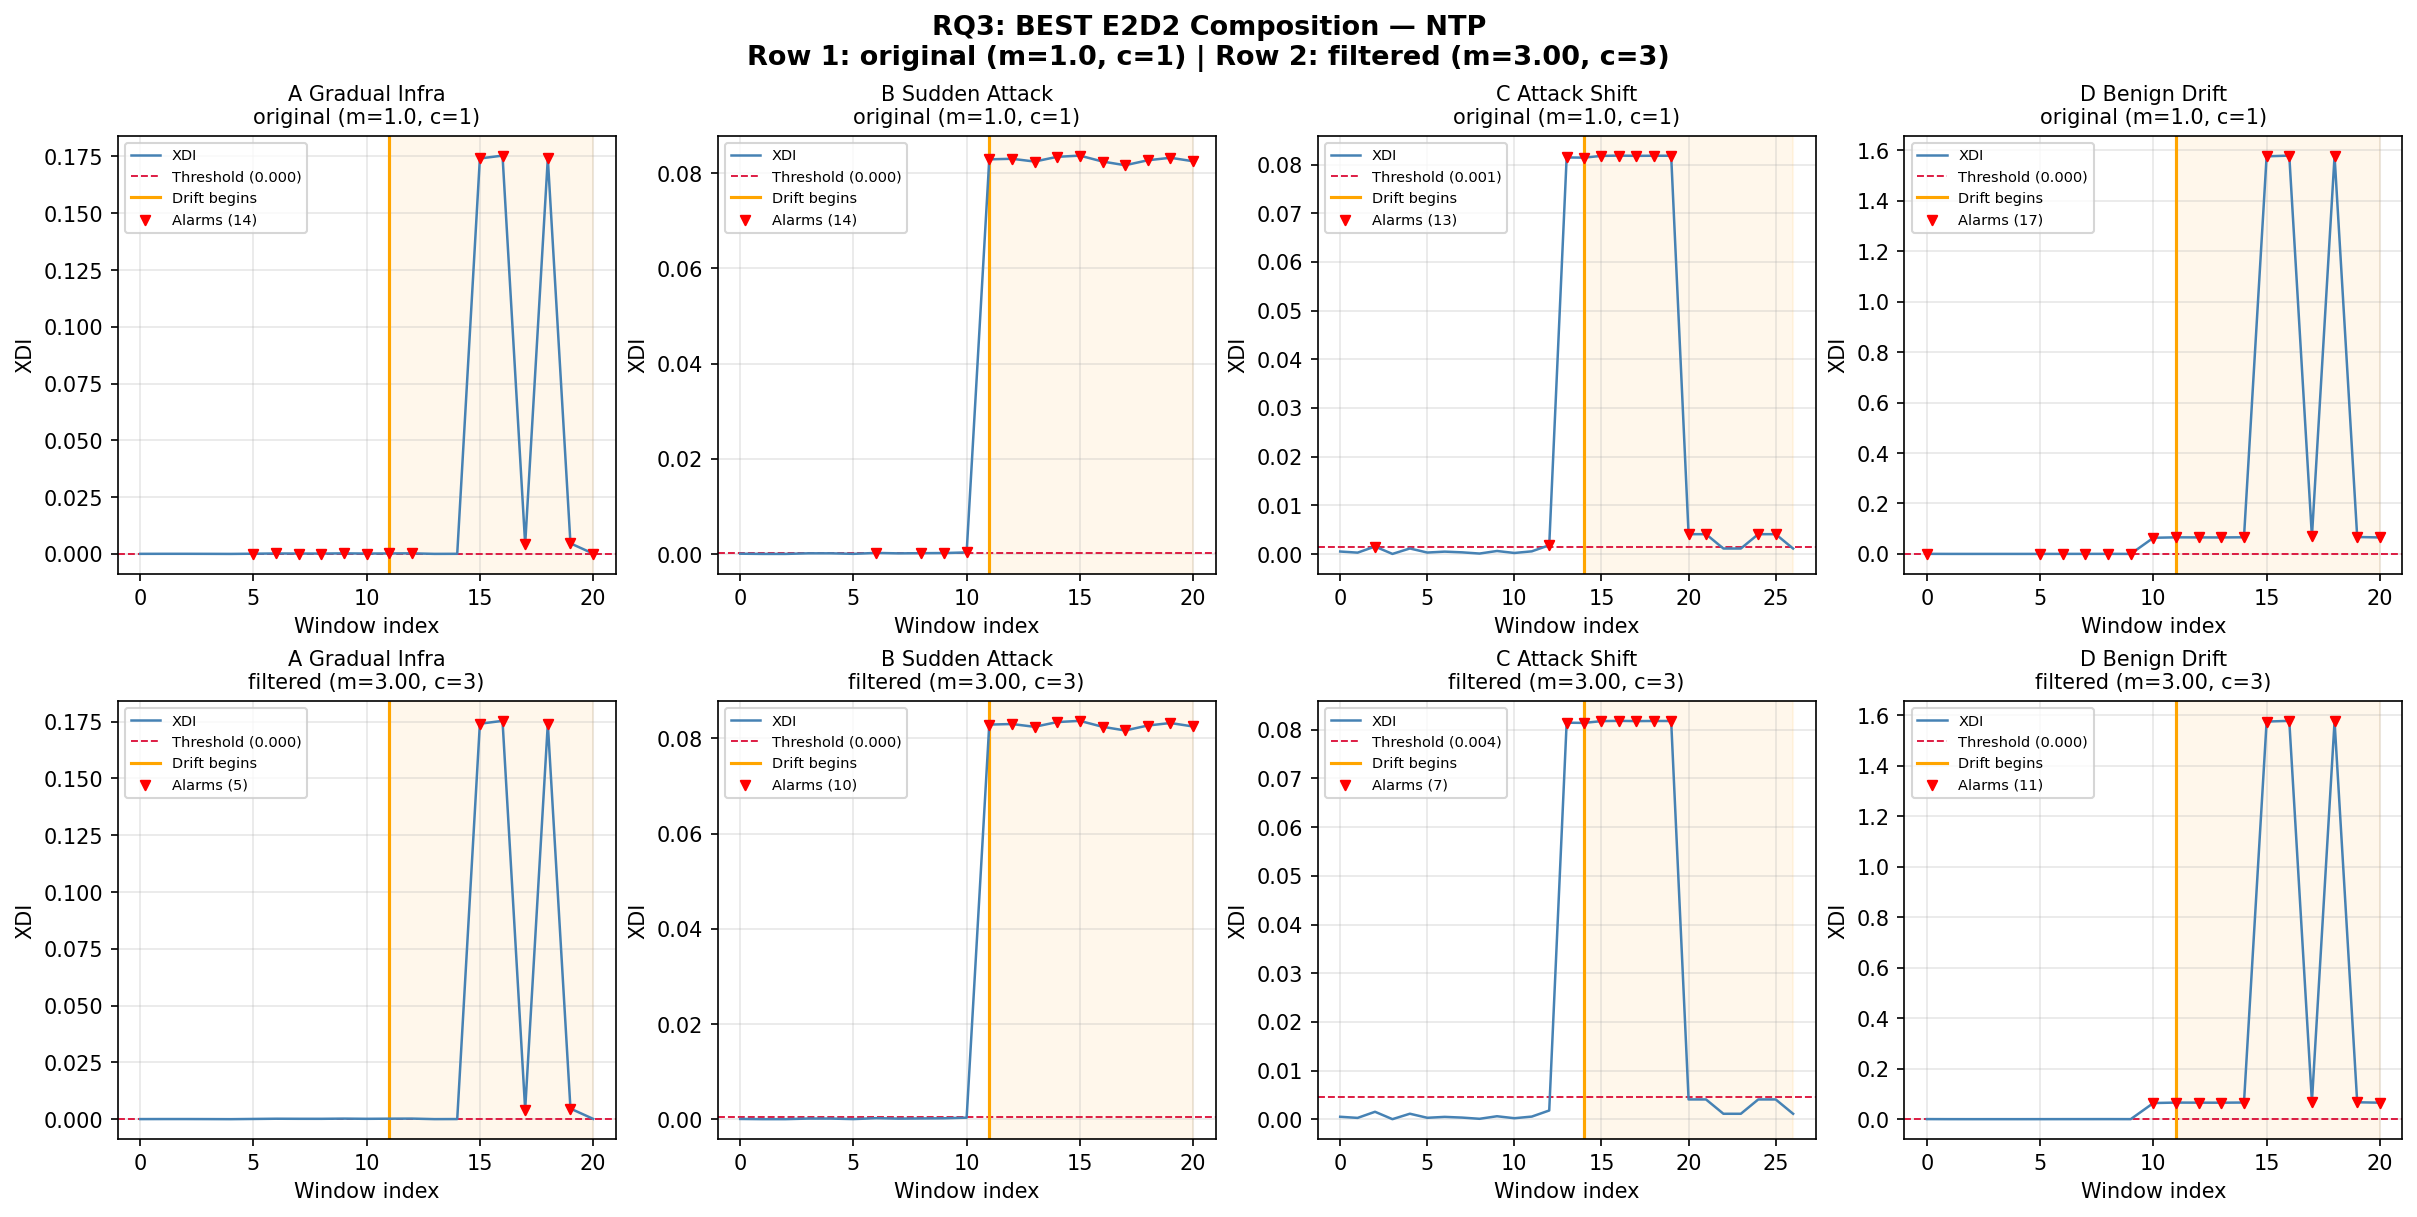

    NTP: saved rq3_xdi_bestcomp_ntp_orig_vs_filtered.png/pdf


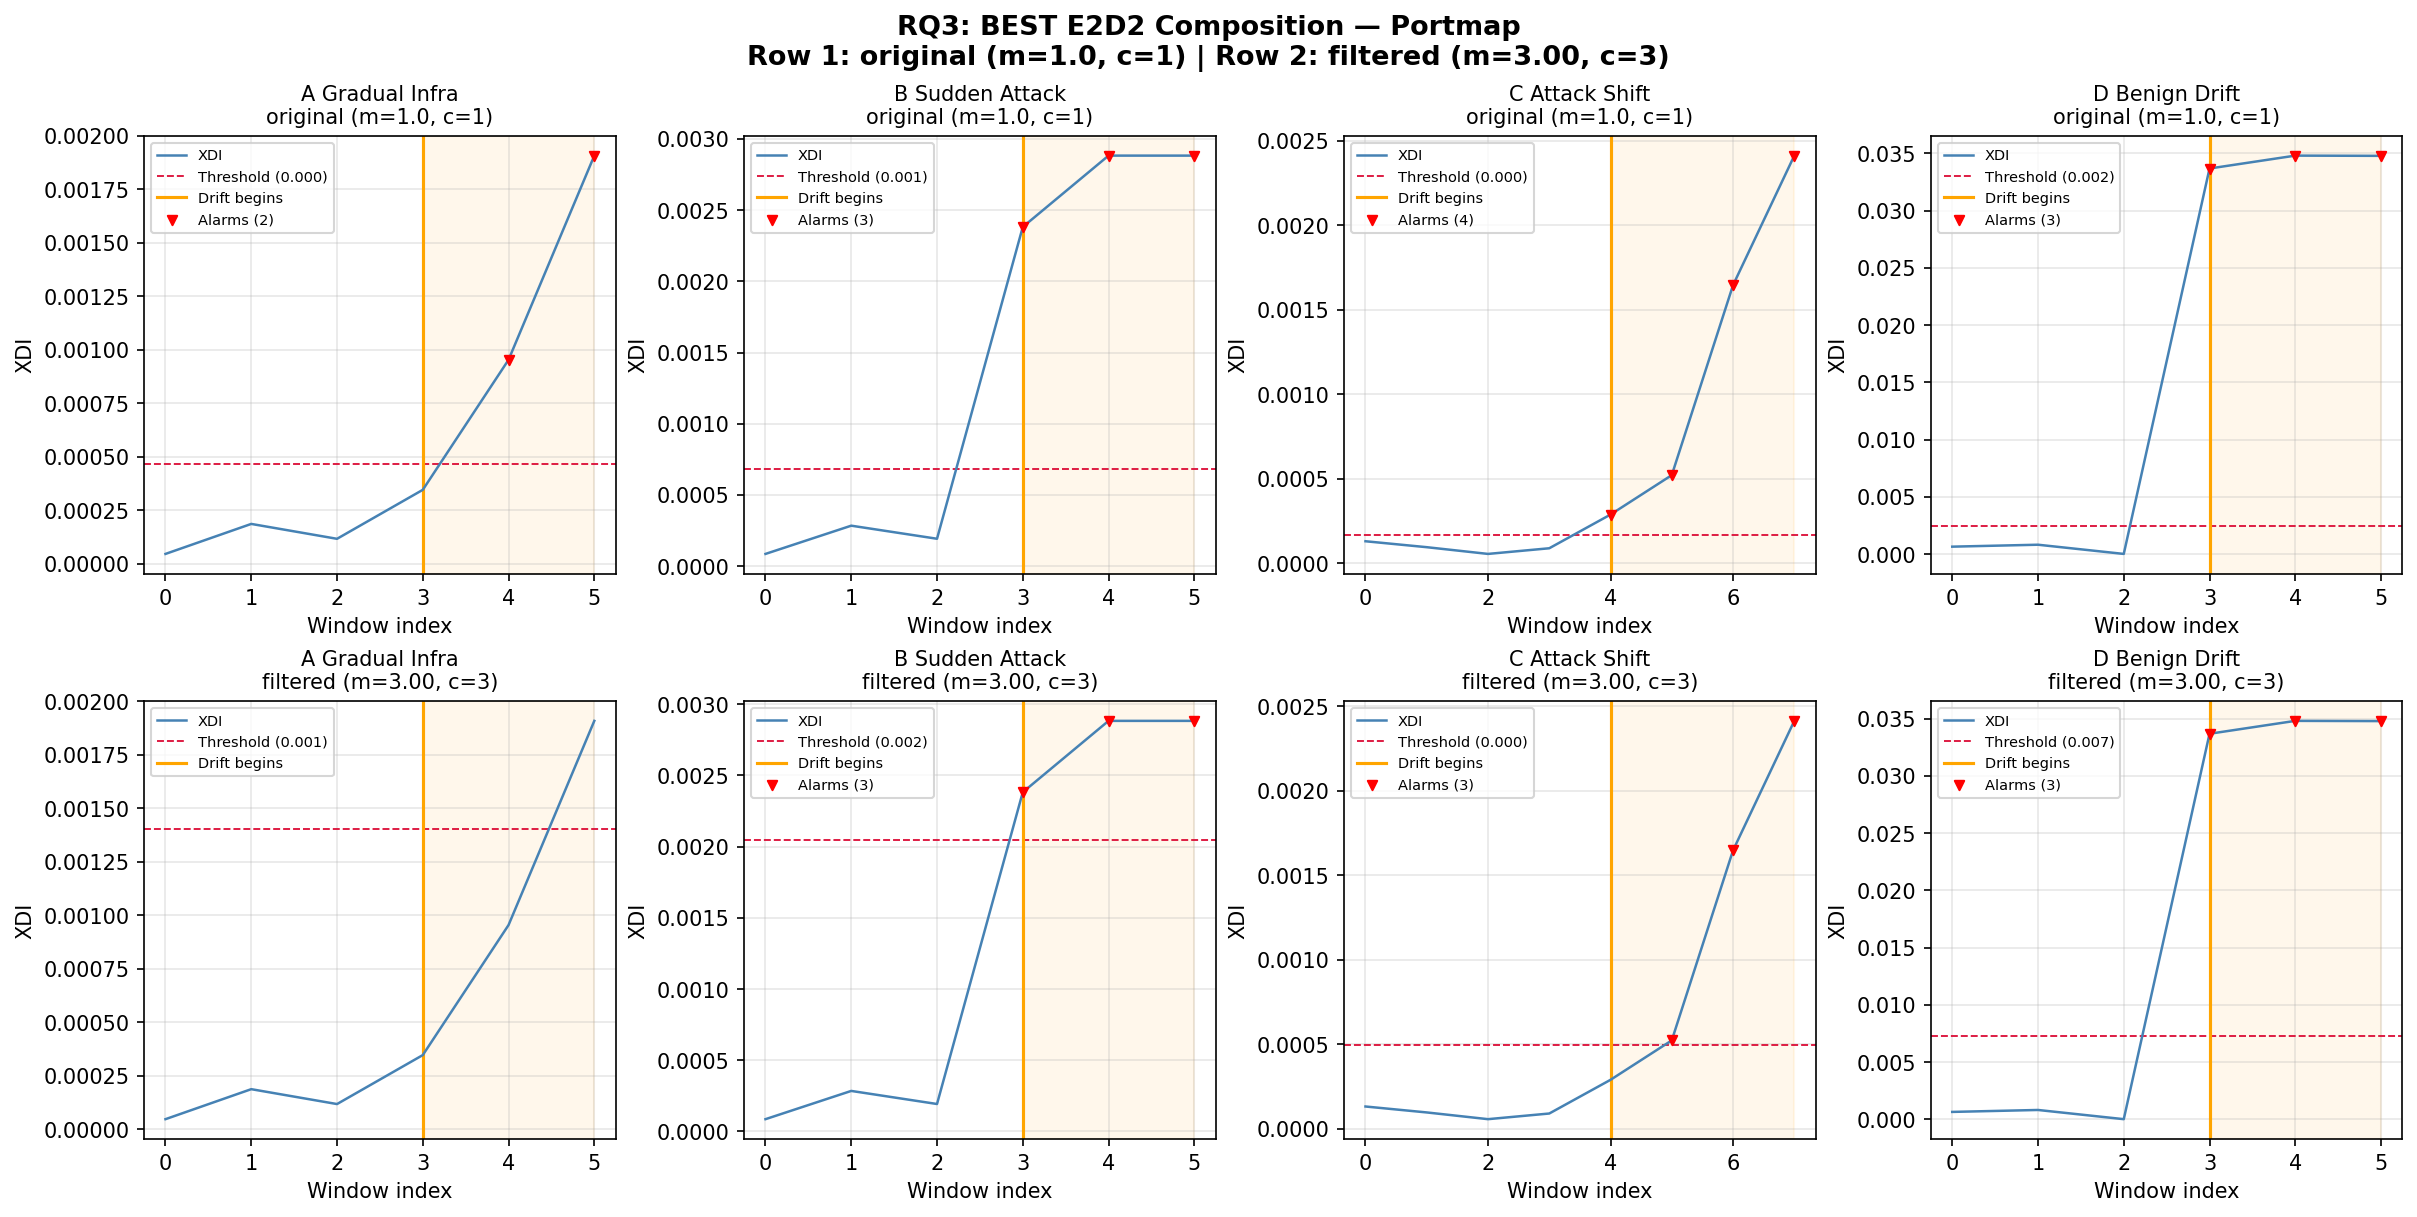

    Portmap: saved rq3_xdi_bestcomp_portmap_orig_vs_filtered.png/pdf


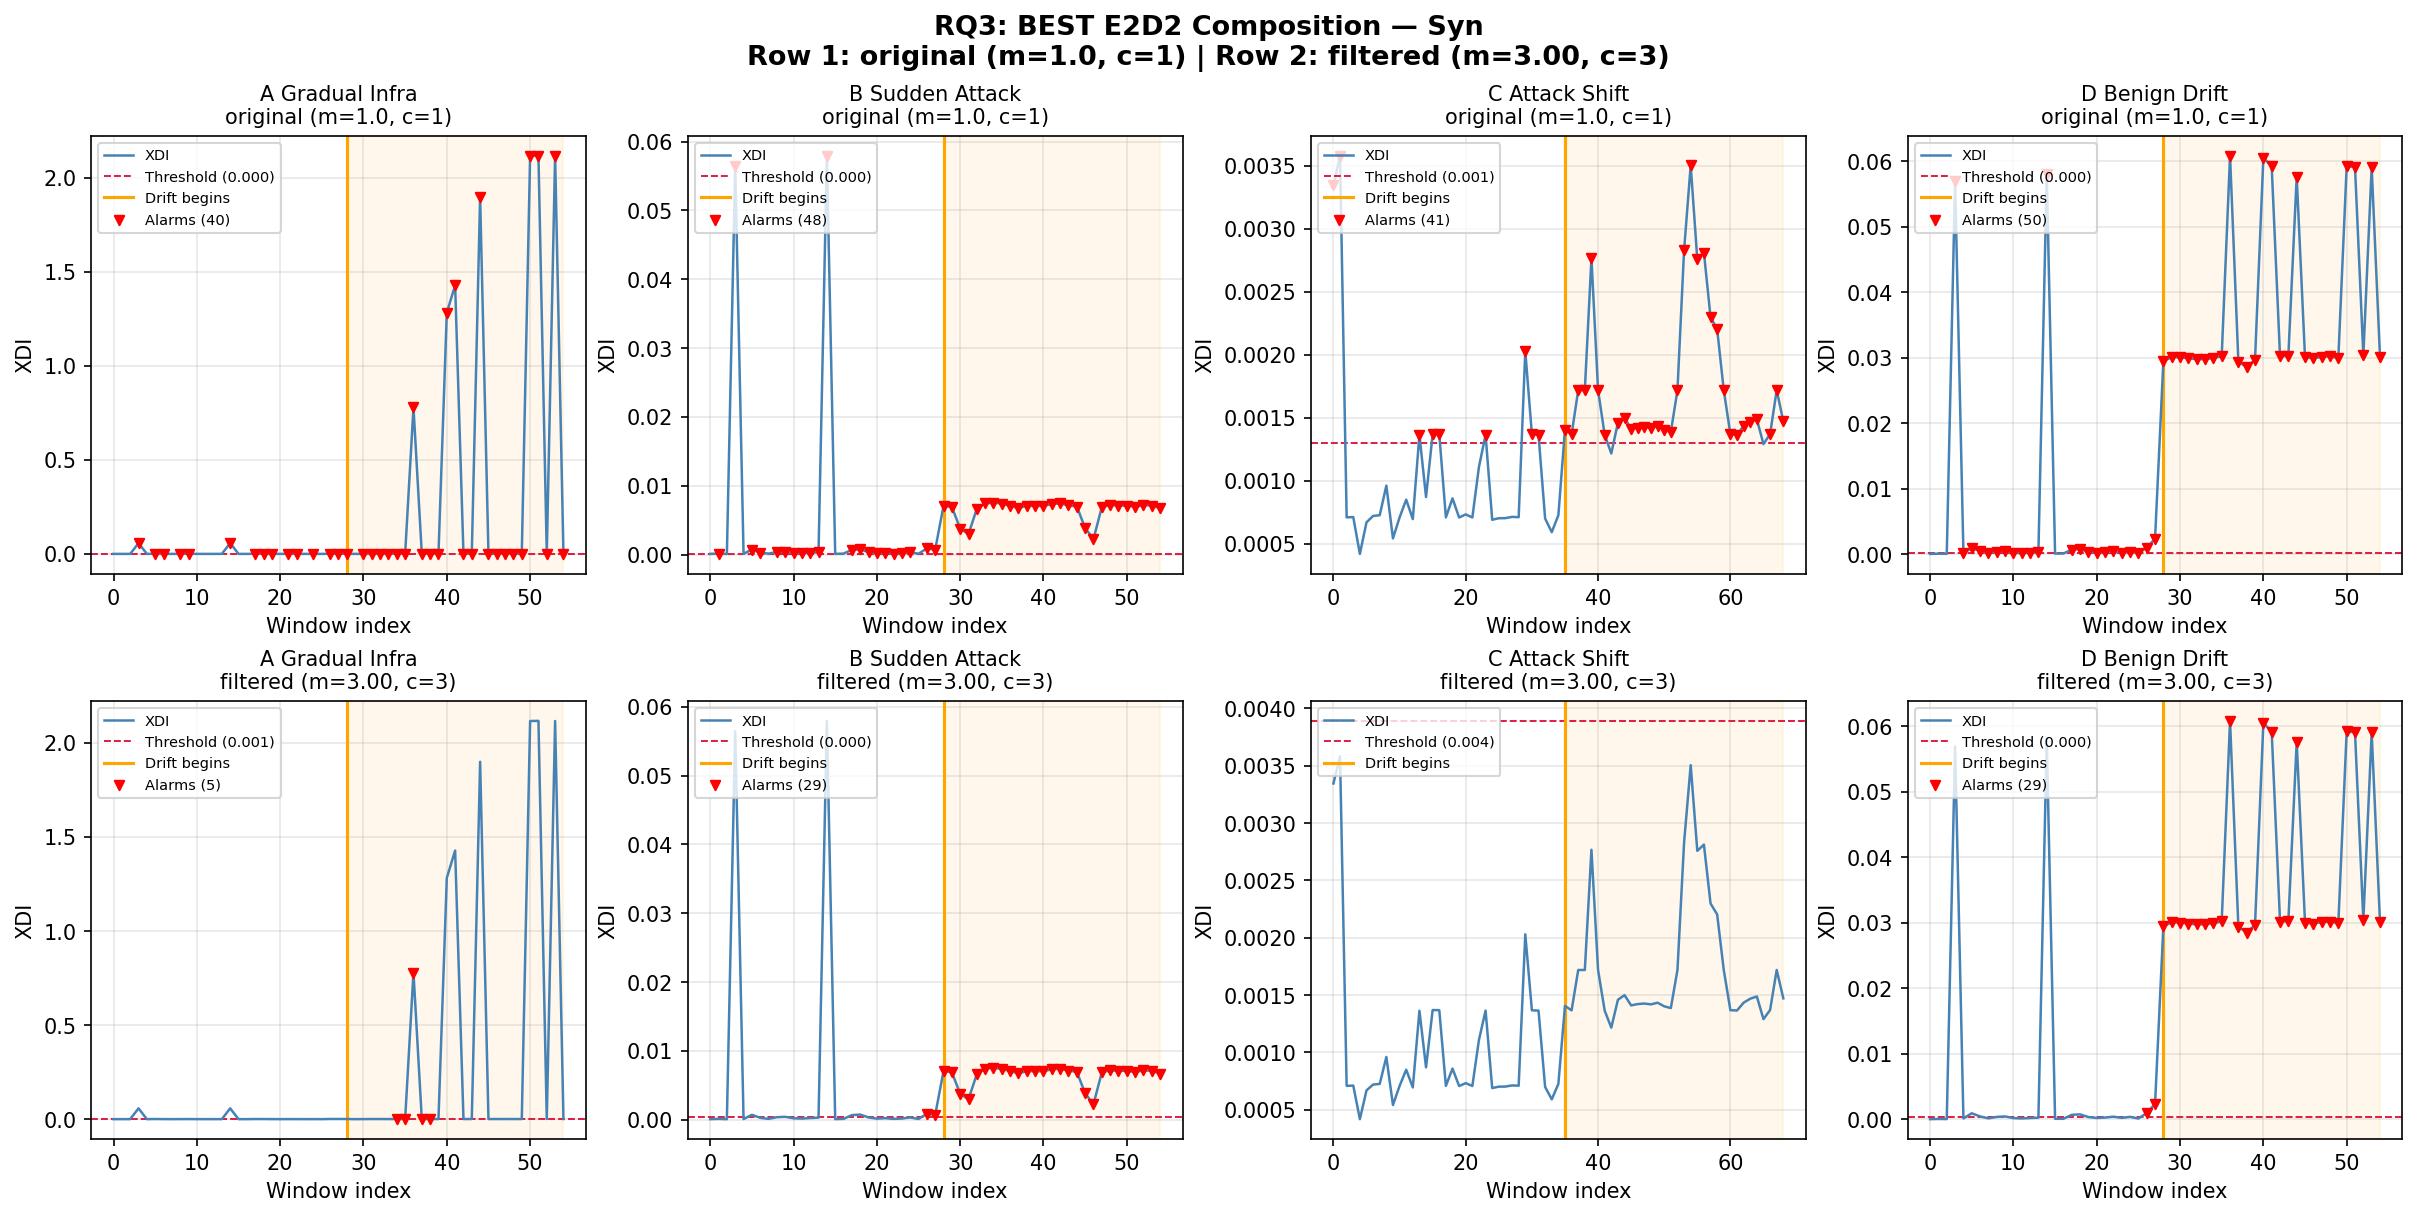

    Syn: saved rq3_xdi_bestcomp_syn_orig_vs_filtered.png/pdf
Cell 7.2 complete.


In [17]:
# =============================================================================
# CELL 7.2: Alarm Filtering — Threshold Scaling and Consecutive-Window Filter
# =============================================================================
# - Adds per-dataset figures for the BEST composition:
#     Row 1 = original alarming (m=1.0, c=1)
#     Row 2 = filtered alarming (m=best_mult, c=best_consec)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BEST_COMP = ("VAE", "integrated_gradients", "all", "max")
ORIG_KAPPA = 2.0
MULTIPLIERS = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
CONSEC_OPTIONS = [1, 2, 3]

print("=" * 70)
print("CELL 7.2: Alarm Filtering")
print("=" * 70)
print(f"  Multipliers: {MULTIPLIERS}")
print(f"  Consecutive: {CONSEC_OPTIONS}")


def consecutive_filter(alarms, n):
    if n <= 1:
        return alarms.copy()
    filtered = np.zeros_like(alarms)
    count = 0
    for i in range(len(alarms)):
        if alarms[i]:
            count += 1
            if count >= n:
                for j in range(max(0, i - n + 1), i + 1):
                    filtered[j] = 1
        else:
            count = 0
    return filtered


def compute_metrics(alarms, gt_mask):
    drift_mask = gt_mask.astype(bool)
    nodrift_mask = ~drift_mask
    n_drift = drift_mask.sum()
    n_nodrift = nodrift_mask.sum()
    if n_drift == 0 or n_nodrift == 0:
        return None

    tp = (alarms[drift_mask] == 1).sum()
    fp = (alarms[nodrift_mask] == 1).sum()
    fn = (alarms[drift_mask] == 0).sum()

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = (fp / n_nodrift * 100) if n_nodrift > 0 else 0.0

    alarm_in_drift = np.where(alarms[drift_mask] == 1)[0]
    delay = alarm_in_drift[0] if len(alarm_in_drift) > 0 else n_drift

    return {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "detection_delay": delay,
        "far_per_100win": far
    }


# ── Sweep ────────────────────────────────────────────────────────────────────

bb_best, exp_best, pop_best, agg_best = BEST_COMP
rows = []

for key, val in E2D2_RESULTS.items():
    ds, scen, bb, exp, pop, agg = key
    if (bb, exp, pop, agg) != BEST_COMP:
        continue

    xdi = np.array(val["xdi"])
    gt_mask = val["window_labels"]
    stored_threshold = val["threshold"]

    for mult in MULTIPLIERS:
        threshold = stored_threshold * mult
        alarms_raw = (xdi > threshold).astype(int)

        for consec in CONSEC_OPTIONS:
            alarms = consecutive_filter(alarms_raw, consec)
            m = compute_metrics(alarms, gt_mask)
            if m is None:
                continue
            m["dataset"] = ds
            m["scenario"] = scen
            m["multiplier"] = mult
            m["consec"] = consec
            rows.append(m)

df_sweep = pd.DataFrame(rows)
n_configs = len(MULTIPLIERS) * len(CONSEC_OPTIONS)
print(f"  Sweep: {n_configs} configs × {len(df_sweep)//n_configs} "
      f"dataset-scenarios = {len(df_sweep)} rows")

# ── Average by config ────────────────────────────────────────────────────────

metrics = ["precision", "recall", "f1", "detection_delay", "far_per_100win"]
avg = df_sweep.groupby(["multiplier", "consec"])[metrics].mean()

print(f"\n  All configurations (sorted by F1):")
print(f"  {'─' * 75}")
print(f"  {'mult':>5s} {'C':>2s} {'Prec':>7s} {'Rec':>7s} {'F1':>7s} "
      f"{'Delay':>7s} {'FAR':>7s}")
print(f"  {'─' * 75}")
for (mult, c), row in avg.sort_values("f1", ascending=False).iterrows():
    print(f"  {mult:5.2f} {c:2d} {row['precision']:7.3f} {row['recall']:7.3f} "
          f"{row['f1']:7.3f} {row['detection_delay']:7.1f} "
          f"{row['far_per_100win']:7.1f}")

# ── Best config vs original vs baselines ─────────────────────────────────────

best_idx = avg["f1"].idxmax()
best_mult, best_consec = best_idx
best_m = avg.loc[best_idx]
orig_m = avg.loc[(1.0, 1)]

# Baselines
bl_avgs = {}
for key, val in BASELINE_RESULTS.items():
    ds, scen, bb, bl_name = key
    if bb != bb_best:
        continue

    matching = None
    for ekey in E2D2_RESULTS:
        if ekey[0] == ds and ekey[1] == scen and ekey[2] == bb:
            matching = ekey
            break
    if matching is None:
        continue

    gt_mask = E2D2_RESULTS[matching]["window_labels"]
    n_windows = len(gt_mask)
    alarms = np.zeros(n_windows, dtype=int)
    for idx in val.get("alarm_indices", []):
        if 0 <= idx < n_windows:
            alarms[idx] = 1

    m = compute_metrics(alarms, gt_mask)
    if m:
        bl_avgs.setdefault(bl_name, []).append(m)

print(f"\n  {'─' * 75}")
print(f"  Best: mult={best_mult}, consec={best_consec}")
print(f"\n  {'Method':<28s} {'Prec':>7s} {'Rec':>7s} {'F1':>7s} "
      f"{'Delay':>7s} {'FAR':>7s}")
print(f"  {'─' * 63}")
print(f"  {'E2D2-original (m=1,c=1)':<28s} {orig_m['precision']:7.3f} "
      f"{orig_m['recall']:7.3f} {orig_m['f1']:7.3f} "
      f"{orig_m['detection_delay']:7.1f} {orig_m['far_per_100win']:7.1f}")
print(f"  {'E2D2-improved':<28s} {best_m['precision']:7.3f} "
      f"{best_m['recall']:7.3f} {best_m['f1']:7.3f} "
      f"{best_m['detection_delay']:7.1f} {best_m['far_per_100win']:7.1f}")
for bl_name in ["SHAP-Mahalanobis", "PCA-CD", "KL-Divergence", "ADWIN"]:
    if bl_name in bl_avgs:
        bl_df = pd.DataFrame(bl_avgs[bl_name])
        bl_mean = bl_df.mean()
        print(f"  {bl_name:<28s} {bl_mean['precision']:7.3f} "
              f"{bl_mean['recall']:7.3f} {bl_mean['f1']:7.3f} "
              f"{bl_mean['detection_delay']:7.1f} {bl_mean['far_per_100win']:7.1f}")

print(f"\n  Δ original → improved:")
for metric in metrics:
    o, n = orig_m[metric], best_m[metric]
    better = (n > o) if metric not in ["detection_delay", "far_per_100win"] else (n < o)
    arrow = "↑" if better else "↓"
    print(f"    {metric:<20s}: {o:.3f} → {n:.3f} ({arrow} {abs(n-o):.3f})")


# ── Plot helper: original vs filtered for BEST composition ───────────────────

def plot_variant_row(ax, ds_name, scen_name, mult, consec, row_label):
    key = (ds_name, scen_name, bb_best, exp_best, pop_best, agg_best)

    if key not in E2D2_RESULTS:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        return

    res = E2D2_RESULTS[key]
    xdi = np.array(res["xdi"])
    stored_threshold = float(res["threshold"])
    threshold = stored_threshold * mult
    alarms_raw = (xdi > threshold).astype(int)
    alarms = consecutive_filter(alarms_raw, consec)
    alarm_indices = np.where(alarms == 1)[0]

    meta = res["scenario_metadata"]
    window_centers = res["window_centers"]
    drift_onset = meta.get("drift_onset_idx", None)

    T = len(xdi)
    t_axis = np.arange(T)

    ax.plot(t_axis, xdi, color="steelblue", linewidth=1.2, label="XDI", zorder=3)
    ax.axhline(y=threshold, color="crimson", linestyle="--", linewidth=0.9,
               label=f"Threshold ({threshold:.3f})", zorder=2)

    if drift_onset is not None:
        onset_win = np.searchsorted(window_centers, drift_onset)
        ax.axvline(x=onset_win, color="orange", linestyle="-", linewidth=1.5,
                   label="Drift begins", zorder=2)
        ax.axvspan(onset_win, T - 1, alpha=0.08, color="orange")

    if len(alarm_indices) > 0:
        ax.scatter(alarm_indices, xdi[alarm_indices], color="red", s=20, zorder=5,
                   label=f"Alarms ({len(alarm_indices)})", marker="v")

    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Window index")
    ax.set_ylabel("XDI")

    scen_short = scen_name.replace("_", " ").title()
    ax.set_title(f"{scen_short}\n{row_label}", fontsize=10)
    ax.legend(fontsize=7, loc="upper left")


# ── Generate per-dataset figures: original vs filtered ───────────────────────

all_datasets = sorted(df_sweep["dataset"].unique())
scenarios_list = list(SCENARIO_REGISTRY.keys())

print(f"\n  Generating BEST-comp original vs filtered XDI figures for {len(all_datasets)} datasets...")

for ds_name in all_datasets:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
    fig.suptitle(
        f"RQ3: BEST E2D2 Composition — {ds_name}\n"
        f"Row 1: original (m=1.0, c=1) | Row 2: filtered (m={best_mult:.2f}, c={best_consec})",
        fontsize=13, fontweight="bold"
    )

    for col, scen_name in enumerate(scenarios_list):
        # Row 1: original thresholding
        plot_variant_row(
            axes[0, col], ds_name, scen_name,
            mult=1.0, consec=1,
            row_label="original (m=1.0, c=1)"
        )

        # Row 2: filtered thresholding
        plot_variant_row(
            axes[1, col], ds_name, scen_name,
            mult=best_mult, consec=best_consec,
            row_label=f"filtered (m={best_mult:.2f}, c={best_consec})"
        )

    fig_name = f"rq3_xdi_bestcomp_{ds_name.lower().replace(' ', '_')}_orig_vs_filtered"
    fig.savefig(FIGURE_DIR / f"{fig_name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{fig_name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"    {ds_name}: saved {fig_name}.png/pdf")

print("=" * 70)
print("Cell 7.2 complete.")